# Election Analysis and Prediction

This notebook studies Canadian federal election patterns using vote-share time series, party-level trend structure, and province-level participation indicators. 
The analysis first standardizes historical inputs, then produces descriptive outputs that support interpretation of party momentum and electoral participation across time and geography.

Prediction in this notebook is scenario-oriented rather than a single deterministic forecast. 
The workflow emphasizes transparent data checks, comparable visual diagnostics, and interpretable summary tables so that any projection assumptions can be inspected and revised explicitly.

Core aims:
- Build a reproducible cleaned election dataset for longitudinal comparison.
- Quantify and visualize party vote-share evolution and recent-cycle structure.
- Support cautious prediction by linking trend evidence to clear assumptions.

Execution note: run sections in order, because some helper function names are reused across modules.


In [9]:
import subprocess
import sys

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-U",
    "pandas",
    "numpy",
    "matplotlib",
    "openpyxl",
])


0

## Election Workflow

**Research Objective**
This section constructs a longitudinal profile of Canadian federal party vote shares from 2000 to 2025 and compares provincial participation through votes versus registered electors.

**Methodological Approach**
The procedure standardizes party labels, validates annual vote-share totals, generates trend and heatmap visualizations, and creates a province-level multi-panel comparison.

**Interpretation Scope**
The outputs support both temporal interpretation of national party dynamics and cross-province participation structure in the same analytical frame.

**Source Links**
- https://www.sfu.ca/~aheard/elections/1867-present.html
- https://researchbriefings.files.parliament.uk/documents/CBP-10244/CBP-10244.pdf

**Expected Outputs**
- `outputs/fig1_trend.png`
- `outputs/fig2_bar_2025.png`
- `outputs/fig3_heatmap_2021.png`
- `outputs/fig3_heatmap_2025.png`
- `outputs/fig4_votes_vs_electors_by_province.png`
- `outputs/national_vote_share_clean.csv`
- `outputs/national_vote_share_sumcheck.csv`


In [10]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_URL_2000_2021 = "https://www.sfu.ca/~aheard/elections/1867-present.html"
DATASET_URL_2025 = "https://researchbriefings.files.parliament.uk/documents/CBP-10244/CBP-10244.pdf"

def find_project_root(marker):
    here = Path.cwd().resolve()
    for candidate in [here] + list(here.parents):
        if (candidate / marker).exists():
            return candidate
    return here

PROJECT_ROOT = find_project_root("canada_federal_vote_share_2000_2025.csv")

INPUT_CSV = PROJECT_ROOT / "canada_federal_vote_share_2000_2025.csv"
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PROV_INPUT_CSV = PROJECT_ROOT / "canada_province_votes_electors_2000_2025.csv"
KAGGLE_DIR = PROJECT_ROOT / "kaggle_canada_election"


def canon_party(p):
    s = str(p).strip().lower()
    s = re.sub(r"\s+", " ", s)
    if "liberal" in s:
        return "Liberal"
    if "conservative" in s or "canadian alliance" in s or "progressive conservative" in s:
        return "Conservative"
    if "new democratic" in s or "(ndp)" in s or s == "ndp":
        return "NDP"
    if "bloc" in s:
        return "Bloc Québécois"
    if "green" in s:
        return "Green"
    if "people" in s:
        return "People's"
    if "other" in s:
        return "Others"
    return "Others"

def detect_col(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for k in candidates:
        if k in cols:
            return cols[k]
    for c in df.columns:
        cl = str(c).lower()
        for k in candidates:
            if k in cl:
                return c
    return None

def build_year_map_from_election_info(path):
    info = pd.read_csv(path, low_memory=False)
    c_eid = detect_col(info, ["election_id"])
    c_evt = detect_col(info, ["event_number"])
    c_date = detect_col(info, ["election_date", "date", "event_date"])
    if c_eid is None:
        raise RuntimeError(f"Election info missing election_id. Columns: {info.columns.tolist()}")
    if c_date is not None:
        dt = pd.to_datetime(info[c_date], errors="coerce")
        info = info.assign(_year=dt.dt.year)
        m = info[[c_eid, "_year"]].dropna().drop_duplicates()
        year_map = dict(zip(m[c_eid].astype(str), m["_year"].astype(int)))
        if year_map:
            return year_map
    if c_evt is not None:
        ev = pd.to_numeric(info[c_evt], errors="coerce")
        info = info.assign(_ev=ev)
        evs = sorted([int(x) for x in info["_ev"].dropna().unique().tolist()])
        known = [2000, 2004, 2006, 2008, 2011, 2015, 2019, 2021]
        year_map = {}
        if len(evs) == len(known):
            emap = dict(zip(evs, known))
            for _, r in info[[c_eid, "_ev"]].dropna().drop_duplicates().iterrows():
                year_map[str(r[c_eid])] = emap.get(int(r["_ev"]), np.nan)
            year_map = {k: int(v) for k, v in year_map.items() if pd.notna(v)}
            if year_map:
                return year_map
    raise RuntimeError(f"Cannot build year map from election info. Columns: {info.columns.tolist()}")

def build_prov_votes_electors_from_kaggle(kdir):
    ei = os.path.join(kdir, "Election Information.CSV")
    results = os.path.join(kdir, "Results.csv")
    poll = os.path.join(kdir, "Poll Details.csv")
    rid = os.path.join(kdir, "Ridings.csv")
    for fp in [ei, results, poll, rid]:
        if not os.path.exists(fp):
            raise RuntimeError(f"Missing required Kaggle file: {fp}")

    year_map = build_year_map_from_election_info(ei)

    ridings = pd.read_csv(rid, low_memory=False)
    rd_ed = detect_col(ridings, ["electoral_district_number", "circonscription"])
    rd_prov = detect_col(ridings, ["canadian_province", "province"])
    if rd_ed is None or rd_prov is None:
        raise RuntimeError(f"Ridings missing ed/province columns. Columns: {ridings.columns.tolist()}")
    rid_map = ridings[[rd_ed, rd_prov]].dropna().drop_duplicates().copy()
    rid_map.columns = ["ed_num", "province"]
    rid_map["ed_num"] = rid_map["ed_num"].astype(str).str.strip()

    poll_df = pd.read_csv(poll, low_memory=False, usecols=lambda c: True)
    p_eid = detect_col(poll_df, ["election_id"])
    p_ed = detect_col(poll_df, ["electoral_district_number", "circonscription"])
    p_elec = detect_col(poll_df, ["electors", "électeurs"])
    if p_eid is None or p_ed is None or p_elec is None:
        raise RuntimeError(f"Poll Details missing required columns. Columns: {poll_df.columns.tolist()}")
    poll_df = poll_df[[p_eid, p_ed, p_elec]].copy()
    poll_df.columns = ["election_id", "ed_num", "electors"]
    poll_df["election_id"] = poll_df["election_id"].astype(str).str.strip()
    poll_df["ed_num"] = poll_df["ed_num"].astype(str).str.strip()
    poll_df["electors"] = pd.to_numeric(poll_df["electors"], errors="coerce")
    poll_df = poll_df.dropna(subset=["electors"])
    electors_by_ed = poll_df.groupby(["election_id", "ed_num"], as_index=False)["electors"].sum()

    res_df = pd.read_csv(results, low_memory=False, usecols=lambda c: True)
    r_eid = detect_col(res_df, ["election_id"])
    r_ed = detect_col(res_df, ["electoral_district_number", "circonscription"])
    r_votes = detect_col(res_df, ["candidate_poll_votes_count", "votes"])
    if r_eid is None or r_ed is None or r_votes is None:
        raise RuntimeError(f"Results missing required columns. Columns: {res_df.columns.tolist()}")
    res_df = res_df[[r_eid, r_ed, r_votes]].copy()
    res_df.columns = ["election_id", "ed_num", "votes"]
    res_df["election_id"] = res_df["election_id"].astype(str).str.strip()
    res_df["ed_num"] = res_df["ed_num"].astype(str).str.strip()
    res_df["votes"] = pd.to_numeric(res_df["votes"], errors="coerce")
    res_df = res_df.dropna(subset=["votes"])
    votes_by_ed = res_df.groupby(["election_id", "ed_num"], as_index=False)["votes"].sum()

    m = votes_by_ed.merge(electors_by_ed, on=["election_id", "ed_num"], how="inner")
    m = m.merge(rid_map, on="ed_num", how="left")
    m["year"] = m["election_id"].map(year_map)
    m = m.dropna(subset=["province", "year"]).copy()
    m["year"] = m["year"].astype(int)

    out = m.groupby(["year", "province"], as_index=False)[["votes", "electors"]].sum()
    out = out.sort_values(["province", "year"])
    return out

def heatmap_single_year(df_clean, year, order):
    wide = df_clean.pivot(index="Year", columns="Party", values="VoteShare").fillna(0)
    wide = wide.reindex(columns=[c for c in order if c in wide.columns])
    if year not in wide.index:
        raise RuntimeError(f"Year {year} not found for heatmap.")
    row = wide.loc[[year]].copy()
    plt.figure(figsize=(12, 3))
    im = plt.imshow(row.values, aspect="auto")
    plt.yticks([0], [str(year)])
    plt.xticks(range(len(row.columns)), row.columns, rotation=45, ha="right")
    plt.xlabel("Party")
    plt.ylabel("Year")
    plt.title(f"{year} vote share heatmap (single-year)")
    plt.colorbar(im, label="Vote share (%)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"fig3_heatmap_{year}.png"), dpi=160)
    plt.close()

def main():
    df = pd.read_csv(INPUT_CSV)

    c_year = detect_col(df, ["year"])
    c_party = detect_col(df, ["party"])
    c_share = detect_col(df, ["voteshare", "vote_share", "share", "pct", "percent", "percentage"])
    c_source = detect_col(df, ["source", "url"])

    if c_year is None or c_party is None or c_share is None:
        raise RuntimeError(f"Missing required columns. Found: {df.columns.tolist()}")

    df = df[[c_year, c_party, c_share] + ([c_source] if c_source else [])].copy()
    df.columns = ["Year", "Party", "VoteShare"] + (["Source"] if c_source else [])

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
    df["VoteShare"] = pd.to_numeric(df["VoteShare"], errors="coerce")
    df = df.dropna(subset=["Year", "Party", "VoteShare"]).copy()
    df["Year"] = df["Year"].astype(int)

    df["Party_Canon"] = df["Party"].map(canon_party)
    df_clean = df.groupby(["Year", "Party_Canon"], as_index=False)["VoteShare"].sum()
    df_clean = df_clean.rename(columns={"Party_Canon": "Party"})
    df_clean.to_csv(os.path.join(OUT_DIR, "national_vote_share_clean.csv"), index=False)

    check = df_clean.groupby("Year")["VoteShare"].sum().reset_index()
    check["diff_from_100"] = check["VoteShare"] - 100.0
    check.to_csv(os.path.join(OUT_DIR, "national_vote_share_sumcheck.csv"), index=False)

    order = ["Liberal", "Conservative", "NDP", "Bloc Québécois", "Green", "People's", "Others"]
    wide = df_clean.pivot(index="Year", columns="Party", values="VoteShare").fillna(0)
    wide = wide.reindex(columns=[c for c in order if c in wide.columns])

    ax = wide.plot(figsize=(11, 5))
    ax.set_xlabel("Year")
    ax.set_ylabel("Vote share (%)")
    ax.set_title("Canada federal election: national vote share (2000–2025)")
    ax.grid(True)

    election_years = sorted(wide.index.unique().tolist())
    ymin, ymax = ax.get_ylim()
    for y in election_years:
        ax.vlines(x=y, ymin=ymin, ymax=ymax, linestyles="--", linewidth=1.0)
        ax.text(
            y, -0.10, f"{y} election",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=7,
            rotation=90,
            clip_on=False
        )
    ax.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.30)
    plt.savefig(os.path.join(OUT_DIR, "fig1_trend.png"), dpi=160)
    plt.close()

    snap = df_clean[df_clean["Year"] == 2025].sort_values("VoteShare", ascending=False).copy()
    plt.figure(figsize=(10, 5))
    plt.bar(snap["Party"], snap["VoteShare"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Party")
    plt.ylabel("Vote share (%)")
    plt.title("2025 national vote share by party")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "fig2_bar_2025.png"), dpi=160)
    plt.close()

    heatmap_single_year(df_clean, 2021, order)
    heatmap_single_year(df_clean, 2025, order)

    prov_df = None
    if os.path.exists(PROV_INPUT_CSV):
        prov_df = pd.read_csv(PROV_INPUT_CSV, low_memory=False)
        py = detect_col(prov_df, ["year"])
        pp = detect_col(prov_df, ["province", "prov"])
        pv = detect_col(prov_df, ["votes", "voters", "ballots", "votes_cast"])
        pe = detect_col(prov_df, ["electors", "eligible", "registered", "population"])
        if py is None or pp is None or pv is None or pe is None:
            raise RuntimeError(f"Province CSV missing columns. Found: {prov_df.columns.tolist()}")
        prov_df = prov_df[[py, pp, pv, pe]].copy()
        prov_df.columns = ["year", "province", "votes", "electors"]
        prov_df["year"] = pd.to_numeric(prov_df["year"], errors="coerce").astype("Int64")
        prov_df["votes"] = pd.to_numeric(prov_df["votes"], errors="coerce")
        prov_df["electors"] = pd.to_numeric(prov_df["electors"], errors="coerce")
        prov_df = prov_df.dropna(subset=["year", "province", "votes", "electors"]).copy()
        prov_df["year"] = prov_df["year"].astype(int)
    else:
        if os.path.isdir(KAGGLE_DIR):
            prov_df = build_prov_votes_electors_from_kaggle(KAGGLE_DIR)
            prov_df.to_csv(os.path.join(OUT_DIR, "province_votes_electors_from_kaggle.csv"), index=False)
        else:
            raise RuntimeError(
                f"Need {PROV_INPUT_CSV} or Kaggle folder {KAGGLE_DIR}/ with Results.csv, Poll Details.csv, Ridings.csv, Election Information.CSV"
            )

    prov_df = prov_df.sort_values(["province", "year"]).copy()
    provinces = sorted(prov_df["province"].dropna().unique().tolist())
    n = len(provinces)
    cols = 4
    rows = int(np.ceil(n / cols))

    fig = plt.figure(figsize=(14, 3.2 * rows))
    for i, prov in enumerate(provinces):
        ax = fig.add_subplot(rows, cols, i + 1)
        d = prov_df[prov_df["province"] == prov].sort_values("year").copy()
        x = d["year"].values
        y_votes = (d["votes"].values / 1_000_000.0)
        y_elec = (d["electors"].values / 1_000_000.0)
        ax.plot(x, y_votes, label="Votes (M)")
        ax.plot(x, y_elec, label="Electors (M)")
        ax.set_title(str(prov))
        ax.set_xlabel("Year")
        ax.set_ylabel("Millions")
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "fig4_votes_vs_electors_by_province.png"), dpi=160)
    plt.close()

    print("Saved:")
    print(os.path.join(OUT_DIR, "fig1_trend.png"))
    print(os.path.join(OUT_DIR, "fig2_bar_2025.png"))
    print(os.path.join(OUT_DIR, "fig3_heatmap_2021.png"))
    print(os.path.join(OUT_DIR, "fig3_heatmap_2025.png"))
    print(os.path.join(OUT_DIR, "fig4_votes_vs_electors_by_province.png"))
    print(os.path.join(OUT_DIR, "national_vote_share_clean.csv"))
    print(os.path.join(OUT_DIR, "national_vote_share_sumcheck.csv"))
    if os.path.exists(os.path.join(OUT_DIR, "province_votes_electors_from_kaggle.csv")):
        print(os.path.join(OUT_DIR, "province_votes_electors_from_kaggle.csv"))
    print("Dataset URLs:")
    print(DATASET_URL_2000_2021)
    print(DATASET_URL_2025)

if __name__ == "__main__":
    main()



Saved:
/home/sss/codespace/tom1/fypp/outputs/fig1_trend.png
/home/sss/codespace/tom1/fypp/outputs/fig2_bar_2025.png
/home/sss/codespace/tom1/fypp/outputs/fig3_heatmap_2021.png
/home/sss/codespace/tom1/fypp/outputs/fig3_heatmap_2025.png
/home/sss/codespace/tom1/fypp/outputs/fig4_votes_vs_electors_by_province.png
/home/sss/codespace/tom1/fypp/outputs/national_vote_share_clean.csv
/home/sss/codespace/tom1/fypp/outputs/national_vote_share_sumcheck.csv
/home/sss/codespace/tom1/fypp/outputs/province_votes_electors_from_kaggle.csv
Dataset URLs:
https://www.sfu.ca/~aheard/elections/1867-present.html
https://researchbriefings.files.parliament.uk/documents/CBP-10244/CBP-10244.pdf


## 2025 Prediction vs Actual

This section uses a **Bayesian hierarchical random-walk time-series model** (Gibbs sampling) trained on elections before 2025 to predict the 2025 national party vote shares.

Data sources used in this cell:
- Historical elections (downloaded in-cell): `https://www.sfu.ca/~aheard/elections/1867-present.html`
- 2025 holdout actual result (local file): `canada_federal_vote_share_2000_2025.csv`

New outputs:
- `outputs/sfu_historical_vote_share_1867_2021.csv`
- `outputs/prediction_2025_vs_actual.csv`
- `outputs/fig5_predicted_vs_actual_2025.png`


Saved:
/home/sss/codespace/tom1/fypp/outputs/sfu_historical_vote_share_1867_2021.csv
/home/sss/codespace/tom1/fypp/outputs/prediction_2025_vs_actual.csv
/home/sss/codespace/tom1/fypp/outputs/fig5_predicted_vs_actual_2025.png
Model: Bayesian hierarchical random walk (Gibbs sampler)
Posterior draws: 2000
2025 MAE: 5.94 percentage points
2025 RMSE: 7.41 percentage points
Source URL used:
https://www.sfu.ca/~aheard/elections/1867-present.html


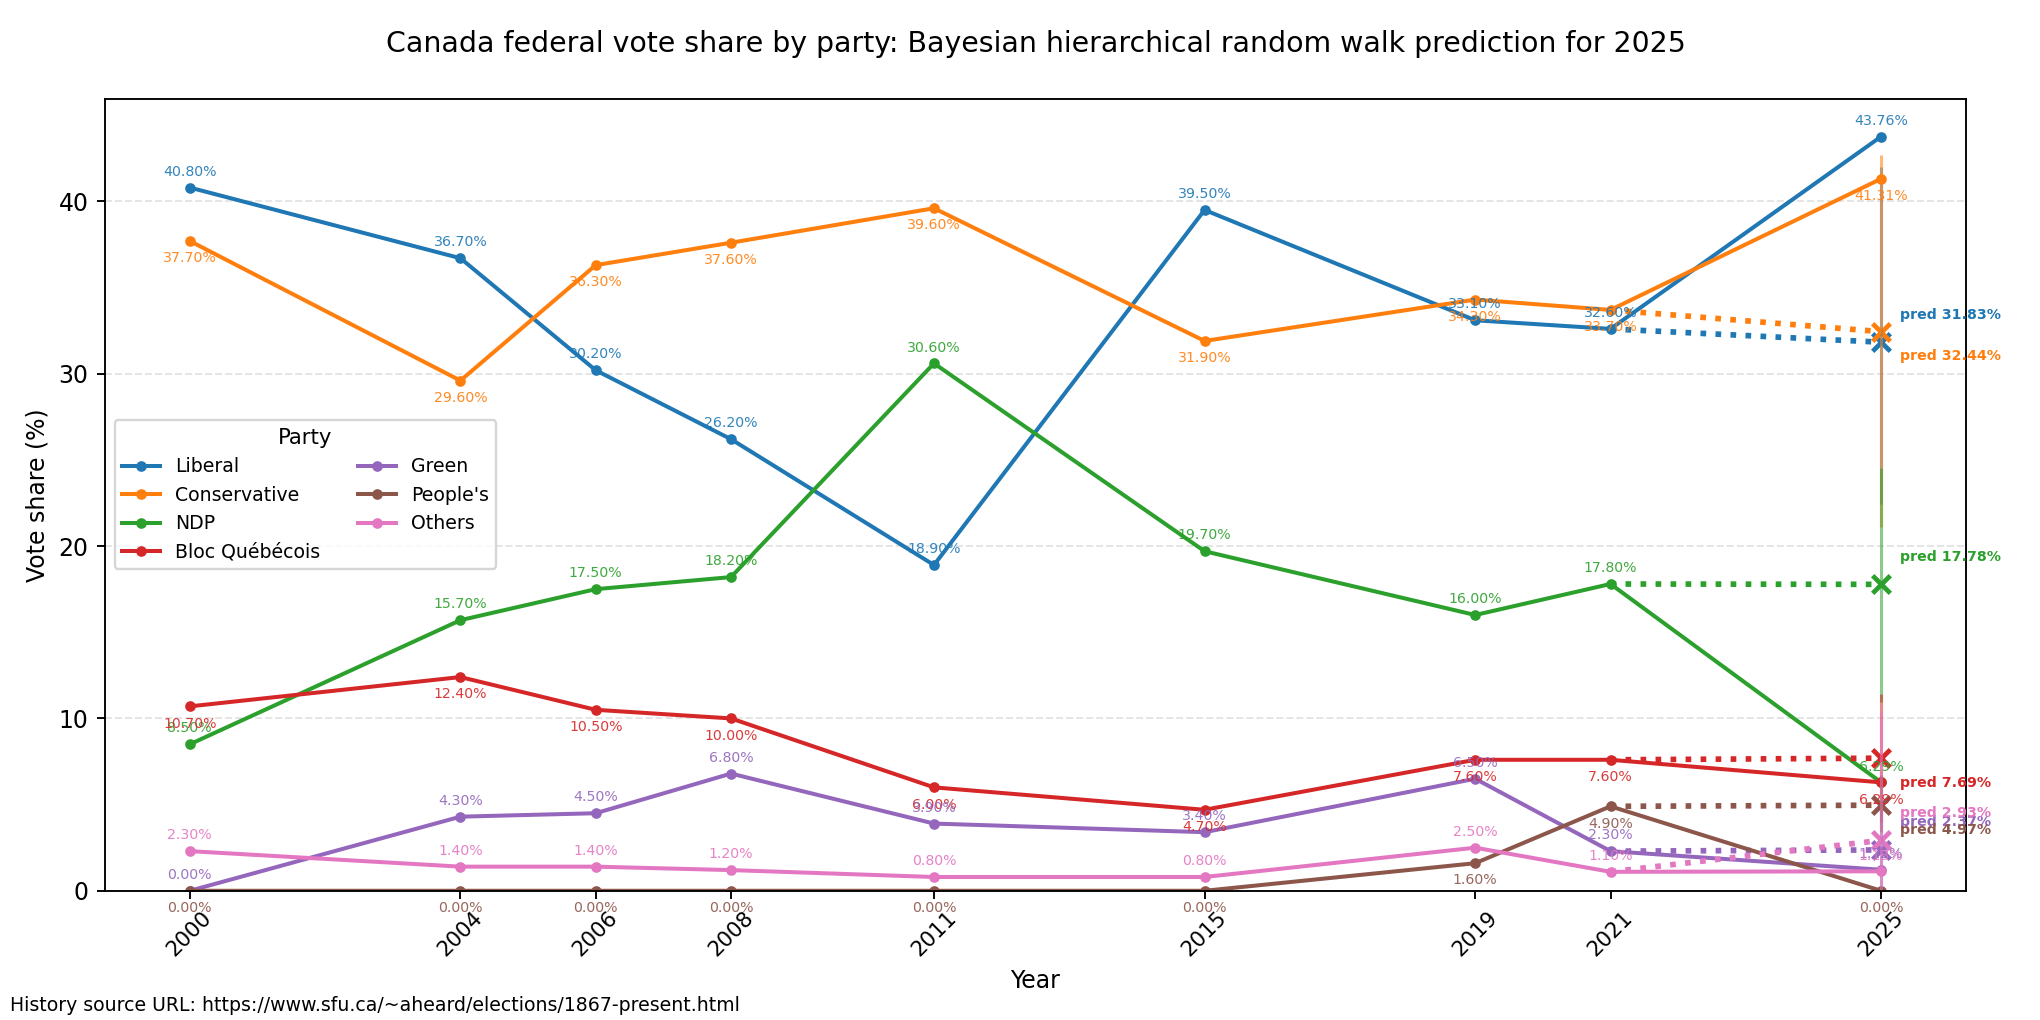

In [11]:
import importlib
import re
import subprocess
import sys
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import Image, display
except Exception:
    Image = None
    display = None


def _ensure_module(module_name, pip_name=None):
    try:
        importlib.import_module(module_name)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or module_name])


_ensure_module("requests", "requests")
_ensure_module("lxml", "lxml")
_ensure_module("html5lib", "html5lib")

import requests


def _find_root(marker="canada_federal_vote_share_2000_2025.csv"):
    here = Path.cwd().resolve()
    for candidate in [here] + list(here.parents):
        if (candidate / marker).exists():
            return candidate
    return here


def _detect_col(df, candidates):
    cols = {str(c).lower(): c for c in df.columns}
    for k in candidates:
        if k in cols:
            return cols[k]
    for c in df.columns:
        cl = str(c).lower()
        for k in candidates:
            if k in cl:
                return c
    return None


def _canon_party(name):
    s = str(name).strip().lower()
    s = re.sub(r"\s+", " ", s)

    if "liberal" in s:
        return "Liberal"

    conservative_keys = ["conservative", "canadian alliance", "reform", "national government", "unionist"]
    if any(k in s for k in conservative_keys):
        return "Conservative"

    ndp_keys = ["new democratic", " ndp", "(ndp)", "co-operative commonwealth", "cooperative commonwealth", "ccf"]
    if any(k in s for k in ndp_keys) or s == "ndp":
        return "NDP"

    if "bloc" in s:
        return "Bloc Québécois"

    if "green" in s:
        return "Green"

    if "people" in s and "party" in s:
        return "People's"

    if "other" in s or "independent" in s:
        return "Others"

    return "Others"


def _parse_pct(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace(" ", " ").strip()
    if not s or s.lower() == "nan":
        return np.nan
    m = re.search(r"-?\d+(?:\.\d+)?", s.replace(",", ""))
    if not m:
        return np.nan
    return float(m.group(0))


def _download_sfu_history(url):
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    text = resp.content.decode(resp.encoding or "latin-1", errors="ignore")

    tables = pd.read_html(StringIO(text))
    table = None
    for t in tables:
        if any("Popular Vote" in str(c) for c in t.columns):
            table = t.copy()
            break
    if table is None:
        raise RuntimeError("Could not find the SFU popular-vote table on the source page.")

    col_party = next(c for c in table.columns if "Election" in str(c))
    col_vote = next(c for c in table.columns if "Popular Vote" in str(c))

    rows = []
    current_year = None
    for _, r in table[[col_party, col_vote]].iterrows():
        label = str(r[col_party]).replace(" ", " ").strip()
        vote = _parse_pct(r[col_vote])

        if not label or label.lower() == "nan":
            continue

        ymatch = re.match(r"^(18|19|20)\d{2}", label)
        if ymatch:
            current_year = int(ymatch.group(0))
            continue

        low = label.lower()
        # Exclude non-party summary rows such as government/opposition summaries.
        if (
            low.startswith("election")
            or low.startswith("government")
            or low.startswith("opposition")
            or low.startswith("total")
            or "government--" in low
            or "opposition--" in low
            or "minority--" in low
            or "majority--" in low
        ):
            continue

        if current_year is None or pd.isna(vote):
            continue

        if vote < 0 or vote > 100:
            continue

        rows.append({"Year": current_year, "Party": label, "VoteShare": float(vote), "Source": url})

    out = pd.DataFrame(rows)
    out = out[(out["Year"] >= 1867) & (out["Year"] <= 2021)].copy()
    return out


def _fit_hierarchical_rw_gibbs(y_scaled, x, n_iter=12000, burn=4000, thin=4, seed=42):
    rng = np.random.default_rng(seed)

    p_count, t_count = y_scaled.shape

    # Priors for hierarchical drift + party-level innovation variance.
    s_mu2 = 4.0
    a_tau, b_tau = 2.0, 0.5
    a_sig, b_sig = 2.5, 1.0

    drift = np.array([np.sum(x * y_scaled[p]) / np.sum(x * x) for p in range(p_count)], dtype=float)
    sigma2 = np.array([np.var(y_scaled[p] - x * drift[p]) + 1e-3 for p in range(p_count)], dtype=float)

    mu0 = float(np.mean(drift))
    tau2 = float(np.var(drift) + 0.1)

    drift_draws = []
    sigma2_draws = []

    for it in range(n_iter):
        for p in range(p_count):
            y = y_scaled[p]

            prec = np.sum((x * x) / sigma2[p]) + (1.0 / tau2)
            var = 1.0 / prec
            mean = var * (np.sum((x * y) / sigma2[p]) + (mu0 / tau2))
            drift[p] = rng.normal(mean, np.sqrt(var))

            resid = y - (x * drift[p])
            shape = a_sig + (t_count / 2.0)
            scale = b_sig + 0.5 * np.sum(resid * resid)
            sigma2[p] = 1.0 / rng.gamma(shape, 1.0 / scale)

        prec_mu = (p_count / tau2) + (1.0 / s_mu2)
        var_mu = 1.0 / prec_mu
        mean_mu = var_mu * (np.sum(drift) / tau2)
        mu0 = rng.normal(mean_mu, np.sqrt(var_mu))

        shape_tau = a_tau + (p_count / 2.0)
        scale_tau = b_tau + 0.5 * np.sum((drift - mu0) ** 2)
        tau2 = 1.0 / rng.gamma(shape_tau, 1.0 / scale_tau)

        if it >= burn and ((it - burn) % thin == 0):
            drift_draws.append(drift.copy())
            sigma2_draws.append(sigma2.copy())

    return np.asarray(drift_draws), np.asarray(sigma2_draws)


project_root = _find_root()
out_dir = project_root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

HIST_URL = "https://www.sfu.ca/~aheard/elections/1867-present.html"
hist_cache_csv = out_dir / "sfu_historical_vote_share_1867_2021.csv"

if hist_cache_csv.exists():
    hist_raw = pd.read_csv(hist_cache_csv)
else:
    hist_raw = _download_sfu_history(HIST_URL)
    hist_raw.to_csv(hist_cache_csv, index=False)

# Refresh cache if legacy parse issues are present (e.g., negative or >100 shares).
if ((hist_raw["VoteShare"] < 0) | (hist_raw["VoteShare"] > 100)).any():
    hist_raw = _download_sfu_history(HIST_URL)
    hist_raw.to_csv(hist_cache_csv, index=False)

hist = hist_raw.copy()
hist["Party"] = hist["Party"].map(_canon_party)
hist = hist.groupby(["Year", "Party"], as_index=False)["VoteShare"].sum()

local_csv = project_root / "canada_federal_vote_share_2000_2025.csv"
raw_2025 = pd.read_csv(local_csv)

y_col = _detect_col(raw_2025, ["year"])
p_col = _detect_col(raw_2025, ["party"])
v_col = _detect_col(raw_2025, ["voteshare", "vote_share", "share", "pct", "percent", "percentage"])
if y_col is None or p_col is None or v_col is None:
    raise RuntimeError(f"Missing required columns in {local_csv}. Found: {raw_2025.columns.tolist()}")

holdout = raw_2025[[y_col, p_col, v_col]].copy()
holdout.columns = ["Year", "Party", "VoteShare"]
holdout["Year"] = pd.to_numeric(holdout["Year"], errors="coerce").astype("Int64")
holdout["VoteShare"] = pd.to_numeric(holdout["VoteShare"], errors="coerce")
holdout = holdout.dropna(subset=["Year", "Party", "VoteShare"]).copy()
holdout["Year"] = holdout["Year"].astype(int)
holdout["Party"] = holdout["Party"].map(_canon_party)
holdout_2025 = holdout[holdout["Year"] == 2025].groupby(["Year", "Party"], as_index=False)["VoteShare"].sum()

if holdout_2025.empty:
    raise RuntimeError("No 2025 rows found in local holdout file.")

combined = pd.concat([hist, holdout_2025], ignore_index=True)
combined = combined.groupby(["Year", "Party"], as_index=False)["VoteShare"].sum()

preferred_order = ["Liberal", "Conservative", "NDP", "Bloc Québécois", "Green", "People's", "Others"]
wide = combined.pivot(index="Year", columns="Party", values="VoteShare").fillna(0.0)
parties = [p for p in preferred_order if p in wide.columns] + [p for p in wide.columns if p not in preferred_order]
wide = wide.reindex(columns=parties, fill_value=0.0)

target_year = 2025
if target_year not in wide.index:
    raise RuntimeError("Target year 2025 missing from combined dataset.")

train_years = sorted([int(y) for y in wide.index.tolist() if int(y) < target_year])
if len(train_years) < 12:
    raise RuntimeError("Insufficient pre-2025 elections for Bayesian random-walk fitting.")

train_years_arr = np.asarray(train_years, dtype=float)
dt = np.diff(train_years_arr)
if np.any(dt <= 0):
    raise RuntimeError("Election years are not strictly increasing.")

x = np.sqrt(dt)
y_scaled = []
for party in parties:
    y = wide.loc[train_years, party].astype(float).values
    dy = np.diff(y)
    y_scaled.append(dy / np.sqrt(dt))
y_scaled = np.asarray(y_scaled, dtype=float)

drift_draws, sigma2_draws = _fit_hierarchical_rw_gibbs(
    y_scaled,
    x,
    n_iter=12000,
    burn=4000,
    thin=4,
    seed=42,
)

if len(drift_draws) == 0:
    raise RuntimeError("No posterior draws retained. Increase iterations or reduce burn-in.")

last_train_year = train_years[-1]
dt_pred = float(target_year - last_train_year)
last_share = wide.loc[last_train_year, parties].astype(float).values

rng_pred = np.random.default_rng(2025)
pred_samples = np.zeros((drift_draws.shape[0], len(parties)), dtype=float)
for i in range(drift_draws.shape[0]):
    delta = rng_pred.normal(
        loc=drift_draws[i] * dt_pred,
        scale=np.sqrt(sigma2_draws[i] * dt_pred),
    )
    pred = np.maximum(last_share + delta, 0.0)
    s = pred.sum()
    if s <= 0:
        pred = np.repeat(100.0 / len(parties), len(parties))
    else:
        pred = (pred / s) * 100.0
    pred_samples[i] = pred

pred_mean = pred_samples.mean(axis=0)
pred_lo = np.percentile(pred_samples, 5, axis=0)
pred_hi = np.percentile(pred_samples, 95, axis=0)

actual_2025 = wide.loc[target_year, parties].astype(float).values

compare = pd.DataFrame(
    {
        "Party": parties,
        "PredictedVoteShare": pred_mean,
        "PredictedP05": pred_lo,
        "PredictedP95": pred_hi,
        "ActualVoteShare": actual_2025,
    }
)
compare["Error"] = compare["PredictedVoteShare"] - compare["ActualVoteShare"]
compare["AbsoluteError"] = np.abs(compare["Error"])
compare = compare.sort_values("ActualVoteShare", ascending=False).reset_index(drop=True)

out_csv = out_dir / "prediction_2025_vs_actual.csv"
compare.to_csv(out_csv, index=False)

years_all = sorted([int(y) for y in wide.index.tolist()])
plot_years = [y for y in years_all if 2000 <= y <= target_year]
if len(plot_years) == 0:
    raise RuntimeError("No years in [2000, 2025] found for plotting.")

pred_map = dict(zip(compare["Party"], compare["PredictedVoteShare"]))
lo_map = dict(zip(compare["Party"], compare["PredictedP05"]))
hi_map = dict(zip(compare["Party"], compare["PredictedP95"]))

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.get_cmap("tab10")

for i, party in enumerate(parties):
    color = cmap(i % 10)
    y_actual_series = wide.loc[plot_years, party].astype(float).values

    ax.plot(
        plot_years,
        y_actual_series,
        color=color,
        linewidth=1.7,
        marker="o",
        markersize=3.5,
        label=party,
    )

    # Label every observed dot with the exact percentage value.
    for yr, val in zip(plot_years, y_actual_series):
        yoff = 5 if (i % 2 == 0) else -9
        ax.annotate(
            f"{val:.2f}%",
            (yr, val),
            textcoords="offset points",
            xytext=(0, yoff),
            ha="center",
            fontsize=6,
            color=color,
            alpha=0.9,
        )

    y_prev = float(wide.loc[last_train_year, party])
    y_pred = float(pred_map[party])
    y_lo = float(lo_map[party])
    y_hi = float(hi_map[party])

    ax.plot([last_train_year, target_year], [y_prev, y_pred], color=color, linestyle=":", linewidth=2.4)
    ax.scatter([target_year], [y_pred], color=color, marker="x", s=56, linewidths=2)
    ax.vlines(target_year, y_lo, y_hi, color=color, alpha=0.55, linewidth=1.3)

    ax.annotate(
        f"pred {y_pred:.2f}%",
        (target_year, y_pred),
        textcoords="offset points",
        xytext=(8, 10 if (i % 2 == 0) else -12),
        ha="left",
        fontsize=6,
        color=color,
        fontweight="bold",
    )

ax.set_xlabel("Year")
ax.set_ylabel("Vote share (%)")
ax.set_title(
    "Canada federal vote share by party: Bayesian hierarchical random walk prediction for 2025\n"
)
ax.set_xticks(plot_years)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(title="Party", ncol=2, fontsize=8, title_fontsize=9)
plt.tight_layout()
fig.text(
    0.005,
    0.005,
    f"History source URL: {HIST_URL}",
    fontsize=8,
    ha="left",
    va="bottom",
)

out_png = out_dir / "fig5_predicted_vs_actual_2025.png"
plt.savefig(out_png, dpi=170)
plt.close()

mae_2025 = float(np.mean(np.abs(compare["Error"])))
rmse_2025 = float(np.sqrt(np.mean(compare["Error"] ** 2)))

print("Saved:")
print(hist_cache_csv)
print(out_csv)
print(out_png)
print("Model: Bayesian hierarchical random walk (Gibbs sampler)")
print(f"Posterior draws: {len(drift_draws)}")
print(f"2025 MAE: {mae_2025:.2f} percentage points")
print(f"2025 RMSE: {rmse_2025:.2f} percentage points")
print("Source URL used:")
print(HIST_URL)

if Image is not None and display is not None and out_png.exists():
    display(Image(filename=str(out_png)))


## Demographic Age Workflow

**Research Objective**
This section estimates age-group composition for selected population groups in Canada using harmonized age bands.

**Methodological Approach**
The code filters and standardizes age categories, computes group-specific percentages, and visualizes the resulting distribution with both line and heatmap representations.

**Interpretation Scope**
The dual plots are intended for complementary reading: profile comparison across groups and concentration patterns across age bands.

**Expected Outputs**
- `outputs_demographics/age_by_group_CANADA.csv`
- `outputs_demographics/fig_age_by_group_CANADA.png`
- `outputs_demographics/fig_age_by_group_heatmap_CANADA.png`


In [12]:
import re
import io
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

def find_project_root(marker: str) -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / marker).exists():
            return candidate
    return here

PROJECT_ROOT = find_project_root("data/98100351-eng.zip")
VM_ZIP = PROJECT_ROOT / "data/98100351-eng.zip"
POB_ZIP = PROJECT_ROOT / "data/98100349-eng.zip"
OUT_DIR = PROJECT_ROOT / "outputs_demographics"
TARGET_GEO = "Canada"

                                                      
KEEP_AGE = [
    "0 to 14 years",
    "15 to 24 years",
    "25 to 34 years",
    "35 to 44 years",
    "45 to 54 years",
    "55 to 64 years",
    "65 to 74 years",
]

def pick_data_csv_from_zip(zip_path: Path) -> bytes:
    with zipfile.ZipFile(zip_path, "r") as z:
        names = [n for n in z.namelist() if n.lower().endswith(".csv") and "meta" not in n.lower()]
        if not names:
            raise RuntimeError(f"No data CSV found inside {zip_path}.")
        best = max(names, key=lambda n: z.getinfo(n).file_size)
        return z.open(best).read()

def read_statcan_fulltable(zip_path: Path) -> pd.DataFrame:
    b = pick_data_csv_from_zip(zip_path)
    df = pd.read_csv(io.BytesIO(b), dtype=str, encoding="utf-8", low_memory=False)
    df.columns = [str(c).strip() for c in df.columns]
    return df

def norm(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()

def find_col(df, patterns):
    for pat in patterns:
        rx = re.compile(pat, re.IGNORECASE)
        for c in df.columns:
            if rx.search(str(c)):
                return c
    return None

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(",", "", regex=False), errors="coerce")

def clean_text(s: pd.Series) -> pd.Series:
    return s.astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

def filter_geo(df: pd.DataFrame, geo_col: str) -> pd.DataFrame:
    g = clean_text(df[geo_col])
    m = g.str.fullmatch(re.escape(TARGET_GEO), case=False, na=False)
    if m.any():
        return df[m].copy()
    m2 = g.str.contains(r"\b" + re.escape(TARGET_GEO) + r"\b", case=False, na=False)
    if m2.any():
        return df[m2].copy()
    return df.copy()

def filter_ref_date_latest(df: pd.DataFrame) -> pd.DataFrame:
    c = find_col(df, [r"^REF_DATE$"])
    if not c:
        return df
    y = pd.to_numeric(clean_text(df[c]).str.extract(r"(\d{4})", expand=False), errors="coerce")
    if y.notna().any():
        latest = int(y.dropna().max())
        return df[y == latest].copy()
    return df

def filter_gender_stats(df: pd.DataFrame) -> pd.DataFrame:
    c_gender = find_col(df, [r"^Gender\b", r"^Sex\b"])
    c_stat = find_col(df, [r"^Statistics\b", r"Statistic"])
    if c_gender:
        g = clean_text(df[c_gender])
        m = g.str.contains("both", case=False, na=False) | g.str.contains("total", case=False, na=False)
        if m.any():
            df = df[m].copy()
    if c_stat:
        st = clean_text(df[c_stat])
        m = (st.str.contains("number", case=False, na=False) | st.str.contains("population", case=False, na=False)) & (~st.str.contains("percent", case=False, na=False))
        if m.any():
            df = df[m].copy()
    return df

def age_order_key(label: str) -> int:
    s = norm(label)
    if "under" in s:
        return 0
    nums = re.findall(r"\d+", s)
    if nums:
        return int(nums[0])
    return 10**9

def build_pct_by_age(df: pd.DataFrame, age_col: str, value: pd.Series, group_name: str) -> pd.DataFrame:
    tmp = pd.DataFrame({"age_group": clean_text(df[age_col]), "value": value})
    tmp = tmp.dropna(subset=["age_group", "value"]).copy()
    tmp = tmp[~tmp["age_group"].str.contains(r"^Total", case=False, na=False)].copy()
    tmp = tmp[~tmp["age_group"].str.contains(r"\byears\s+and\s+over\b", case=False, na=False)].copy()
    tmp = tmp[tmp["age_group"].isin(KEEP_AGE)].copy()
    tmp = tmp[~tmp["age_group"].str.contains(r"\byears\s+and\s+over\b", case=False, na=False)].copy()
    g = tmp.groupby("age_group", as_index=False)["value"].sum()
    total = g["value"].sum()
    if total and total > 0:
        g["pct"] = g["value"] / total * 100.0
    else:
        g["pct"] = 0.0
    g["group"] = group_name
    return g[["group", "age_group", "pct"]]

def pick_wide_col(df: pd.DataFrame, must_contain: str, target_regexes) -> str | None:
    cols = [c for c in df.columns if must_contain.lower() in str(c).lower()]
    scored = []
    for c in cols:
        sc = 0
        for rx in target_regexes:
            if re.search(rx, str(c), flags=re.IGNORECASE):
                sc += 10
        if sc > 0:
            scored.append((sc, c))
    if not scored:
        return None
    scored.sort(reverse=True, key=lambda x: (x[0], -len(x[1])))
    return scored[0][1]

def extract_black_white(vm: pd.DataFrame) -> pd.DataFrame:
    c_geo = find_col(vm, [r"^GEO$"])
    c_age = find_col(vm, [r"^Age\b"])
    if not c_age:
        raise RuntimeError(f"Age column not found in VM. Columns={list(vm.columns)[:40]}")
    vm = filter_ref_date_latest(vm)
    if c_geo:
        vm = filter_geo(vm, c_geo)
    vm = filter_gender_stats(vm)

    c_black = pick_wide_col(vm, "Visible minority", [r":\s*Black\b", r"Black\["])
    c_white = pick_wide_col(vm, "Visible minority", [r"Not a visible minority", r"Not a visible minority\["])

    if not c_black or not c_white:
        raise RuntimeError(f"Cannot find Black/White wide columns. black={c_black}, white={c_white}")

    black_pct = build_pct_by_age(vm, c_age, to_num(vm[c_black]), "Black")
    white_pct = build_pct_by_age(vm, c_age, to_num(vm[c_white]), "White")
    return pd.concat([black_pct, white_pct], ignore_index=True)

def extract_east_asian_india(pob: pd.DataFrame) -> pd.DataFrame:
    c_geo = find_col(pob, [r"^GEO$"])
    c_age = find_col(pob, [r"^Age\b"])
    c_pob = find_col(pob, [r"^Place of birth\b"])
    if not c_age or not c_pob:
        raise RuntimeError(f"Age/Place-of-birth columns not found in POB. Columns={list(pob.columns)[:60]}")

    pob = filter_ref_date_latest(pob)
    if c_geo:
        pob = filter_geo(pob, c_geo)
    pob = filter_gender_stats(pob)

    c_total = None
    for c in pob.columns:
        if re.search(r"Period of immigration.*Total immigrant population", str(c), flags=re.IGNORECASE):
            c_total = c
            break
    if c_total is None:
        raise RuntimeError(f"Total immigrant population column not found in POB. Columns={list(pob.columns)[:60]}")

    pob[c_age] = clean_text(pob[c_age])
    pob[c_pob] = clean_text(pob[c_pob])
    v = to_num(pob[c_total])

    pob2 = pob.copy()
    pob2["value"] = v
    pob2 = pob2.dropna(subset=[c_age, c_pob, "value"]).copy()

    m_hk = pob2[c_pob].str.contains(r"\bHong Kong\b", case=False, na=False)
    m_cn = pob2[c_pob].str.contains(r"\bChina\b", case=False, na=False) & (~m_hk)
    m_ea = m_hk | m_cn

    m_in = pob2[c_pob].str.contains(r"\bIndia\b", case=False, na=False)

    ea_df = pob2[m_ea].copy()
    in_df = pob2[m_in].copy()

    if ea_df.empty or in_df.empty:
        raise RuntimeError(f"POB filter empty. EastAsian_rows={len(ea_df)} India_rows={len(in_df)}. Sample POB values: {pob2[c_pob].drop_duplicates().head(20).tolist()}")

    ea_pct = build_pct_by_age(ea_df, c_age, ea_df["value"], "East Asian (China+Hong Kong)")
    in_pct = build_pct_by_age(in_df, c_age, in_df["value"], "India")
    return pd.concat([ea_pct, in_pct], ignore_index=True)


def plot_lines(df: pd.DataFrame, out_png: Path) -> None:
    pivot = df.pivot_table(index="age_group", columns="group", values="pct", aggfunc="sum").fillna(0.0)
    ages = [a for a in KEEP_AGE if a in pivot.index]
    if not ages:
        ages = sorted(pivot.index.tolist(), key=age_order_key)
    pivot = pivot.loc[ages]
    ax = pivot.plot(figsize=(12, 6))
    ax.set_xlabel("Age group")
    ax.set_ylabel("Percent within group")
    ax.grid(True)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def plot_heatmap(df: pd.DataFrame, out_png: Path) -> None:
    pivot = df.pivot_table(index="age_group", columns="group", values="pct", aggfunc="sum").fillna(0.0)
    ages = [a for a in KEEP_AGE if a in pivot.index]
    if not ages:
        ages = sorted(pivot.index.tolist(), key=age_order_key)
    pivot = pivot.loc[ages]
    groups = ["East Asian (China+Hong Kong)", "India", "Black", "White"]
    for g in groups:
        if g not in pivot.columns:
            pivot[g] = 0.0
    pivot = pivot[groups]
    fig, ax = plt.subplots(figsize=(9.5, 6))
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_title(f"Age distribution by group (percent within group) - {TARGET_GEO}")
    ax.set_xlabel("Group")
    ax.set_ylabel("Age group")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.tolist(), rotation=30, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index.tolist())
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Percent within group")
    fig.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.close(fig)

def main():
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    vm = read_statcan_fulltable(VM_ZIP)
    pob = read_statcan_fulltable(POB_ZIP)
    part1 = extract_black_white(vm)
    part2 = extract_east_asian_india(pob)
    all_df = pd.concat([part2, part1], ignore_index=True)
    all_df.to_csv(OUT_DIR / "age_by_group_CANADA.csv", index=False)
    plot_lines(all_df, OUT_DIR / "fig_age_by_group_CANADA.png")
    plot_heatmap(all_df, OUT_DIR / "fig_age_by_group_heatmap_CANADA.png")
    print("Saved:", OUT_DIR / "age_by_group_CANADA.csv")
    print("Saved:", OUT_DIR / "fig_age_by_group_CANADA.png")
    print("Saved:", OUT_DIR / "fig_age_by_group_heatmap_CANADA.png")

if __name__ == "__main__":
    main()


Saved: /home/sss/codespace/tom1/fypp/outputs_demographics/age_by_group_CANADA.csv
Saved: /home/sss/codespace/tom1/fypp/outputs_demographics/fig_age_by_group_CANADA.png
Saved: /home/sss/codespace/tom1/fypp/outputs_demographics/fig_age_by_group_heatmap_CANADA.png


## Economic Summary Workflow

**Research Objective**
This section compiles a province-level economic dashboard for AB, BC, ON, and QC in 2021 and 2025.

**Methodological Approach**
It integrates population, GDP, unemployment, wages, and vacancy indicators from cached statistical tables and produces a comparative panel chart.

**Interpretation Scope**
The section is designed for quick multi-indicator comparison across provinces and years rather than causal inference.

**Source Links**
- https://www150.statcan.gc.ca/n1/tbl/csv/{pid}-eng.zip

**Expected Outputs**
- `outputs_demographics/econ_AB_BC_ON_QC_2021_2025.csv`
- `outputs_demographics/econ_AB_BC_ON_QC_2021_2025_metrics.png`


In [13]:
from pathlib import Path
import shutil
import sys
import time
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROVINCES = ["Alberta", "British Columbia", "Ontario", "Quebec"]

PIDS = {
    "gdp": "36100222",
    "unemp": "14100287",
    "wage": "14100223",
    "vac": "14100371",
    "pop": "17100005",
}

URL_FMT = "https://www150.statcan.gc.ca/n1/tbl/csv/{pid}-eng.zip"
PROJECT_MARKERS = (
    ".git",
    "econ_2021_2025.py",
    "canada_federal_vote_share_2000_2025.csv",
)

def col_like(cols, *tokens):
    toks = [t.lower() for t in tokens]
    for c in cols:
        lc = str(c).lower()
        if all(t in lc for t in toks):
            return c
    return None

def to_year(ref_series):
    y = pd.to_numeric(ref_series, errors="coerce")
    if y.notna().any():
        return y
    d = pd.to_datetime(ref_series, errors="coerce")
    return d.dt.year

def scalar_multiplier(x):
    if x is None:
        return 1.0
    t = str(x).lower().replace(",", "")
    if "1000000" in t or "1 000 000" in t or "million" in t:
        return 1_000_000.0
    if "1000" in t or "1 000" in t or "thousand" in t:
        return 1_000.0
    return 1.0

def pick_value_label(values, contains_any):
    vals = pd.Series(values).dropna().astype(str).unique().tolist()
    for key in contains_any:
        k = key.lower()
        for v in vals:
            if k in v.lower():
                return v
    return None

def find_dim_col(df, needle):
    n = needle.lower()
    for c in df.columns:
        s = df[c].dropna().astype(str).str.lower()
        if s.str.contains(n, regex=False).any():
            return c
    return None

def find_project_root():
    start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if any((candidate / marker).exists() for marker in PROJECT_MARKERS):
            return candidate
    return start

def cache_search_order(project_root):
    notebook_root = project_root / "notebooks"
    candidates = [
        project_root / "data" / "statcan_cache",
        notebook_root / "data" / "statcan_cache",
    ]
    ordered = []
    for candidate in candidates:
        if candidate not in ordered:
            ordered.append(candidate)
    return ordered

def download_zip(pid, path, retries=3, timeout=120):
    if path.exists():
        return path
    path.parent.mkdir(parents=True, exist_ok=True)
    url = URL_FMT.format(pid=pid)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            with urllib.request.urlopen(req, timeout=timeout) as r:
                path.write_bytes(r.read())
            if not zipfile.is_zipfile(path):
                raise RuntimeError(f"Downloaded file is not a valid zip: {path}")
            return path
        except Exception as exc:
            last_error = exc
            if path.exists():
                path.unlink()
            if attempt < retries:
                time.sleep(min(2 ** (attempt - 1), 5))

    raise RuntimeError(
        f"Failed to download Statistics Canada table {pid} after {retries} attempts: {last_error}"
    ) from last_error

def ensure_zip(pid, cache_dirs):
    filename = f"{pid}-eng.zip"
    for cache_dir in cache_dirs:
        candidate = cache_dir / filename
        if candidate.exists():
            return candidate

    primary = cache_dirs[0]
    downloaded = download_zip(pid, primary / filename)

    for cache_dir in cache_dirs[1:]:
        mirror = cache_dir / filename
        if not mirror.exists():
            mirror.parent.mkdir(parents=True, exist_ok=True)
            try:
                shutil.copy2(downloaded, mirror)
            except OSError:
                pass

    return downloaded

def load_zip_csv(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        names = [n for n in z.namelist() if n.lower().endswith(".csv")]
        data_names = [n for n in names if "meta" not in n.lower()]
        name = data_names[0] if data_names else names[0]
        with z.open(name) as f:
            return pd.read_csv(f, dtype=str, low_memory=False)

def build_population(pop_raw):
    ref = "REF_DATE" if "REF_DATE" in pop_raw.columns else col_like(pop_raw.columns, "ref", "date")
    geo = "GEO" if "GEO" in pop_raw.columns else col_like(pop_raw.columns, "geo")
    val = "VALUE" if "VALUE" in pop_raw.columns else col_like(pop_raw.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in pop_raw.columns else col_like(pop_raw.columns, "scalar", "factor")
    sex_col = col_like(pop_raw.columns, "sex") or col_like(pop_raw.columns, "gender")
    age_col = col_like(pop_raw.columns, "age group") or col_like(pop_raw.columns, "age")
    if not all([ref, geo, val, sf, sex_col, age_col]):
        print("Population table missing required columns", file=sys.stderr)
        sys.exit(1)

    total_sex = pick_value_label(pop_raw[sex_col], ["both sexes", "total - sex", "total - gender", "total"])
    all_ages = pick_value_label(pop_raw[age_col], ["all ages", "total"])
    if not total_sex or not all_ages:
        print("Population table cannot find Total sex/gender or All ages/Total labels", file=sys.stderr)
        sys.exit(1)

    d = pop_raw[(pop_raw[geo].isin(PROVINCES)) & (pop_raw[sex_col] == total_sex) & (pop_raw[age_col] == all_ages)].copy()
    d["Year"] = to_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year", "VALUE_NUM"])
    d["mult"] = d[sf].apply(scalar_multiplier)
    d["Population"] = d["VALUE_NUM"] * d["mult"]
    return d[[geo, "Year", "Population"]].rename(columns={geo: "Province"})

def build_gdp(gdp_raw):
    ref = "REF_DATE" if "REF_DATE" in gdp_raw.columns else col_like(gdp_raw.columns, "ref", "date")
    geo = "GEO" if "GEO" in gdp_raw.columns else col_like(gdp_raw.columns, "geo")
    val = "VALUE" if "VALUE" in gdp_raw.columns else col_like(gdp_raw.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in gdp_raw.columns else col_like(gdp_raw.columns, "scalar", "factor")
    if not all([ref, geo, val, sf]):
        print("GDP table missing required columns", file=sys.stderr)
        sys.exit(1)

    prices_col = find_dim_col(gdp_raw, "current") or col_like(gdp_raw.columns, "prices")
    est_col = find_dim_col(gdp_raw, "gross domestic product") or col_like(gdp_raw.columns, "estimates")
    if not prices_col or not est_col:
        print("GDP table missing Prices/Estimates columns", file=sys.stderr)
        sys.exit(1)

    current = pick_value_label(gdp_raw[prices_col], ["current"])
    gdp_label = pick_value_label(gdp_raw[est_col], ["gross domestic product"])
    if not current or not gdp_label:
        print("GDP table cannot find Current prices or GDP label", file=sys.stderr)
        sys.exit(1)

    d = gdp_raw[(gdp_raw[geo].isin(PROVINCES)) & (gdp_raw[prices_col] == current) & (gdp_raw[est_col] == gdp_label)].copy()
    d["Year"] = to_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year", "VALUE_NUM"])
    d["mult"] = d[sf].apply(scalar_multiplier)
    d["GDP"] = d["VALUE_NUM"] * d["mult"]
    return d[[geo, "Year", "GDP"]].rename(columns={geo: "Province"})

def build_unemployment(unemp_raw):
    ref = "REF_DATE" if "REF_DATE" in unemp_raw.columns else col_like(unemp_raw.columns, "ref", "date")
    geo = "GEO" if "GEO" in unemp_raw.columns else col_like(unemp_raw.columns, "geo")
    val = "VALUE" if "VALUE" in unemp_raw.columns else col_like(unemp_raw.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in unemp_raw.columns else col_like(unemp_raw.columns, "scalar", "factor")
    if not all([ref, geo, val]):
        print("Unemployment table missing required columns", file=sys.stderr)
        sys.exit(1)

    char_col = find_dim_col(unemp_raw, "unemployment rate")
    if not char_col:
        print("Unemployment table cannot find a column containing 'Unemployment rate'", file=sys.stderr)
        sys.exit(1)
    unemp_label = pick_value_label(unemp_raw[char_col], ["unemployment rate"])
    if not unemp_label:
        print("Unemployment table cannot find 'Unemployment rate' label", file=sys.stderr)
        sys.exit(1)

    sex_col = col_like(unemp_raw.columns, "sex") or col_like(unemp_raw.columns, "gender")
    age_col = col_like(unemp_raw.columns, "age group") or col_like(unemp_raw.columns, "age")

    d = unemp_raw[unemp_raw[geo].isin(PROVINCES)].copy()
    d = d[d[char_col] == unemp_label].copy()

    if sex_col:
        total_sex = pick_value_label(d[sex_col], ["both sexes", "total - sex", "total - gender", "total"])
        if total_sex:
            d = d[d[sex_col] == total_sex].copy()

    if age_col:
        age15p = pick_value_label(d[age_col], ["15 years and over"])
        if age15p:
            d = d[d[age_col] == age15p].copy()

    d["Year"] = to_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year", "VALUE_NUM"])
    if sf:
        d["mult"] = d[sf].apply(scalar_multiplier)
        d["Unemployment_rate"] = d["VALUE_NUM"] * d["mult"]
    else:
        d["Unemployment_rate"] = d["VALUE_NUM"]
    out = d[[geo, "Year", "Unemployment_rate"]].rename(columns={geo: "Province"})
    return out.groupby(["Province", "Year"], as_index=False)["Unemployment_rate"].mean()

def build_wages(wage_raw):
    ref = "REF_DATE" if "REF_DATE" in wage_raw.columns else col_like(wage_raw.columns, "ref", "date")
    geo = "GEO" if "GEO" in wage_raw.columns else col_like(wage_raw.columns, "geo")
    val = "VALUE" if "VALUE" in wage_raw.columns else col_like(wage_raw.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in wage_raw.columns else col_like(wage_raw.columns, "scalar", "factor")

    dtype_col = find_dim_col(wage_raw, "average weekly earnings") or col_like(wage_raw.columns, "estimate") or col_like(wage_raw.columns, "data type")
    if not all([ref, geo, val, dtype_col]):
        print("Wage table missing required columns", file=sys.stderr)
        sys.exit(1)

    earn_label = pick_value_label(wage_raw[dtype_col], ["average weekly earnings"])
    if not earn_label:
        print("Wage table cannot find 'Average weekly earnings' label", file=sys.stderr)
        sys.exit(1)

    d = wage_raw[wage_raw[geo].isin(PROVINCES)].copy()
    d = d[d[dtype_col] == earn_label].copy()

    d["Year"] = to_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year", "VALUE_NUM"])
    if sf:
        d["mult"] = d[sf].apply(scalar_multiplier)
        d["Avg_weekly_earnings"] = d["VALUE_NUM"] * d["mult"]
    else:
        d["Avg_weekly_earnings"] = d["VALUE_NUM"]

    out = d[[geo, "Year", "Avg_weekly_earnings"]].rename(columns={geo: "Province"})
    return out.groupby(["Province", "Year"], as_index=False)["Avg_weekly_earnings"].mean()

def build_vacancies(vac_raw):
    ref = "REF_DATE" if "REF_DATE" in vac_raw.columns else col_like(vac_raw.columns, "ref", "date")
    geo = "GEO" if "GEO" in vac_raw.columns else col_like(vac_raw.columns, "geo")
    val = "VALUE" if "VALUE" in vac_raw.columns else col_like(vac_raw.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in vac_raw.columns else col_like(vac_raw.columns, "scalar", "factor")
    if not all([ref, geo, val]):
        print("Vacancy table missing required columns", file=sys.stderr)
        sys.exit(1)

    stat_col = find_dim_col(vac_raw, "job vacancies") or find_dim_col(vac_raw, "job vacancy rate") or col_like(vac_raw.columns, "statistics")
    if not stat_col:
        print("Vacancy table cannot find a Statistics column", file=sys.stderr)
        sys.exit(1)

    vac_label = pick_value_label(vac_raw[stat_col], ["job vacancies"])
    rate_label = pick_value_label(vac_raw[stat_col], ["job vacancy rate"])
    if not vac_label or not rate_label:
        print("Vacancy table cannot find 'Job vacancies' or 'Job vacancy rate' labels", file=sys.stderr)
        sys.exit(1)

    d = vac_raw[vac_raw[geo].isin(PROVINCES)].copy()
    d = d.rename(columns={geo: "Province"})
    d["Year"] = to_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year", "VALUE_NUM"])
    if sf:
        d["mult"] = d[sf].apply(scalar_multiplier)
        d["V"] = d["VALUE_NUM"] * d["mult"]
    else:
        d["V"] = d["VALUE_NUM"]

    v = d[d[stat_col] == vac_label][["Province", "Year", "V"]].rename(columns={"V": "Job_vacancies"})
    r = d[d[stat_col] == rate_label][["Province", "Year", "V"]].rename(columns={"V": "Job_vacancy_rate"})

    out = v.merge(r, on=["Province", "Year"], how="outer")

    counts = d[d[stat_col].isin([vac_label, rate_label])].groupby(["Province", "Year"]).size().reset_index(name="vac_rows")
    out = out.merge(counts, on=["Province", "Year"], how="left")
    out["vac_months"] = out["vac_rows"] / 2.0
    out = out.drop(columns=["vac_rows"])

    return out.groupby(["Province", "Year"], as_index=False)[["Job_vacancies", "Job_vacancy_rate", "vac_months"]].mean()


def grouped_bar(ax, df, ycol, title, ylabel, years):
    x = np.arange(len(PROVINCES))
    w = 0.35
    for i, yr in enumerate(years):
        s = df[df["Year"] == yr].set_index("Province").reindex(PROVINCES)
        ax.bar(x + (i - (len(years)-1)/2)*w, s[ycol].values, width=w, label=str(yr))
    ax.set_xticks(x)
    ax.set_xticklabels(PROVINCES, rotation=20, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()

def main():
    base = find_project_root()
    cache_dirs = cache_search_order(base)
    cache_dirs[0].mkdir(parents=True, exist_ok=True)
    out_dir = base / "outputs_demographics"
    out_dir.mkdir(parents=True, exist_ok=True)

    resolved = {pid: ensure_zip(pid, cache_dirs) for pid in PIDS.values()}

    pop_raw = load_zip_csv(resolved[PIDS['pop']])
    gdp_raw = load_zip_csv(resolved[PIDS['gdp']])
    unemp_raw = load_zip_csv(resolved[PIDS['unemp']])
    wage_raw = load_zip_csv(resolved[PIDS['wage']])
    vac_raw = load_zip_csv(resolved[PIDS['vac']])

    pop = build_population(pop_raw)
    gdp = build_gdp(gdp_raw)
    unemp = build_unemployment(unemp_raw)
    wages = build_wages(wage_raw)
    vac = build_vacancies(vac_raw)

    years = [2021, 2025]
    gdp_max_year = int(gdp["Year"].max())

    rows = []
    for yr in years:
        gdp_year_used = yr if (gdp["Year"] == yr).any() else gdp_max_year
        g = gdp[gdp["Year"] == gdp_year_used].copy()
        p = pop[pop["Year"] == yr].copy()
        u = unemp[unemp["Year"] == yr].copy()
        w = wages[wages["Year"] == yr].copy()
        v = vac[vac["Year"] == yr].copy()

        m = pd.DataFrame({"Province": PROVINCES}).merge(p, on="Province", how="left")
        m = m.merge(u[["Province", "Unemployment_rate"]], on="Province", how="left")
        m = m.merge(w[["Province", "Avg_weekly_earnings"]], on="Province", how="left")
        m = m.merge(v[["Province", "Job_vacancies", "Job_vacancy_rate", "vac_months"]], on="Province", how="left")
        m = m.merge(g[["Province", "GDP"]], on="Province", how="left")
        m["Year"] = yr
        m["GDP_year_used"] = gdp_year_used
        m["GDP_per_capita"] = m["GDP"] / m["Population"]
        rows.append(m)

    out = pd.concat(rows, ignore_index=True)
    out = out[[
        "Province", "Year", "GDP_year_used",
        "GDP", "GDP_per_capita",
        "Unemployment_rate",
        "Avg_weekly_earnings",
        "Job_vacancies", "Job_vacancy_rate", "vac_months",
        "Population"
    ]].copy()

    out_csv = out_dir / "econ_AB_BC_ON_QC_2021_2025.csv"
    out.to_csv(out_csv, index=False, encoding="utf-8")

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    grouped_bar(axs[0,0], out, "GDP_per_capita", "GDP per capita (GDP year may differ for 2025)", "CAD per person", years)
    grouped_bar(axs[0,1], out, "Unemployment_rate", "Unemployment rate (annual avg)", "%", years)
    grouped_bar(axs[1,0], out, "Avg_weekly_earnings", "Average weekly earnings (annual avg)", "CAD per week", years)
    grouped_bar(axs[1,1], out, "Job_vacancy_rate", "Job vacancy rate (annual avg)", "%", years)
    fig.tight_layout()
    fig_path = out_dir / "econ_AB_BC_ON_QC_2021_2025_metrics.png"
    fig.savefig(fig_path, dpi=200)
    plt.close(fig)

    print(out.to_string(index=False))

if __name__ == "__main__":
    main()


        Province  Year  GDP_year_used          GDP  GDP_per_capita  Unemployment_rate  Avg_weekly_earnings  Job_vacancies  Job_vacancy_rate  vac_months  Population
         Alberta  2021           2021 3.800530e+11    85761.106038           3.746667          1323.606910   73372.083333          3.783333        12.0   4431531.0
British Columbia  2021           2021 3.570020e+11    68303.975862           2.936667          1242.667535  132144.166667          5.691667        12.0   5226665.0
         Ontario  2021           2021 9.701460e+11    65362.761284           3.455000          1245.842917  286018.750000          4.516667        12.0  14842488.0
          Quebec  2021           2021 5.074640e+11    59200.048530           2.708333          1148.924410  206221.666667          5.450000        12.0   8572020.0
         Alberta  2025           2024 4.739370e+11    94234.319929           3.143333          1478.740000   64065.000000          2.963636        11.0   5029346.0
British Columbia

## StatCan GDP + Population + Median Age

**Research Objective**
This section creates a synchronized cross-section of GDP per capita and median age for AB, BC, ON, and QC using StatCan series alignment.

**Methodological Approach**
The workflow downloads or loads cached source tables, aligns a common year across series, and computes per-capita GDP before plotting level comparisons.

**Interpretation Scope**
The resulting tables and figures provide a consistent descriptive baseline for province-level demographic-economic contrast.

**Source Links**
- https://www150.statcan.gc.ca/n1/tbl/csv/36100711-eng.zip
- https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip

**Expected Outputs**
- `outputs_demographics/AB_BC_ON_QC_age_econ_statcan_<year>.csv`
- `outputs_demographics/gdp_per_capita_AB_BC_ON_QC_<year>.png`
- `outputs_demographics/median_age_AB_BC_ON_QC_<year>.png`


In [14]:
from pathlib import Path
import sys
import time
import urllib.request
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

PROVINCES = ["Alberta", "British Columbia", "Ontario", "Quebec"]

GDP_ZIP_URL = "https://www150.statcan.gc.ca/n1/tbl/csv/36100711-eng.zip"
POP_ZIP_URL = "https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip"
PROJECT_MARKERS = (
    ".git",
    "econ_2021_2025.py",
    "canada_federal_vote_share_2000_2025.csv",
)


def col_like(cols, *tokens):
    toks = [t.lower() for t in tokens]
    for c in cols:
        lc = str(c).lower()
        if all(t in lc for t in toks):
            return c
    return None


def parse_year(s):
    a = pd.to_numeric(s, errors="coerce")
    if a.notna().any():
        return a
    b = pd.to_datetime(s, errors="coerce")
    return b.dt.year


def scalar_multiplier(x):
    if x is None:
        return 1.0
    t = str(x).lower().replace(",", "")
    if "1000000" in t or "1 000 000" in t or "million" in t:
        return 1_000_000.0
    if "1000" in t or "1 000" in t or "thousand" in t:
        return 1_000.0
    return 1.0


def pick_value_label(values, contains_any):
    vals = pd.Series(values).dropna().astype(str).unique().tolist()
    for key in contains_any:
        k = key.lower()
        for v in vals:
            if k in v.lower():
                return v
    return None


def find_project_root():
    start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if any((candidate / marker).exists() for marker in PROJECT_MARKERS):
            return candidate
    return start


def cache_search_order(project_root):
    notebook_root = project_root / "notebooks"
    candidates = [
        project_root / "data" / "statcan_cache",
        notebook_root / "data" / "statcan_cache",
    ]
    ordered = []
    for candidate in candidates:
        if candidate not in ordered:
            ordered.append(candidate)
    return ordered


def download(url, path, retries=3, timeout=120):
    if path.exists():
        return path
    path.parent.mkdir(parents=True, exist_ok=True)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            with urllib.request.urlopen(req, timeout=timeout) as r:
                path.write_bytes(r.read())
            if not zipfile.is_zipfile(path):
                raise RuntimeError(f"Downloaded file is not a valid zip: {path}")
            return path
        except Exception as exc:
            last_error = exc
            if path.exists():
                path.unlink()
            if attempt < retries:
                time.sleep(min(2 ** (attempt - 1), 5))

    raise RuntimeError(
        f"Failed to download StatCan source {url} after {retries} attempts: {last_error}"
    ) from last_error


def ensure_zip(filename, url, cache_dirs):
    for cache_dir in cache_dirs:
        candidate = cache_dir / filename
        if candidate.exists():
            return candidate
    return download(url, cache_dirs[0] / filename)


def load_zip_csv(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        names = [n for n in z.namelist() if n.lower().endswith(".csv")]
        data_names = [n for n in names if "meta" not in n.lower()]
        name = data_names[0] if data_names else names[0]
        with z.open(name) as f:
            return pd.read_csv(f, dtype=str, low_memory=False)


def build_gdp(df):
    ref = "REF_DATE" if "REF_DATE" in df.columns else col_like(df.columns, "ref", "date")
    geo = "GEO" if "GEO" in df.columns else col_like(df.columns, "geo")
    val = "VALUE" if "VALUE" in df.columns else col_like(df.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in df.columns else col_like(df.columns, "scalar", "factor")
    if not all([ref, geo, val, sf]):
        print("GDP table missing required columns", file=sys.stderr)
        sys.exit(1)

    price_col = col_like(df.columns, "prices")
    naics_col = col_like(df.columns, "north", "industry") or col_like(df.columns, "naics")
    if not price_col or not naics_col:
        print("GDP table missing Prices or NAICS column", file=sys.stderr)
        sys.exit(1)

    current_label = pick_value_label(df[price_col], ["current dollars", "current"])
    all_ind_label = pick_value_label(df[naics_col], ["all industries"])
    if not current_label or not all_ind_label:
        print("GDP table cannot find Current dollars or All industries label", file=sys.stderr)
        sys.exit(1)

    g = df[(df[price_col] == current_label) & (df[naics_col] == all_ind_label)].copy()
    g = g[g[geo].isin(PROVINCES)].copy()
    g["Year"] = parse_year(g[ref])
    g["VALUE_NUM"] = pd.to_numeric(g[val], errors="coerce")
    g = g.dropna(subset=["Year", "VALUE_NUM"])
    g["mult"] = g[sf].apply(scalar_multiplier)
    g["gdp_dollars"] = g["VALUE_NUM"] * g["mult"]
    g = g[[geo, "Year", "gdp_dollars"]].rename(columns={geo: "Province"})
    return g


def build_population_and_median_age(df):
    ref = "REF_DATE" if "REF_DATE" in df.columns else col_like(df.columns, "ref", "date")
    geo = "GEO" if "GEO" in df.columns else col_like(df.columns, "geo")
    val = "VALUE" if "VALUE" in df.columns else col_like(df.columns, "value")
    sf = "SCALAR_FACTOR" if "SCALAR_FACTOR" in df.columns else col_like(df.columns, "scalar", "factor")
    if not all([ref, geo, val, sf]):
        print("Population table missing required columns", file=sys.stderr)
        sys.exit(1)

    sex_col = col_like(df.columns, "sex") or col_like(df.columns, "gender")
    age_col = col_like(df.columns, "age group") or col_like(df.columns, "age")
    if not sex_col or not age_col:
        print("Population table missing Sex/Gender or Age column", file=sys.stderr)
        sys.exit(1)

    total_sex_label = pick_value_label(
        df[sex_col],
        ["both sexes", "total - gender", "total - sex", "total, gender", "total, sex", "total"],
    )
    if not total_sex_label:
        print("Population table cannot find a Total (Both sexes/Total gender/Total sex) label", file=sys.stderr)
        sys.exit(1)

    median_label = pick_value_label(df[age_col], ["median age"])
    all_ages_label = pick_value_label(df[age_col], ["all ages", "total"])
    if not median_label or not all_ages_label:
        print("Population table cannot find Median age or All ages/Total label", file=sys.stderr)
        sys.exit(1)

    d = df[df[geo].isin(PROVINCES) & (df[sex_col] == total_sex_label)].copy()
    d["Year"] = parse_year(d[ref])
    d["VALUE_NUM"] = pd.to_numeric(d[val], errors="coerce")
    d = d.dropna(subset=["Year"])
    d["mult"] = d[sf].apply(scalar_multiplier)
    d["value_scaled"] = d["VALUE_NUM"] * d["mult"]

    pop = d[d[age_col] == all_ages_label][[geo, "Year", "value_scaled"]].rename(
        columns={geo: "Province", "value_scaled": "Population"}
    )
    med = d[d[age_col] == median_label][[geo, "Year", "value_scaled"]].rename(
        columns={geo: "Province", "value_scaled": "Median_age"}
    )

    return pop, med


def main():
    base = find_project_root()
    cache_dirs = cache_search_order(base)
    cache_dirs[0].mkdir(parents=True, exist_ok=True)
    out_dir = base / "outputs_demographics"
    out_dir.mkdir(parents=True, exist_ok=True)

    gdp_zip = ensure_zip("36100711-eng.zip", GDP_ZIP_URL, cache_dirs)
    pop_zip = ensure_zip("17100005-eng.zip", POP_ZIP_URL, cache_dirs)

    gdp_raw = load_zip_csv(gdp_zip)
    pop_raw = load_zip_csv(pop_zip)

    gdp = build_gdp(gdp_raw)
    pop, med = build_population_and_median_age(pop_raw)

    year = int(min(gdp["Year"].max(), pop["Year"].max(), med["Year"].max()))

    gdp_y = gdp[gdp["Year"] == year].copy()
    pop_y = pop[pop["Year"] == year].copy()
    med_y = med[med["Year"] == year].copy()

    df = gdp_y.merge(pop_y, on=["Province", "Year"], how="inner").merge(med_y, on=["Province", "Year"], how="inner")
    if df.empty:
        print("No matching rows after merging GDP/Population/Median age", file=sys.stderr)
        sys.exit(1)

    df["GDP_per_capita"] = df["gdp_dollars"] / df["Population"]
    df = df[["Province", "Year", "Median_age", "Population", "gdp_dollars", "GDP_per_capita"]].copy()
    df = df.sort_values("GDP_per_capita", ascending=False)

    out_csv = out_dir / f"AB_BC_ON_QC_age_econ_statcan_{year}.csv"
    df.to_csv(out_csv, index=False, encoding="utf-8")

    plt.figure()
    plt.bar(df["Province"], df["GDP_per_capita"])
    plt.ylabel("CAD per person")
    plt.title(f"GDP per capita - AB, BC, ON, QC ({year})")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / f"gdp_per_capita_AB_BC_ON_QC_{year}.png", dpi=200)
    plt.close()

    plt.figure()
    plt.bar(df["Province"], df["Median_age"])
    plt.ylabel("Years")
    plt.title(f"Median age - AB, BC, ON, QC ({year})")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / f"median_age_AB_BC_ON_QC_{year}.png", dpi=200)
    plt.close()

    print(df.to_string(index=False))


if __name__ == "__main__":
    main()


        Province  Year  Median_age  Population  gdp_dollars  GDP_per_capita
         Alberta  2022        38.1   4512731.0 4.564396e+11   101144.872141
British Columbia  2022        41.5   5358845.0 3.722036e+11    69455.936867
         Ontario  2022        40.4  15155836.0 9.877907e+11    65175.599683
          Quebec  2022        42.8   8669963.0 5.128226e+11    59149.341237


## Express Entry Occupation Extract

**Research Objective**
This section extracts occupation-level Express Entry counts for 2021 and 2025 at Canada and selected-province scope.

**Methodological Approach**
The process identifies year headers and occupation fields from source tables, constructs standardized aggregates, and exports analysis-ready outputs.

**Interpretation Scope**
These extracts are intended as structured inputs for occupation trend comparison and downstream proxy analysis.

**Source Links**
- https://ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-EE_Admissions-Occ.xlsx

**Expected Outputs**
- `outputs_demographics/ee_noc_occupations_canada_2021_2025.csv`
- `outputs_demographics/ee_noc_occupations_AB_BC_ON_QC_2021_2025.csv`


In [15]:
from pathlib import Path
import re
import sys
import pandas as pd

PROVINCES_4 = ["Alberta", "British Columbia", "Ontario", "Quebec"]
PROV_ALL = {
    "Canada",
    "Newfoundland and Labrador","Prince Edward Island","Nova Scotia","New Brunswick",
    "Quebec","Ontario","Manitoba","Saskatchewan","Alberta","British Columbia",
    "Yukon","Northwest Territories","Nunavut"
}

URL = "https://ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-EE_Admissions-Occ.xlsx"

def make_unique(cols):
    seen = {}
    out = []
    for c in cols:
        c = str(c)
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}__{seen[c]}")
    return out

def first_sheet_with(xl, token):
    t = token.lower()
    for s in xl.sheet_names:
        if t in s.lower():
            return s
    return xl.sheet_names[0]

def find_row_with_pattern(df, pat, max_rows=80):
    rx = re.compile(pat, re.I)
    n = min(max_rows, len(df))
    for i in range(n):
        row = df.iloc[i].astype(str).tolist()
        if any(rx.search(str(v)) for v in row if v and v != "nan"):
            return i
    return None

def build_columns(raw, year_row, q_row):
    cols = []
    for j in range(raw.shape[1]):
        y = raw.iat[year_row, j]
        q = raw.iat[q_row, j]
        y = "" if pd.isna(y) else str(y).strip()
        q = "" if pd.isna(q) else str(q).strip()
        name = (y + " " + q).strip()
        name = re.sub(r"\s+", " ", name)
        if not name:
            name = f"col{j}"
        cols.append(name)
    return make_unique(cols)

def pick_year_total_col(cols, year):
    y = str(year)
    exact = [c for c in cols if c == f"{y} Total"]
    if exact:
        return exact[0]
    c1 = [c for c in cols if (y in c and "Total" in c and "Q" not in c)]
    if c1:
        return c1[-1]
    c2 = [c for c in cols if (y in c and "Total" in c)]
    return c2[-1] if c2 else None

def series_of(df, c):
    x = df[c]
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    return x

def guess_id_cols(df):
    best = None
    for c in df.columns[:25]:
        s = series_of(df, c).astype(str).str.strip()
        score = s.isin(PROV_ALL).sum()
        if best is None or score > best[0]:
            best = (score, c)
    prov_col = best[1]

    candidates = [c for c in df.columns[:25] if c != prov_col]
    if not candidates:
        print("Cannot detect occupation column", file=sys.stderr)
        sys.exit(1)

    def occ_score(c):
        s = series_of(df, c).astype(str).str.strip()
        nonempty = (s != "") & (s.str.lower() != "nan")
        if nonempty.sum() == 0:
            return -1
        lens = s[nonempty].str.len().mean()
        numeric_ratio = pd.to_numeric(s[nonempty], errors="coerce").notna().mean()
        return lens - 50 * numeric_ratio

    occ_col = max(candidates, key=occ_score)
    return prov_col, occ_col

def main():
    out_dir = Path("outputs_demographics")
    out_dir.mkdir(parents=True, exist_ok=True)

    xl = pd.ExcelFile(URL)
    sheet = first_sheet_with(xl, "NOC")
    raw = pd.read_excel(xl, sheet_name=sheet, header=None, dtype=str)

    year_row = find_row_with_pattern(raw, r"20\d{2}\s*Total")
    if year_row is None or year_row + 1 >= len(raw):
        print("Cannot locate year/quarter header rows", file=sys.stderr)
        sys.exit(1)
    q_row = year_row + 1

    data_start = None
    for i in range(q_row + 1, min(len(raw), q_row + 800)):
        row = ["" if pd.isna(v) else str(v).strip() for v in raw.iloc[i].tolist()]
        if any(v in PROV_ALL for v in row):
            data_start = i
            break
    if data_start is None:
        data_start = q_row + 2

    cols = build_columns(raw, year_row, q_row)
    df = raw.iloc[data_start:].copy()
    df.columns = cols
    df = df.dropna(how="all")

    prov_col, occ_col = guess_id_cols(df)
    df = df.rename(columns={prov_col: "Province", occ_col: "Occupation"})

    df["Province"] = df["Province"].astype(str).str.strip()
    df["Occupation"] = df["Occupation"].astype(str).str.strip()
    df = df[df["Province"].isin(PROV_ALL)]
    df = df[df["Occupation"].notna() & (df["Occupation"] != "") & (df["Occupation"].str.lower() != "nan")]

    c2021 = pick_year_total_col(df.columns.tolist(), 2021)
    c2025 = pick_year_total_col(df.columns.tolist(), 2025)
    if not c2021 or not c2025:
        print(f"Cannot find year total columns. 2021={c2021}, 2025={c2025}", file=sys.stderr)
        sys.exit(1)

    df["Y2021"] = pd.to_numeric(df[c2021], errors="coerce").fillna(0.0)
    df["Y2025"] = pd.to_numeric(df[c2025], errors="coerce").fillna(0.0)

    tidy = df[["Province", "Occupation", "Y2021", "Y2025"]].copy()

    can = tidy.groupby("Occupation", as_index=False)[["Y2021", "Y2025"]].sum()
    can = can.sort_values("Y2025", ascending=False)
    can.to_csv(out_dir / "ee_noc_occupations_canada_2021_2025.csv", index=False, encoding="utf-8")

    p4 = tidy[tidy["Province"].isin(PROVINCES_4)].copy()
    ab4 = p4.groupby("Occupation", as_index=False)[["Y2021", "Y2025"]].sum()
    ab4 = ab4.sort_values("Y2025", ascending=False)
    ab4.to_csv(out_dir / "ee_noc_occupations_AB_BC_ON_QC_2021_2025.csv", index=False, encoding="utf-8")

    print(out_dir / "ee_noc_occupations_canada_2021_2025.csv")
    print(out_dir / "ee_noc_occupations_AB_BC_ON_QC_2021_2025.csv")

if __name__ == "__main__":
    main()


outputs_demographics/ee_noc_occupations_canada_2021_2025.csv
outputs_demographics/ee_noc_occupations_AB_BC_ON_QC_2021_2025.csv


## HK PR + Occupation Proxy

**Research Objective**
This section links Hong Kong permanent resident counts with Express Entry occupation distributions to form a proxy analytical view.

**Methodological Approach**
It harmonizes PR and occupation datasets, applies year-aligned summaries, and exports compact tables for comparative interpretation.

**Interpretation Scope**
The output should be interpreted as a proxy framework that combines immigration volume context with occupational composition.

**Source Links**
- https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-PR-Citz.xlsx
- https://ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-EE_Admissions-Occ.xlsx

**Expected Outputs**
- `outputs_demographics/hk_pr_counts_2021_2025.csv`
- `outputs_demographics/ee_top_occupations_canada_2021_2025.csv`
- `outputs_demographics/ee_top_occupations_AB_BC_ON_QC_2021_2025.csv`


In [16]:
from pathlib import Path
import sys
import re
import pandas as pd

PROVINCES = ["Alberta", "British Columbia", "Ontario", "Quebec"]

def find_col(cols, *needles):
    ns = [n.lower() for n in needles]
    for c in cols:
        lc = str(c).lower()
        if all(n in lc for n in ns):
            return c
    return None

def pick_year_col(cols, year):
    y = str(year)
    if y in cols:
        return y
    for c in cols:
        if y in str(c):
            return c
    return None

def parse_num(x):
    s = str(x).strip()
    if s in {"", "nan", "NaN", "None", "--"}:
        return 0.0
    s = s.replace(",", "")
    v = pd.to_numeric(s, errors="coerce")
    return float(v) if pd.notna(v) else 0.0

def write_top_occupations(df, years_req, scope_label, out_path):
    out_rows = []
    for y in years_req:
        s = df[df["Year"] == y].groupby("Occupation", as_index=False)["Admissions"].sum()
        s = s.sort_values("Admissions", ascending=False).head(20)
        s.insert(0, "Year", y)
        s.insert(0, "Scope", scope_label)
        out_rows.append(s)
    out = pd.concat(out_rows, ignore_index=True)
    out.to_csv(out_path, index=False, encoding="utf-8")

def parse_ee_matrix_format(ee_raw, years_req):
    if ee_raw.shape[0] < 6 or ee_raw.shape[1] < 20:
        return None

    year_total_cols = {}
    for idx, v in enumerate(ee_raw.iloc[3].tolist()):
        if pd.isna(v):
            continue
        m = re.fullmatch(r"\s*(\d{4})\s*Total\s*", str(v))
        if m:
            year_total_cols[int(m.group(1))] = idx

    if not all(y in year_total_cols for y in years_req):
        return None

    province_total_rows = []
    for i in range(5, ee_raw.shape[0]):
        label = str(ee_raw.iat[i, 0]).strip()
        if not label or label.lower() == "nan":
            continue
        if (
            label.endswith(" Total")
            and label not in {"Total"}
            and "All Canada" not in label
            and "Occupation" not in label
        ):
            province_total_rows.append((i, label[:-6].strip()))

    if not province_total_rows:
        return None

    rows = []
    start = 5
    for idx, province in province_total_rows:
        block = ee_raw.iloc[start:idx]
        for _, r in block.iterrows():
            occ = str(r.iloc[1]).strip()
            if not occ or occ.lower() == "nan":
                continue
            for y in years_req:
                col = year_total_cols[y]
                rows.append(
                    {
                        "Year": int(y),
                        "Province": province,
                        "Occupation": occ,
                        "Admissions": parse_num(r.iloc[col]),
                    }
                )
        start = idx + 1

    if not rows:
        return None

    d = pd.DataFrame(rows)
    d["Admissions"] = pd.to_numeric(d["Admissions"], errors="coerce").fillna(0.0)
    return d

def main():
    base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve()
    if not (base / "data").exists() and (base.parent / "data").exists():
        base = base.parent
    out_dir = base / "outputs_demographics"
    out_dir.mkdir(parents=True, exist_ok=True)

    pr_citz_url = "https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-PR-Citz.xlsx"
    ee_occ_url = "https://ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-EE_Admissions-Occ.xlsx"

    pr = pd.read_excel(pr_citz_url)
    pr.columns = [str(c).strip() for c in pr.columns]
    country_col = pr.columns[0]
    pr = pr.rename(columns={country_col: "Country"})
    hk = pr[pr["Country"].astype(str).str.contains("Hong Kong", case=False, na=False)].copy()
    if hk.empty:
        print("Hong Kong row not found in PR-Citz file", file=sys.stderr)
        sys.exit(1)

    years_req = [2021, 2025]
    year_cols = [c for c in pr.columns if re.fullmatch(r"\d{4}", str(c))]

    picked = {}
    for y in years_req:
        c = pick_year_col(pr.columns, y)
        if c is None:
            if year_cols:
                c = max(year_cols, key=lambda z: int(z))
        picked[y] = c

    hk_out = {"Country": hk["Country"].iloc[0]}
    for y in years_req:
        c = picked[y]
        hk_out[f"Year_{y}_col_used"] = str(c) if c is not None else ""
        hk_out[str(y)] = float(hk[c].iloc[0]) if c is not None else float("nan")

    pd.DataFrame([hk_out]).to_csv(out_dir / "hk_pr_counts_2021_2025.csv", index=False, encoding="utf-8")

    ee = pd.read_excel(ee_occ_url)
    ee.columns = [str(c).strip() for c in ee.columns]

    year_col = find_col(ee.columns, "year") or find_col(ee.columns, "ref", "date")
    prov_col = find_col(ee.columns, "province") or find_col(ee.columns, "territory")
    occ_col = find_col(ee.columns, "occupation") or find_col(ee.columns, "noc")
    val_col = find_col(ee.columns, "value") or find_col(ee.columns, "admissions") or find_col(ee.columns, "count")

    if year_col and prov_col and occ_col:
        if val_col is None:
            num_candidates = []
            for c in ee.columns:
                if c in [year_col, prov_col, occ_col]:
                    continue
                s = pd.to_numeric(ee[c], errors="coerce")
                if s.notna().sum() > 0:
                    num_candidates.append((s.notna().sum(), c))
            if not num_candidates:
                print("Cannot find numeric admissions column in EE file", file=sys.stderr)
                sys.exit(1)
            val_col = sorted(num_candidates, reverse=True)[0][1]

        d = ee[[year_col, prov_col, occ_col, val_col]].copy()
        d = d.rename(columns={prov_col: "Province", occ_col: "Occupation"})
        d["Year"] = pd.to_numeric(d[year_col], errors="coerce")
        d["Admissions"] = pd.to_numeric(d[val_col], errors="coerce").fillna(0)
        d = d.dropna(subset=["Year"])
        d["Year"] = d["Year"].astype(int)

        for y in years_req:
            if (d["Year"] == y).sum() == 0:
                print(f"EE file has no rows for year {y}", file=sys.stderr)

        write_top_occupations(d, years_req, "Canada_total_from_EE", out_dir / "ee_top_occupations_canada_2021_2025.csv")

        d4 = d[d["Province"].isin(PROVINCES)].copy()
        write_top_occupations(d4, years_req, "AB_BC_ON_QC_total_from_EE", out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")

        print("Wrote:")
        print(out_dir / "hk_pr_counts_2021_2025.csv")
        print(out_dir / "ee_top_occupations_canada_2021_2025.csv")
        print(out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")
        return

    year_cols_wide = [c for c in ee.columns if re.fullmatch(r"\d{4}", str(c))]
    if year_cols_wide and occ_col:
        base_cols = [c for c in ee.columns if c not in year_cols_wide]
        if prov_col is None:
            for c in base_cols:
                if "province" in str(c).lower() or "territory" in str(c).lower():
                    prov_col = c
                    break

        def melt_and_top(scope_label, filt_prov, out_path):
            m = ee.copy()
            if filt_prov is not None and prov_col is not None:
                m = m[m[prov_col].isin(filt_prov)].copy()
            mm = m.melt(id_vars=[c for c in [prov_col, occ_col] if c is not None], value_vars=year_cols_wide, var_name="Year", value_name="Admissions")
            mm["Year"] = pd.to_numeric(mm["Year"], errors="coerce").astype("Int64")
            mm["Admissions"] = pd.to_numeric(mm["Admissions"], errors="coerce").fillna(0)
            mm = mm.rename(columns={prov_col: "Province", occ_col: "Occupation"})
            write_top_occupations(mm, years_req, scope_label, out_path)

        melt_and_top("Canada_total_from_EE", None, out_dir / "ee_top_occupations_canada_2021_2025.csv")
        melt_and_top("AB_BC_ON_QC_total_from_EE", PROVINCES, out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")

        print("Wrote:")
        print(out_dir / "hk_pr_counts_2021_2025.csv")
        print(out_dir / "ee_top_occupations_canada_2021_2025.csv")
        print(out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")
        return

    ee_raw = pd.read_excel(ee_occ_url, header=None)
    matrix_df = parse_ee_matrix_format(ee_raw, years_req)
    if matrix_df is not None:
        write_top_occupations(matrix_df, years_req, "Canada_total_from_EE", out_dir / "ee_top_occupations_canada_2021_2025.csv")
        d4 = matrix_df[matrix_df["Province"].isin(PROVINCES)].copy()
        write_top_occupations(d4, years_req, "AB_BC_ON_QC_total_from_EE", out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")

        print("Wrote:")
        print(out_dir / "hk_pr_counts_2021_2025.csv")
        print(out_dir / "ee_top_occupations_canada_2021_2025.csv")
        print(out_dir / "ee_top_occupations_AB_BC_ON_QC_2021_2025.csv")
        return

    print("EE file format not recognized (need year+province+occupation+value or wide year columns)", file=sys.stderr)
    sys.exit(1)

if __name__ == "__main__":
    main()


Wrote:
/home/sss/codespace/tom1/fypp/notebooks/outputs_demographics/hk_pr_counts_2021_2025.csv
/home/sss/codespace/tom1/fypp/notebooks/outputs_demographics/ee_top_occupations_canada_2021_2025.csv
/home/sss/codespace/tom1/fypp/notebooks/outputs_demographics/ee_top_occupations_AB_BC_ON_QC_2021_2025.csv


## HK Occupation Discovery + Plot

**Research Objective**
This section searches for suitable public resources containing Hong Kong occupation series and produces a cleaned summary visualization when data are valid.

**Methodological Approach**
It executes resource discovery, schema checks, extraction, and plotting in a single reproducible routine.

**Interpretation Scope**
Because the pipeline depends on source availability and structure, outputs should be read with attention to detected resource metadata.

**Source Links**
- https://open.canada.ca/data/en/api/3/action/package_search

**Expected Outputs**
- `outputs_demographics/hk_main_occupations_2021_2025.csv`
- `outputs_demographics/hk_main_occupations_2021_2025.png`


In [17]:
from pathlib import Path
import runpy

candidates = [
    Path.cwd() / "find_hk_occupation_data_and_plot.py",
    Path.cwd().parent / "find_hk_occupation_data_and_plot.py",
]
script = next((p for p in candidates if p.exists()), None)
if script is None:
    raise FileNotFoundError("Cannot find find_hk_occupation_data_and_plot.py")
_ = runpy.run_path(str(script), run_name="__main__")


CKAN search warning: Expecting value: line 1 column 1 (char 0)
CKAN search warning: Expecting value: line 1 column 1 (char 0)
CKAN search warning: Expecting value: line 1 column 1 (char 0)
CKAN search warning: Expecting value: line 1 column 1 (char 0)
CKAN search warning: Expecting value: line 1 column 1 (char 0)
CKAN API unavailable; using direct resource fallback.
/home/sss/codespace/tom1/fypp/find_hk_occupation_data_and_plot.py:106: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


FALLBACK_MODE=EE_PROXY
/home/sss/codespace/tom1/fypp/outputs_demographics/hk_main_occupations_2021_2025.csv
/home/sss/codespace/tom1/fypp/outputs_demographics/hk_main_occupations_2021_2025.png


In [23]:
# Twitter/X pre-election trend analysis for Canada Federal Elections (2021 vs 2025)

# Scope: Liberal, Conservative, NDP, Bloc Quebecois

# Collection order: local CSV -> official X API (if token) -> snscrape (best effort)

from pathlib import Path

def find_project_root():
    markers = [
        'canada_federal_vote_share_2000_2025.csv',
        'canada_federal_election_province_summary_2000_2021.csv',
        'econ_2021_2025.py',
        '.git',
    ]
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    return Path.cwd()
PROJECT_ROOT = find_project_root()
import os
import re
import sys
import time
import urllib.parse
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
ELECTIONS = {
    "2021": pd.Timestamp("2021-09-20"),
    "2025": pd.Timestamp("2025-04-28"),
}
WINDOW_DAYS = 90
MAX_TWEETS_PER_PARTY = 3500
MAX_RATE_LIMIT_RETRIES = 3
RATE_LIMIT_RETRY_SECONDS = 15
SAVE_COLLECTED_CSV = True
USE_SNSCRAPE_FALLBACK = False
ALLOW_PAID_X_API_CALL = True
CONFIRM_BEFORE_X_API = True
FORCE_REFRESH_X_API = False
RAW_TWEETS_CSV = PROJECT_ROOT / "notebooks" / "data" / "twitter_canada_pre_election_raw.csv"
TEMPLATE_CSV = PROJECT_ROOT / "notebooks" / "data" / "twitter_canada_pre_election_raw.template.csv"
MANUAL_X_BEARER_TOKEN = "AAAAAAAAAAAAAAAAAAAAAOug8AEAAAAA4GX0hK0p9ejBqic3SrzAS3JtzOk%3DcJPDhTPffDwDPTXB9csMgt95qGsjzzrVtIkZ46PElhWnzOU02U"
_manual_token = (MANUAL_X_BEARER_TOKEN or "").strip()
if _manual_token and "%3D" in _manual_token:
    _manual_token = urllib.parse.unquote(_manual_token)
X_BEARER_TOKEN = (
    os.getenv("X_BEARER_TOKEN")
    or os.getenv("TWITTER_BEARER_TOKEN")
    or _manual_token
)
if X_BEARER_TOKEN and len(X_BEARER_TOKEN) < 40:
    print(
        "Warning: token looks too short for an X bearer token. "
        "This is likely an API key/client id, not bearer token."
    )
PARTY_TERMS = {
    "Liberal": [
        "liberal",
        "liberal party",
        "liberal party of canada",
        "trudeau",
        "team trudeau",
        "parti liberal",
    ],
    "Conservative": [
        "conservative",
        "conservative party",
        "conservative party of canada",
        "cpc",
        "poilievre",
        "parti conservateur",
    ],
    "NDP": [
        "ndp",
        "new democratic party",
        "jagmeet",
        "jagmeet singh",
        "nouveau parti democratique",
    ],
    "Bloc Quebecois": [
        "bloc",
        "bloc quebecois",
        "blocquebecois",
        "bq",
        "blanchet",
    ],
}
CANADA_TERMS = [
    "canada", "canadian", "ontario", "quebec", "alberta", "british columbia", "bc",
    "manitoba", "saskatchewan", "new brunswick", "nova scotia", "newfoundland", "labrador",
    "prince edward island", "pei", "yukon", "nunavut", "northwest territories", "nwt",
    "toronto", "montreal", "vancouver", "ottawa", "calgary", "edmonton", "winnipeg", "halifax",
]
CANADA_PATTERN = re.compile(r"\b(" + "|".join(re.escape(t) for t in CANADA_TERMS) + r")\b", re.IGNORECASE)
PARTY_PATTERNS = {
    party: re.compile(r"\b(" + "|".join(re.escape(t) for t in terms) + r")\b", re.IGNORECASE)
    for party, terms in PARTY_TERMS.items()
}

def _import_snscrape_with_py312_shim():
    try:
        import snscrape.modules.twitter as sntwitter
        return sntwitter, None
    except Exception as e:
        first_err = f"{type(e).__name__}: {e}"
    # Python 3.12 compatibility shim for snscrape 0.7.x
    try:
        import importlib.machinery
        import importlib.util
        class _LoaderShim:
            def __init__(self, spec):
                self.spec = spec
                self.loader = spec.loader if spec else None
            def load_module(self, fullname):
                if fullname in sys.modules:
                    return sys.modules[fullname]
                mod = importlib.util.module_from_spec(self.spec)
                sys.modules[fullname] = mod
                self.loader.exec_module(mod)
                return mod
        if not hasattr(importlib.machinery.FileFinder, "find_module"):
            def _find_module(self, fullname, path=None):
                spec = self.find_spec(fullname)
                return _LoaderShim(spec) if spec else None
            importlib.machinery.FileFinder.find_module = _find_module
        import snscrape.modules.twitter as sntwitter
        return sntwitter, None
    except Exception as e2:
        return None, f"{first_err}; shim retry failed: {type(e2).__name__}: {e2}"
sntwitter, SNSCRAPE_IMPORT_ERROR = _import_snscrape_with_py312_shim()
HAS_SNSCRAPE = sntwitter is not None

def election_window(election_day, window_days=WINDOW_DAYS):
    since = (election_day - pd.Timedelta(days=window_days)).strftime("%Y-%m-%d")
    until = election_day.strftime("%Y-%m-%d")
    return since, until

def classify_election_year(ts):
    for y, day in ELECTIONS.items():
        if (day - pd.Timedelta(days=WINDOW_DAYS)) <= ts <= day:
            return y
    return np.nan

def _or_query(terms):
    return " OR ".join(f'"{t}"' if " " in t else t for t in terms)

def available_local_election_years(df):
    if df.empty or "election_year" not in df.columns:
        return set()
    years = pd.to_numeric(df["election_year"], errors="coerce").dropna().astype(int).tolist()
    return {str(y) for y in years}

def confirm_x_api_run(requested_years, force_refresh=False):
    if not X_BEARER_TOKEN:
        print("X API token missing; cannot call paid X API.")
        return False
    if not ALLOW_PAID_X_API_CALL:
        print("Skipping paid X API calls. Set ALLOW_PAID_X_API_CALL = True if you want to allow them for this run.")
        return False
    action = (
        f"refresh all configured years {sorted(requested_years)}"
        if force_refresh else f"collect missing years {sorted(requested_years)}"
    )
    if not CONFIRM_BEFORE_X_API:
        print(f"Paid X API call enabled without prompt: {action}")
        return True
    try:
        answer = input(
            f"Paid X API call requested to {action}. This may incur charges. Proceed? [y/N]: "
        ).strip().lower()
    except EOFError:
        answer = ""
    approved = answer in {"y", "yes"}
    if not approved:
        print("X API call cancelled by user.")
    return approved

def collect_with_x_api(requested_years=None):
    rows, errors = [], []
    requested_years = {str(y) for y in (requested_years or ELECTIONS.keys())}
    if not X_BEARER_TOKEN:
        errors.append("X API token missing (set X_BEARER_TOKEN or TWITTER_BEARER_TOKEN).")
        return pd.DataFrame(), errors
    try:
        import requests
    except Exception as e:
        errors.append(f"requests import failed: {type(e).__name__}: {e}")
        return pd.DataFrame(), errors
    endpoint = "https://api.twitter.com/2/tweets/search/all"
    headers = {"Authorization": f"Bearer {X_BEARER_TOKEN}"}
    for election_year, election_day in ELECTIONS.items():
        if str(election_year) not in requested_years:
            continue
        since, until = election_window(election_day)
        start_time = f"{since}T00:00:00Z"
        end_time = f"{until}T00:00:00Z"
        for party, terms in PARTY_TERMS.items():
            query = f"({_or_query(terms)}) ({_or_query(CANADA_TERMS)}) -is:retweet"
            print(f"Collecting (X API) {election_year} - {party}")
            next_token = None
            collected_for_pair = 0
            rate_limit_retries = 0
            while collected_for_pair < MAX_TWEETS_PER_PARTY:
                params = {
                    "query": query,
                    "start_time": start_time,
                    "end_time": end_time,
                    "max_results": 100,
                    "tweet.fields": "created_at,lang,public_metrics,geo",
                    "expansions": "author_id,geo.place_id",
                    "user.fields": "username,name,location,verified,public_metrics",
                    "place.fields": "country,country_code,name,full_name",
                }
                if next_token:
                    params["next_token"] = next_token
                try:
                    resp = requests.get(endpoint, headers=headers, params=params, timeout=60)
                except Exception as e:
                    errors.append(f"x_api {election_year}-{party}: request failed: {type(e).__name__}: {e}")
                    break
                if resp.status_code != 200:
                    detail = ""
                    try:
                        j = resp.json()
                        if isinstance(j, dict):
                            detail = j.get("detail") or j.get("title") or str(j.get("errors", ""))[:180]
                        else:
                            detail = str(j)[:180]
                    except Exception:
                        detail = (resp.text or "")[:180].replace("\n", " ")
                    errors.append(
                        f"x_api {election_year}-{party}: HTTP {resp.status_code} detail={detail}"
                    )
                    # 429: wait and retry same request before giving up this party query.
                    if resp.status_code == 429:
                        rate_limit_retries += 1
                        if rate_limit_retries <= MAX_RATE_LIMIT_RETRIES:
                            wait_s = RATE_LIMIT_RETRY_SECONDS
                            reset_ts = resp.headers.get("x-rate-limit-reset")
                            if reset_ts and str(reset_ts).isdigit():
                                wait_s = max(wait_s, int(reset_ts) - int(time.time()) + 1)
                            wait_s = min(wait_s, 120)
                            print(
                                f"Rate limited on {election_year}-{party}; "
                                f"retry {rate_limit_retries}/{MAX_RATE_LIMIT_RETRIES} in {wait_s}s"
                            )
                            time.sleep(max(wait_s, 1))
                            continue
                        break
                    # Stop early on global auth/entitlement/quota failures.
                    if resp.status_code in {401, 402, 403} or "credits" in detail.lower():
                        return pd.DataFrame(rows), errors
                    # 400 and others: skip this party query and continue with next party.
                    break
                payload = resp.json()
                data = payload.get("data", [])
                includes = payload.get("includes", {})
                users = {u.get("id"): u for u in includes.get("users", [])}
                places = {p.get("id"): p for p in includes.get("places", [])}
                if not data:
                    break
                for tw in data:
                    if collected_for_pair >= MAX_TWEETS_PER_PARTY:
                        break
                    user = users.get(tw.get("author_id"), {})
                    place_name, country = None, None
                    place_id = (tw.get("geo") or {}).get("place_id")
                    if place_id and place_id in places:
                        pl = places[place_id]
                        place_name = pl.get("full_name") or pl.get("name")
                        country = pl.get("country") or pl.get("country_code")
                    pm = tw.get("public_metrics") or {}
                    upm = user.get("public_metrics") or {}
                    rows.append(
                        {
                            "election_year": election_year,
                            "tweet_id": tw.get("id"),
                            "created_at": tw.get("created_at"),
                            "content": tw.get("text"),
                            "lang": tw.get("lang"),
                            "username": user.get("username"),
                            "display_name": user.get("name"),
                            "user_location": user.get("location"),
                            "followers": upm.get("followers_count"),
                            "following": upm.get("following_count"),
                            "statuses": upm.get("tweet_count"),
                            "verified": user.get("verified"),
                            "retweet_count": pm.get("retweet_count"),
                            "like_count": pm.get("like_count"),
                            "reply_count": pm.get("reply_count"),
                            "place_name": place_name,
                            "country": country,
                            "source": "x_api",
                        }
                    )
                    collected_for_pair += 1
                next_token = (payload.get("meta") or {}).get("next_token")
                if not next_token:
                    break
                time.sleep(0.2)
    return pd.DataFrame(rows), errors

def collect_with_snscrape():
    rows, errors = [], []
    canada_query = " OR ".join(CANADA_TERMS)
    for election_year, election_day in ELECTIONS.items():
        since, until = election_window(election_day)
        for party, terms in PARTY_TERMS.items():
            party_query = _or_query(terms)
            query = f"({party_query}) ({canada_query}) since:{since} until:{until}"
            print(f"Collecting (snscrape) {election_year} - {party}: {query}")
            try:
                scraper = sntwitter.TwitterSearchScraper(query)
                for i, tw in enumerate(scraper.get_items()):
                    if i >= MAX_TWEETS_PER_PARTY:
                        break
                    place = getattr(tw, "place", None)
                    rows.append(
                        {
                            "election_year": election_year,
                            "tweet_id": getattr(tw, "id", None),
                            "created_at": getattr(tw, "date", None),
                            "content": getattr(tw, "rawContent", None) or getattr(tw, "content", None),
                            "lang": getattr(tw, "lang", None),
                            "username": getattr(getattr(tw, "user", None), "username", None),
                            "display_name": getattr(getattr(tw, "user", None), "displayname", None),
                            "user_location": getattr(getattr(tw, "user", None), "location", None),
                            "followers": getattr(getattr(tw, "user", None), "followersCount", None),
                            "following": getattr(getattr(tw, "user", None), "friendsCount", None),
                            "statuses": getattr(getattr(tw, "user", None), "statusesCount", None),
                            "verified": getattr(getattr(tw, "user", None), "verified", None),
                            "retweet_count": getattr(tw, "retweetCount", None),
                            "like_count": getattr(tw, "likeCount", None),
                            "reply_count": getattr(tw, "replyCount", None),
                            "place_name": getattr(place, "fullName", None) or getattr(place, "name", None),
                            "country": getattr(place, "country", None),
                            "source": "snscrape",
                        }
                    )
            except Exception as e:
                errors.append(f"snscrape {election_year}-{party}: {type(e).__name__}: {e}")
    return pd.DataFrame(rows), errors

def normalize_columns(df):
    out = df.copy()
    rename = {
        "date": "created_at",
        "datetime": "created_at",
        "text": "content",
        "tweet": "content",
        "body": "content",
        "user": "username",
        "screen_name": "username",
        "location": "user_location",
    }
    out = out.rename(columns={k: v for k, v in rename.items() if k in out.columns})
    required = ["created_at", "content", "username", "user_location", "country", "tweet_id"]
    for c in required:
        if c not in out.columns:
            out[c] = np.nan
    out["created_at"] = pd.to_datetime(out["created_at"], errors="coerce", utc=True)
    out["created_at"] = out["created_at"].dt.tz_convert("America/Toronto").dt.tz_localize(None)
    out["content"] = out["content"].fillna("").astype(str)
    out["username"] = out["username"].fillna("").astype(str)
    out["user_location"] = out["user_location"].fillna("").astype(str)
    if "election_year" not in out.columns:
        out["election_year"] = out["created_at"].apply(classify_election_year)
    else:
        out["election_year"] = out["election_year"].astype(str)
    return out

def clean_text(s):
    s = str(s)
    s = re.sub(r"http\S+", " ", s)
    s = re.sub(r"@\w+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def is_canadian_row(r):
    country = str(r.get("country", "") or "").strip().lower()
    if country in {"canada", "ca"}:
        return True
    text = " ".join(
        [
            str(r.get("user_location", "") or ""),
            str(r.get("place_name", "") or ""),
            str(r.get("content", "") or ""),
        ]
    )
    return bool(CANADA_PATTERN.search(text))

def likely_bot(r):
    txt = str(r.get("content", "") or "")
    uname = str(r.get("username", "") or "").lower()
    followers = pd.to_numeric(r.get("followers", np.nan), errors="coerce")
    following = pd.to_numeric(r.get("following", np.nan), errors="coerce")
    statuses = pd.to_numeric(r.get("statuses", np.nan), errors="coerce")
    links = len(re.findall(r"http\S+", txt))
    hashtags = len(re.findall(r"#\w+", txt))
    signals = 0
    if "bot" in uname or "newsbot" in uname:
        signals += 1
    if links >= 3:
        signals += 1
    if hashtags >= 8:
        signals += 1
    if pd.notna(followers) and pd.notna(following) and followers <= 5 and following >= 500:
        signals += 1
    if pd.notna(statuses) and pd.notna(followers) and statuses >= 200000 and followers <= 100:
        signals += 1
    return signals >= 2

def detect_parties(text):
    return [party for party, pat in PARTY_PATTERNS.items() if pat.search(text)]

def extract_hashtags(text):
    return [h.lower() for h in re.findall(r"#\w+", text)]

def get_sentiment_scorer():
    try:
        import nltk
        from nltk.sentiment import SentimentIntensityAnalyzer
        try:
            _ = SentimentIntensityAnalyzer()
        except LookupError:
            nltk.download("vader_lexicon", quiet=True)
        sia = SentimentIntensityAnalyzer()
        def score_fn(text):
            return float(sia.polarity_scores(text).get("compound", 0.0))
        return score_fn, "VADER"
    except Exception:
        pos_words = {
            "good", "great", "support", "strong", "win", "hope", "trust", "better",
            "excellent", "improve", "positive", "leader", "stable", "progress",
        }
        neg_words = {
            "bad", "worse", "corrupt", "hate", "weak", "fail", "lying", "scandal",
            "negative", "angry", "broken", "disaster", "problem", "inflation",
        }
        def score_fn(text):
            tokens = re.findall(r"[a-z']+", str(text).lower())
            if not tokens:
                return 0.0
            p = sum(t in pos_words for t in tokens)
            n = sum(t in neg_words for t in tokens)
            return float((p - n) / max(len(tokens), 1))
        return score_fn, "simple_lexicon"

def sentiment_label(score):
    if score >= 0.05:
        return "positive"
    if score <= -0.05:
        return "negative"
    return "neutral"
collection_errors = []
raw = pd.DataFrame()
local_years = set()
target_years = {str(y) for y in ELECTIONS.keys()}
if RAW_TWEETS_CSV.exists():
    raw = pd.read_csv(RAW_TWEETS_CSV)
    print(f"Loaded local raw tweets: {RAW_TWEETS_CSV} ({len(raw):,} rows)")
    local_years = available_local_election_years(raw)
    print(f"Local tweet years available: {sorted(local_years) if local_years else 'none'}")
missing_years = sorted(target_years - local_years)
requested_years = []
should_try_x_api = False
if FORCE_REFRESH_X_API:
    requested_years = sorted(target_years)
    should_try_x_api = confirm_x_api_run(requested_years, force_refresh=True)
elif missing_years:
    print(f"Missing X raw data for election years: {missing_years}")
    requested_years = missing_years
    should_try_x_api = confirm_x_api_run(requested_years, force_refresh=False)
if should_try_x_api and requested_years:
    x_df, x_errors = collect_with_x_api(requested_years=requested_years)
    collection_errors.extend(x_errors)
    if not x_df.empty:
        print(f"Collected rows via X API: {len(x_df):,} new rows")
        raw = pd.concat([raw, x_df], ignore_index=True) if not raw.empty else x_df
        if 'tweet_id' in raw.columns:
            raw = raw.drop_duplicates(subset=['tweet_id'], keep='last')
        merged_years = available_local_election_years(raw)
        print(f"Raw tweet years after merge: {sorted(merged_years) if merged_years else 'none'}")
        if x_errors:
            print("X API collected partial data. Sample errors:")
            for e in x_errors[:5]:
                print("  -", e)
    elif x_errors:
        print("X API returned no new rows. Sample errors:")
        for e in x_errors[:5]:
            print("  -", e)
elif requested_years:
    collection_errors.append("X API call skipped by user or disabled by config.")
if raw.empty and USE_SNSCRAPE_FALLBACK:
    if not HAS_SNSCRAPE:
        collection_errors.append(
            "snscrape import failed. "
            f"Python executable: {sys.executable}. Error: {SNSCRAPE_IMPORT_ERROR}"
        )
    else:
        s_df, s_errors = collect_with_snscrape()
        collection_errors.extend(s_errors)
        raw = s_df
        print(f"Collected rows via snscrape: {len(raw):,}")
elif raw.empty and not USE_SNSCRAPE_FALLBACK:
    collection_errors.append(
        "snscrape fallback is disabled (USE_SNSCRAPE_FALLBACK=False)."
    )
if SAVE_COLLECTED_CSV and not raw.empty:
    RAW_TWEETS_CSV.parent.mkdir(parents=True, exist_ok=True)
    raw.to_csv(RAW_TWEETS_CSV, index=False)
    print(f"Saved raw tweets to: {RAW_TWEETS_CSV}")
if raw.empty:
    TEMPLATE_CSV.parent.mkdir(parents=True, exist_ok=True)
    if not TEMPLATE_CSV.exists():
        pd.DataFrame(
            columns=[
                "tweet_id", "created_at", "content", "username", "user_location", "country",
                "lang", "followers", "following", "statuses", "verified",
                "retweet_count", "like_count", "reply_count", "place_name", "election_year", "source",
            ]
        ).to_csv(TEMPLATE_CSV, index=False)
    err_lines = [
        "No tweets collected.",
        "Likely cause: X CreditsDepleted, missing entitlement for full-archive endpoint "
        "(/2/tweets/search/all) or invalid query/token scope.",
        f"Python executable: {sys.executable}",
        "",
        "What to do next:",
        "1) Top up X API credits for your enrolled account, then retry.",
        "2) Confirm your plan/app includes /2/tweets/search/all (full-archive).",
        f"3) Put dataset at: {RAW_TWEETS_CSV}",
        f"4) Template created at: {TEMPLATE_CSV}",
        "",
        "Collector errors:",
    ]
    err_lines += [f"- {e}" for e in collection_errors[:20]]
    raise RuntimeError("\n".join(err_lines))
df = normalize_columns(raw)
df = df.dropna(subset=["created_at", "content"])
df = df[df["election_year"].isin(ELECTIONS.keys())].copy()
for y, day in ELECTIONS.items():
    start = day - pd.Timedelta(days=WINDOW_DAYS)
    mask = (df["election_year"] == y) & (df["created_at"].between(start, day))
    df.loc[df["election_year"] == y, "_in_window"] = mask
df = df[df["_in_window"] == True].copy()
df = df[df.apply(is_canadian_row, axis=1)].copy()
df["clean_text"] = df["content"].map(clean_text)
df = df[df["clean_text"].str.len() >= 8].copy()
df = df[~df["clean_text"].str.startswith("RT @", na=False)].copy()
if df["tweet_id"].notna().any():
    df = df.drop_duplicates(subset=["tweet_id"])
else:
    df = df.drop_duplicates(subset=["username", "clean_text", "created_at"])
repeat_rank = df.groupby(["username", "clean_text"]).cumcount()
df = df[repeat_rank < 2].copy()
bot_mask = df.apply(likely_bot, axis=1)
df = df[~bot_mask].copy()
df["parties"] = df["clean_text"].apply(detect_parties)
df = df[df["parties"].map(len) > 0].copy()
expanded = df.explode("parties").rename(columns={"parties": "party"}).copy()
expanded["hashtags"] = expanded["content"].apply(extract_hashtags)
score_fn, model_name = get_sentiment_scorer()
expanded["sentiment_score"] = expanded["clean_text"].apply(score_fn)
expanded["sentiment_label"] = expanded["sentiment_score"].apply(sentiment_label)
print(f"Sentiment model: {model_name}")
print(f"Analyzed rows after filtering: {len(expanded):,}")
volume_tbl = (
    expanded.groupby(["election_year", "party"], as_index=False)
    .agg(tweet_volume=("tweet_id", "nunique"), unique_users=("username", "nunique"))
)
sent_counts = (
    expanded.pivot_table(
        index=["election_year", "party"],
        columns="sentiment_label",
        values="clean_text",
        aggfunc="count",
        fill_value=0,
    )
    .reset_index()
)
for col in ["positive", "neutral", "negative"]:
    if col not in sent_counts.columns:
        sent_counts[col] = 0
sent_mean = (
    expanded.groupby(["election_year", "party"], as_index=False)
    .agg(avg_sentiment=("sentiment_score", "mean"))
)
summary = volume_tbl.merge(sent_counts, on=["election_year", "party"], how="left").merge(
    sent_mean, on=["election_year", "party"], how="left"
)
summary["support_index"] = (summary["positive"] - summary["negative"]) / summary["tweet_volume"].clip(lower=1)
hashtag_tbl = (
    expanded.explode("hashtags")
    .dropna(subset=["hashtags"])
    .groupby(["election_year", "party", "hashtags"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values(["election_year", "party", "count"], ascending=[True, True, False])
)
top_hashtags = hashtag_tbl.groupby(["election_year", "party"]).head(10)
expanded["week"] = expanded["created_at"].dt.to_period("W").dt.start_time
weekly = (
    expanded.groupby(["election_year", "party", "week"], as_index=False)
    .agg(tweet_volume=("clean_text", "count"), avg_sentiment=("sentiment_score", "mean"))
)
print("\nTweet volume + sentiment by party:")
print(summary.sort_values(["election_year", "tweet_volume"], ascending=[True, False]).to_string(index=False))
print("\nEstimated political leaning (higher support_index => more positive net sentiment):")
leaning = summary.sort_values(["election_year", "support_index"], ascending=[True, False]).groupby("election_year").head(1)
print(leaning[["election_year", "party", "support_index"]].to_string(index=False))
print("\nTop hashtags by party (top 10):")
if top_hashtags.empty:
    print("No hashtags detected after filtering.")
else:
    print(top_hashtags.to_string(index=False))
party_order = list(PARTY_TERMS.keys())
volume_plot = summary.pivot(index="party", columns="election_year", values="tweet_volume").reindex(party_order)
ax = volume_plot.plot(kind="bar", figsize=(10, 4), rot=20)
ax.set_title("Tweet volume by party (Canada, pre-election window)")
ax.set_ylabel("Tweet count")
ax.set_xlabel("Party")
plt.tight_layout()
plt.show()
sent_plot = summary.pivot(index="party", columns="election_year", values="avg_sentiment").reindex(party_order)
ax = sent_plot.plot(kind="bar", figsize=(10, 4), rot=20)
ax.set_title("Average sentiment score by party (2021 vs 2025)")
ax.set_ylabel("Sentiment score")
ax.set_xlabel("Party")
ax.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()
for election_year in sorted(ELECTIONS.keys()):
    sub = weekly[weekly["election_year"] == election_year]
    if sub.empty:
        continue
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for party in party_order:
        s = sub[sub["party"] == party].sort_values("week")
        if s.empty:
            continue
        axes[0].plot(s["week"], s["tweet_volume"], marker="o", linewidth=1.5, label=party)
        axes[1].plot(s["week"], s["avg_sentiment"], marker="o", linewidth=1.5, label=party)
    axes[0].set_title(f"{election_year} pre-election trend: tweet volume by week")
    axes[0].set_ylabel("Tweet volume")
    axes[0].legend(ncol=2)
    axes[1].set_title(f"{election_year} pre-election trend: average sentiment by week")
    axes[1].set_ylabel("Sentiment score")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_xlabel("Week")
    plt.tight_layout()
    plt.show()
print("\nDone. This estimates pre-election party preference trends among Canada-related Twitter/X posts.")


Loaded local raw tweets: /home/sss/codespace/tom1/fypp/notebooks/data/twitter_canada_pre_election_raw.csv (1,029 rows)
Local tweet years available: ['2021']
Missing X raw data for election years: ['2025']
Collected rows via X API: 1,057 new rows
Raw tweet years after merge: ['2021', '2025']
X API collected partial data. Sample errors:
  - x_api 2025-Liberal: HTTP 402 detail=Your enrolled account [2031185106069786624] does not have any credits to fulfill this request.
Saved raw tweets to: /home/sss/codespace/tom1/fypp/notebooks/data/twitter_canada_pre_election_raw.csv
Sentiment model: simple_lexicon
Analyzed rows after filtering: 1,902

Tweet volume + sentiment by party:
election_year          party  tweet_volume  unique_users  negative  neutral  positive  avg_sentiment  support_index
         2021        Liberal           772           636        14      731        27       0.003755       0.016839
         2021   Conservative            80            71         0       74         6    

## 2025 X/NLP Data Recovery

**Objective**
This section rebuilds a comparable political-leaning factor for `2021` and `2025` so the later factor-comparison section can rank X/NLP alongside economy, education, and age.

**Method**
- Recompute `2021` party-level X sentiment from the local raw tweet CSV.
- Reconstruct `2025` party-level public social/X proxy data from published retrospective charts.
- Estimate party-level X attention in `2025` as `TotalMentions x XChannelShareWithinParty`.
- Linearly project `SupportIndex` and `XShare` to `2029` for the next-cycle baseline.

**Source URLs**
- Local 2021 raw tweets: `notebooks/data/twitter_canada_pre_election_raw.csv`
- Public 2025 retrospective: https://mozaikanalytics.com/blog/how-to/2025-canada-election-retrospective
- Chart 5 (total mentions by party): https://mozaikanalytics.com/wp-content/uploads/2025/06/Chart-5.png
- Chart 6 (sentiment by party): https://mozaikanalytics.com/wp-content/uploads/2025/06/Chart-6.png
- Chart 7 (mentions by party and channel): https://mozaikanalytics.com/wp-content/uploads/2025/06/Chart-7.png

**Important caveat**
The `2025` values are a public proxy reconstructed from published charts because the direct X API historical search endpoint for this account returns `CreditsDepleted`, so raw `2025` X retrieval is not reproducibly available in this notebook.

**Expected Output**
- `outputs_demographics/x_nlp_party_summary_2021_2025.csv`


In [24]:
from pathlib import Path
import re
import numpy as np
import pandas as pd


def find_project_root():
    markers = [
        'canada_federal_vote_share_2000_2025.csv',
        'canada_federal_election_province_summary_2000_2021.csv',
        'econ_2021_2025.py',
        '.git',
    ]
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    return Path.cwd()


ROOT = find_project_root()
OUT_DIR = ROOT / 'outputs_demographics'
OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_TWEETS_CSV = ROOT / 'notebooks' / 'data' / 'twitter_canada_pre_election_raw.csv'
OUT_CSV = OUT_DIR / 'x_nlp_party_summary_2021_2025.csv'

ARTICLE_URL = 'https://mozaikanalytics.com/blog/how-to/2025-canada-election-retrospective'
CHART5_URL = 'https://mozaikanalytics.com/wp-content/uploads/2025/06/Chart-5.png'
CHART6_URL = 'https://mozaikanalytics.com/wp-content/uploads/2025/06/Chart-6.png'
CHART7_URL = 'https://mozaikanalytics.com/wp-content/uploads/2025/06/Chart-7.png'

PARTY_TERMS = {
    'Liberal': ['liberal', 'liberal party', 'liberal party of canada', 'trudeau', 'team trudeau', 'parti liberal'],
    'Conservative': ['conservative', 'conservative party', 'conservative party of canada', 'cpc', 'poilievre', 'parti conservateur'],
    'NDP': ['ndp', 'new democratic party', 'jagmeet', 'jagmeet singh', 'nouveau parti democratique'],
    'Bloc Québécois': ['bloc', 'bloc quebecois', 'blocquebecois', 'bq', 'blanchet'],
    'Green': ['green', 'green party', 'green party of canada', 'elizabeth may', 'greens'],
}
PARTY_PATTERNS = {
    party: re.compile(r"\b(" + '|'.join(re.escape(t) for t in terms) + r")\b", re.IGNORECASE)
    for party, terms in PARTY_TERMS.items()
}

POS_WORDS = {
    'good', 'great', 'support', 'strong', 'win', 'hope', 'trust', 'better',
    'excellent', 'improve', 'positive', 'leader', 'stable', 'progress',
}
NEG_WORDS = {
    'bad', 'worse', 'corrupt', 'hate', 'weak', 'fail', 'lying', 'scandal',
    'negative', 'angry', 'broken', 'disaster', 'problem', 'inflation',
}


def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def score_text(text):
    tokens = re.findall(r"[a-z']+", str(text).lower())
    if not tokens:
        return 0.0
    pos = sum(t in POS_WORDS for t in tokens)
    neg = sum(t in NEG_WORDS for t in tokens)
    return float((pos - neg) / max(len(tokens), 1))


def sentiment_label(score):
    if score >= 0.05:
        return 'positive'
    if score <= -0.05:
        return 'negative'
    return 'neutral'


def project_linear(df, value_col, target_year):
    rows = []
    for party, grp in df.groupby('Party'):
        g = grp[['Year', value_col]].dropna().sort_values('Year')
        if len(g) == 1:
            pred = float(g[value_col].iloc[-1])
        else:
            slope, intercept = np.polyfit(g['Year'], g[value_col], 1)
            pred = float(slope * target_year + intercept)
        rows.append({'Party': party, 'Year': target_year, value_col: pred})
    return pd.DataFrame(rows)


raw = pd.read_csv(RAW_TWEETS_CSV)
raw['clean_text'] = raw['content'].map(clean_text)
raw['party_list'] = raw['clean_text'].map(
    lambda text: [party for party, pattern in PARTY_PATTERNS.items() if pattern.search(text)]
)
expanded = raw.explode('party_list').dropna(subset=['party_list']).rename(columns={'party_list': 'Party'})
expanded['sentiment_score'] = expanded['clean_text'].map(score_text)
expanded['sentiment_label'] = expanded['sentiment_score'].map(sentiment_label)

volume_2021 = expanded.groupby('Party', as_index=False).agg(TweetVolume=('tweet_id', 'nunique'))
counts_2021 = expanded.pivot_table(index='Party', columns='sentiment_label', values='tweet_id', aggfunc='count', fill_value=0).reset_index()
summary_2021 = volume_2021.merge(counts_2021, on='Party', how='left')
for col in ['positive', 'negative', 'neutral']:
    if col not in summary_2021.columns:
        summary_2021[col] = 0
summary_2021['PositivePct'] = summary_2021['positive'] / summary_2021['TweetVolume'].clip(lower=1)
summary_2021['NegativePct'] = summary_2021['negative'] / summary_2021['TweetVolume'].clip(lower=1)
summary_2021['SupportIndex'] = summary_2021['PositivePct'] - summary_2021['NegativePct']
summary_2021['XShare'] = summary_2021['TweetVolume'] / summary_2021['TweetVolume'].sum()
summary_2021['Year'] = 2021
summary_2021['SourceType'] = 'local_x_raw_2021'
summary_2021['SourceURL'] = str(RAW_TWEETS_CSV)
summary_2021['Notes'] = 'Computed from local pre-election X raw tweets with simple lexicon sentiment.'
summary_2021['EstimatedXMentions'] = summary_2021['TweetVolume']
summary_2021['TotalMentions'] = np.nan
summary_2021['XChannelShareWithinParty'] = 1.0

summary_2025 = pd.DataFrame([
    {'Party': 'Liberal', 'TotalMentions': 82690, 'MentionShare': 0.29, 'PositivePct': 0.50, 'NegativePct': 0.41, 'XChannelShareWithinParty': 0.37},
    {'Party': 'Conservative', 'TotalMentions': 69254, 'MentionShare': 0.24, 'PositivePct': 0.47, 'NegativePct': 0.43, 'XChannelShareWithinParty': 0.31},
    {'Party': 'NDP', 'TotalMentions': 33317, 'MentionShare': 0.12, 'PositivePct': 0.57, 'NegativePct': 0.30, 'XChannelShareWithinParty': 0.26},
    {'Party': 'Bloc Québécois', 'TotalMentions': 21793, 'MentionShare': 0.08, 'PositivePct': 0.65, 'NegativePct': 0.21, 'XChannelShareWithinParty': 0.21},
    {'Party': 'Green', 'TotalMentions': 13642, 'MentionShare': 0.05, 'PositivePct': 0.58, 'NegativePct': 0.26, 'XChannelShareWithinParty': 0.26},
])
summary_2025['EstimatedXMentions'] = summary_2025['TotalMentions'] * summary_2025['XChannelShareWithinParty']
summary_2025['TweetVolume'] = summary_2025['EstimatedXMentions']
summary_2025['SupportIndex'] = summary_2025['PositivePct'] - summary_2025['NegativePct']
summary_2025['XShare'] = summary_2025['EstimatedXMentions'] / summary_2025['EstimatedXMentions'].sum()
summary_2025['Year'] = 2025
summary_2025['SourceType'] = 'public_2025_x_proxy'
summary_2025['SourceURL'] = ARTICLE_URL
summary_2025['Notes'] = (
    '2025 values transcribed from Mozaik Charts 5/6/7. '
    'Total mentions from Chart-5, sentiment from Chart-6, X channel share from Chart-7.'
)

summary = pd.concat([
    summary_2021[[
        'Year', 'Party', 'TweetVolume', 'TotalMentions', 'EstimatedXMentions',
        'PositivePct', 'NegativePct', 'SupportIndex', 'XShare', 'XChannelShareWithinParty',
        'SourceType', 'SourceURL', 'Notes',
    ]],
    summary_2025[[
        'Year', 'Party', 'TweetVolume', 'TotalMentions', 'EstimatedXMentions',
        'PositivePct', 'NegativePct', 'SupportIndex', 'XShare', 'XChannelShareWithinParty',
        'SourceType', 'SourceURL', 'Notes',
    ]],
], ignore_index=True)

proj_support = project_linear(summary[summary['Year'].isin([2021, 2025])], 'SupportIndex', 2029)
proj_xshare = project_linear(summary[summary['Year'].isin([2021, 2025])], 'XShare', 2029)
summary_2029 = proj_support.merge(proj_xshare, on=['Party', 'Year'], how='inner')
summary_2029['XShare'] = summary_2029['XShare'].clip(lower=0.0)
summary_2029['XShare'] = summary_2029['XShare'] / summary_2029['XShare'].sum()
summary_2029['SupportIndex'] = summary_2029['SupportIndex'].clip(-1.0, 1.0)
summary_2029['TweetVolume'] = np.nan
summary_2029['TotalMentions'] = np.nan
summary_2029['EstimatedXMentions'] = np.nan
summary_2029['PositivePct'] = np.nan
summary_2029['NegativePct'] = np.nan
summary_2029['XChannelShareWithinParty'] = np.nan
summary_2029['SourceType'] = 'linear_projection_2029'
summary_2029['SourceURL'] = ARTICLE_URL
summary_2029['Notes'] = 'SupportIndex and XShare linearly projected from 2021 and 2025 values.'
summary = pd.concat([summary, summary_2029[summary.columns]], ignore_index=True)

summary.to_csv(OUT_CSV, index=False)

print('Source URLs:')
print(f'- 2025 retrospective article: {ARTICLE_URL}')
print(f'- Chart 5 (total mentions): {CHART5_URL}')
print(f'- Chart 6 (sentiment): {CHART6_URL}')
print(f'- Chart 7 (X channel share): {CHART7_URL}')
print('')
print(f'Saved: {OUT_CSV}')
print('')
print(summary.sort_values(['Year', 'Party']).round(4).to_string(index=False))


Source URLs:
- 2025 retrospective article: https://mozaikanalytics.com/blog/how-to/2025-canada-election-retrospective
- Chart 5 (total mentions): https://mozaikanalytics.com/wp-content/uploads/2025/06/Chart-5.png
- Chart 6 (sentiment): https://mozaikanalytics.com/wp-content/uploads/2025/06/Chart-6.png
- Chart 7 (X channel share): https://mozaikanalytics.com/wp-content/uploads/2025/06/Chart-7.png

Saved: /home/sss/codespace/tom1/fypp/outputs_demographics/x_nlp_party_summary_2021_2025.csv

 Year          Party  TweetVolume  TotalMentions  EstimatedXMentions  PositivePct  NegativePct  SupportIndex  XShare  XChannelShareWithinParty             SourceType                                                                        SourceURL                                                                                                                                Notes
 2021 Bloc Québécois        53.00            NaN               53.00       0.0189       0.0000        0.0189  0.0252           

## Factor-Based 2025 Prediction and Next-Cycle Projection

**Objective**
This section evaluates two election-related factors one by one: economy (AB/BC/ON/QC weighted) and political leaning from X/NLP.

**Method**
- Train a single-factor 2021 cross-sectional model on Alberta, British Columbia, Ontario, and Quebec.
- Use that 2021 relationship to predict the 2025 national result factor by factor.
- Rank factors by `ImpactScore` (how much the factor moves the predicted vote mix from 2021 to 2025) and `FitMAE_2025` (how close the predicted 2025 result is to the real 2025 result).
- Use the most impactful factor and the best-fitting factor to project a next-cycle baseline (`2029`).
- For economy, apply four-province population weighting and a residual rest-of-Canada baseline because AB/BC/ON/QC do not cover all 13 provinces and territories.

**Source URLs**
- Elections Canada 2021 province results: https://www.elections.ca/content.aspx?section=res&dir=rep/off/44gedata&document=byprovtbl&lang=e
- Elections Canada 2025 province results: https://www.elections.ca/content.aspx?section=res&dir=rep/off/45gedata&document=byprovtbl&lang=e
- Statistics Canada population (used for four-province weighting): https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip
- Statistics Canada economy inputs: https://www150.statcan.gc.ca/n1/tbl/csv/36100222-eng.zip ; https://www150.statcan.gc.ca/n1/tbl/csv/14100287-eng.zip ; https://www150.statcan.gc.ca/n1/tbl/csv/14100223-eng.zip ; https://www150.statcan.gc.ca/n1/tbl/csv/14100371-eng.zip

**Political-leaning data note**
This section reads `outputs_demographics/x_nlp_party_summary_2021_2025.csv` from the previous section. The `2025` X/NLP values are a public proxy reconstructed from published charts because direct historical X API search is not reproducibly available for this account.


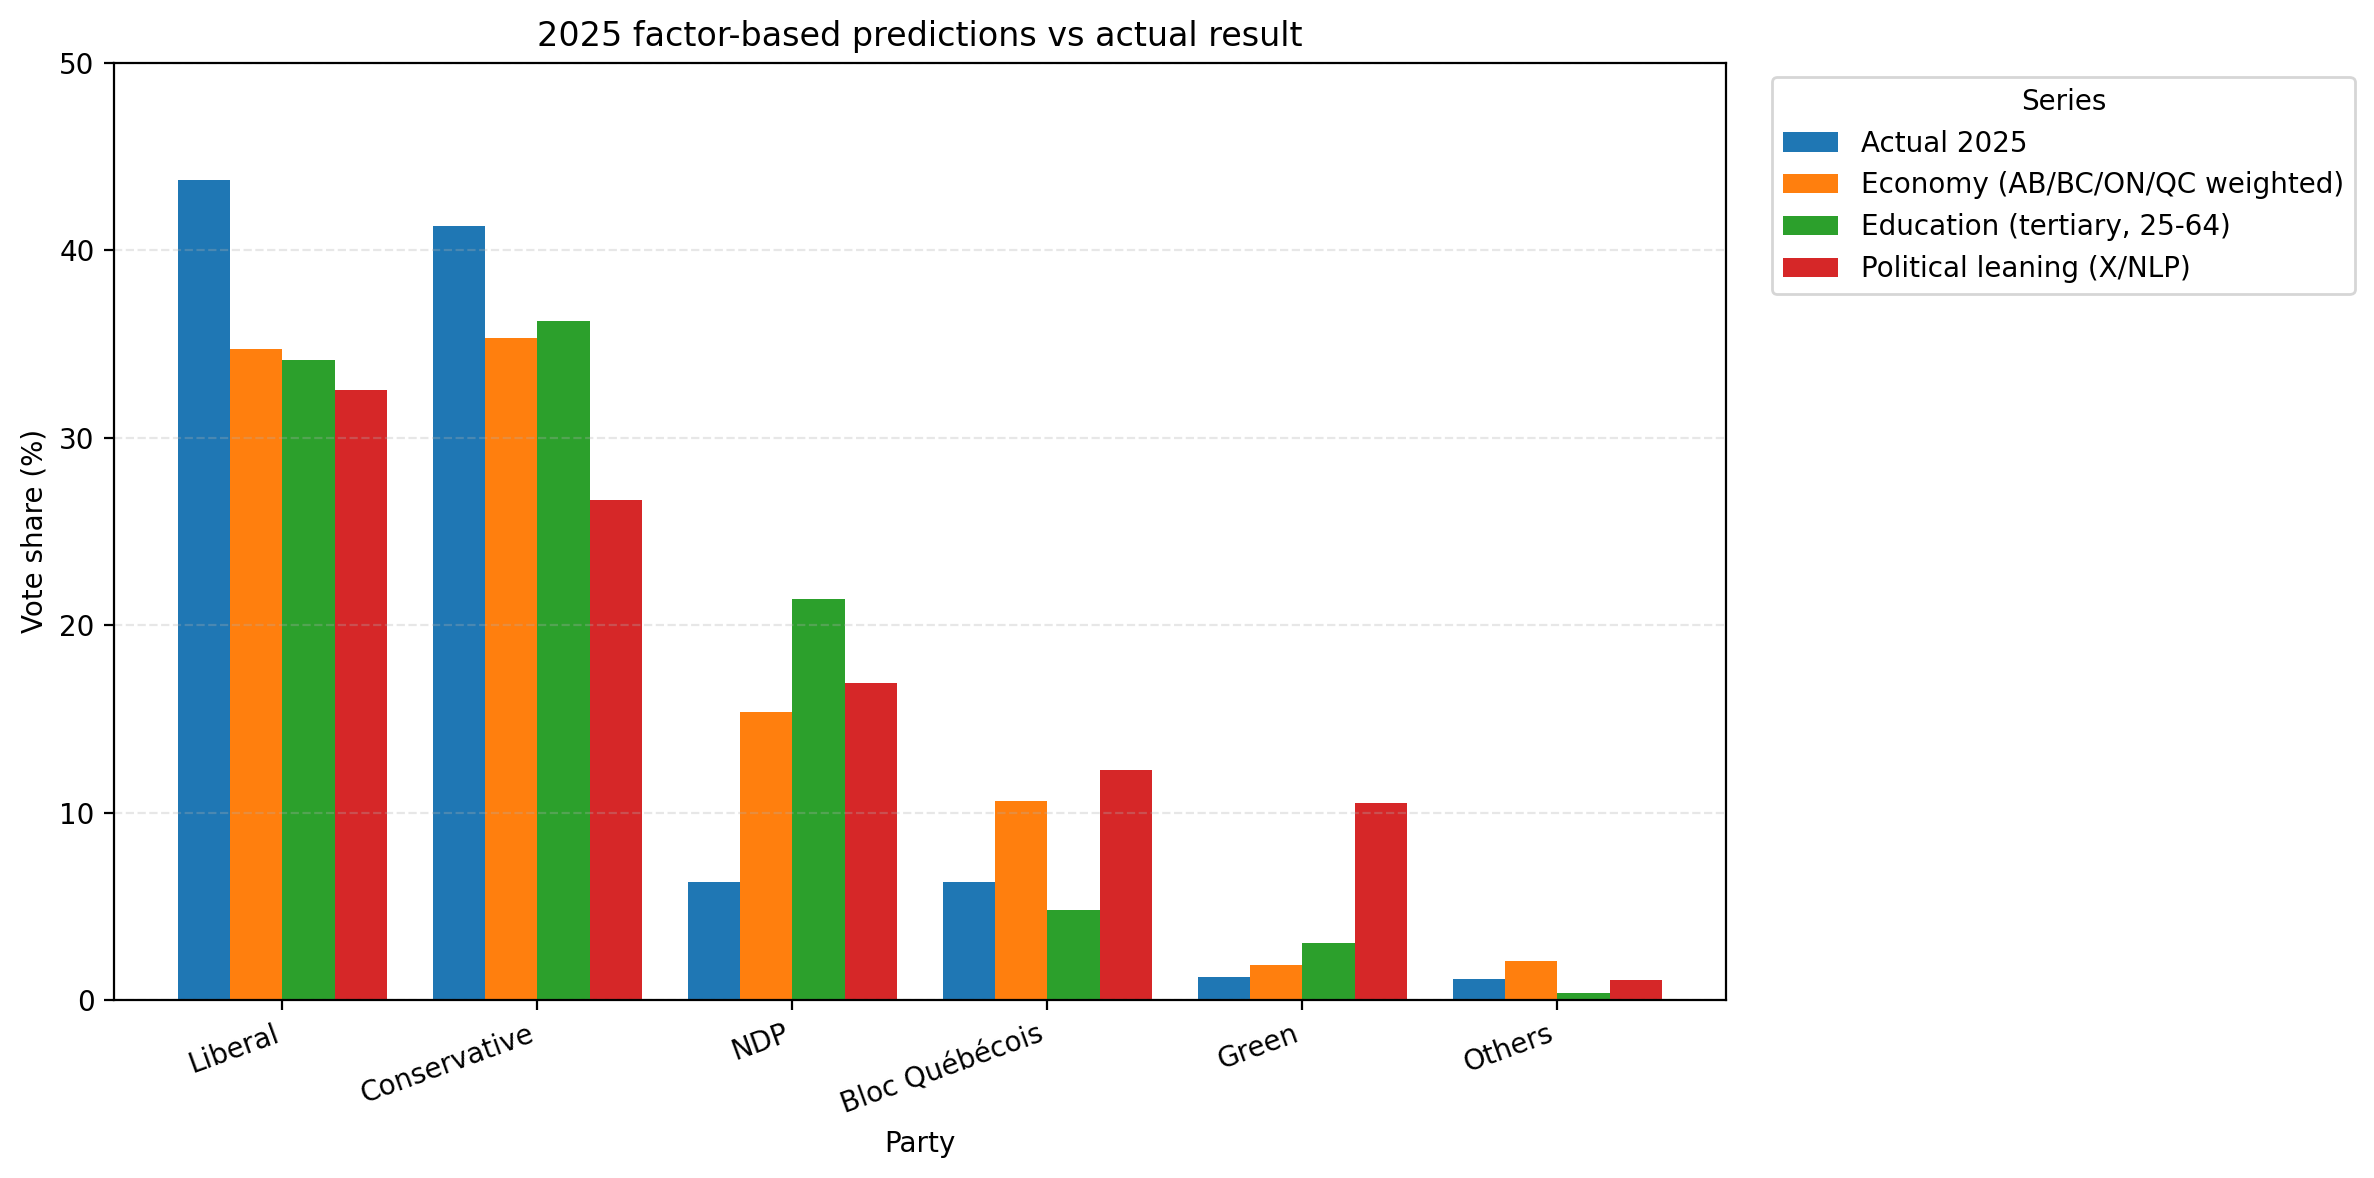

Source URLs:
- Elections Canada 2021 province results: https://www.elections.ca/content.aspx?section=res&dir=rep/off/44gedata&document=byprovtbl&lang=e
- Elections Canada 2025 province results: https://www.elections.ca/content.aspx?section=res&dir=rep/off/45gedata&document=byprovtbl&lang=e
- StatCan population (for weighting): https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip
- StatCan education: https://www150.statcan.gc.ca/n1/tbl/csv/37100130-eng.zip
- Economy inputs already cached from: https://www150.statcan.gc.ca/n1/tbl/csv/36100222-eng.zip ; https://www150.statcan.gc.ca/n1/tbl/csv/14100287-eng.zip ; https://www150.statcan.gc.ca/n1/tbl/csv/14100223-eng.zip ; https://www150.statcan.gc.ca/n1/tbl/csv/14100371-eng.zip
- X/NLP proxy summary: outputs_demographics/x_nlp_party_summary_2021_2025.csv
- 2025 X/NLP public proxy source: https://mozaikanalytics.com/blog/how-to/2025-canada-election-retrospective

Four-province population coverage used for weighting (2025): 86.54%

Factor 

In [17]:
from pathlib import Path
import zipfile
import urllib.request
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import Image as IPyImage, display
except Exception:
    IPyImage = None
    display = None

def find_project_root():
    markers = [
        'canada_federal_vote_share_2000_2025.csv',
        'canada_federal_election_province_summary_2000_2021.csv',
        'econ_2021_2025.py',
        '.git',
    ]
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    return Path.cwd()


ROOT = find_project_root()
OUT_DIR = ROOT / 'outputs_demographics'
CACHE_DIR = ROOT / 'data' / 'statcan_cache'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

PROVINCES = ['Alberta', 'British Columbia', 'Ontario', 'Quebec']
PARTIES = ['Liberal', 'Conservative', 'NDP', 'Bloc Québécois', 'Green', 'Others']
TRAIN_YEAR = 2021
TARGET_YEAR = 2025
NEXT_YEAR = 2029

ELECTION_SOURCE_URLS = {
    2021: 'https://www.elections.ca/content.aspx?section=res&dir=rep/off/44gedata&document=byprovtbl&lang=e',
    2025: 'https://www.elections.ca/content.aspx?section=res&dir=rep/off/45gedata&document=byprovtbl&lang=e',
}
STATCAN_SOURCE_URLS = {
    'population_age': 'https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip',
    'economy_composite_input': 'https://www150.statcan.gc.ca/n1/tbl/csv/36100222-eng.zip ; https://www150.statcan.gc.ca/n1/tbl/csv/14100287-eng.zip ; https://www150.statcan.gc.ca/n1/tbl/csv/14100223-eng.zip ; https://www150.statcan.gc.ca/n1/tbl/csv/14100371-eng.zip',
}


def col_like(cols, *tokens):
    tokens = [t.lower() for t in tokens]
    for col in cols:
        low = str(col).lower()
        if all(tok in low for tok in tokens):
            return col
    return None


def pick_value_label(values, contains_any):
    vals = pd.Series(values).dropna().astype(str).unique().tolist()
    for key in contains_any:
        k = key.lower()
        for val in vals:
            if k in val.lower():
                return val
    return None


def scalar_multiplier(x):
    if x is None:
        return 1.0
    text = str(x).lower().replace(',', '')
    if '1000000' in text or '1 000 000' in text or 'million' in text:
        return 1_000_000.0
    if '1000' in text or '1 000' in text or 'thousand' in text:
        return 1_000.0
    return 1.0


def to_year(series):
    y = pd.to_numeric(series, errors='coerce')
    if y.notna().any():
        return y
    d = pd.to_datetime(series, errors='coerce')
    return d.dt.year


def download_if_missing(url, path):
    if path.exists():
        return path
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=90) as resp:
        path.write_bytes(resp.read())
    return path


def load_zip_csv(path, url=None):
    if not path.exists():
        if url is None:
            raise FileNotFoundError(path)
        download_if_missing(url, path)
    with zipfile.ZipFile(path, 'r') as zf:
        names = [n for n in zf.namelist() if n.lower().endswith('.csv')]
        data_names = [n for n in names if 'meta' not in n.lower()]
        target = data_names[0] if data_names else names[0]
        with zf.open(target) as fh:
            return pd.read_csv(fh, dtype=str, low_memory=False)


def project_linear(df, group_cols, year_col, value_col, target_year):
    rows = []
    for keys, grp in df.groupby(group_cols, dropna=False):
        g = grp[[year_col, value_col]].dropna().copy()
        g[year_col] = pd.to_numeric(g[year_col], errors='coerce')
        g[value_col] = pd.to_numeric(g[value_col], errors='coerce')
        g = g.dropna().sort_values(year_col)
        if g.empty:
            pred = np.nan
        elif len(g) == 1:
            pred = float(g[value_col].iloc[-1])
        else:
            slope, intercept = np.polyfit(g[year_col], g[value_col], 1)
            pred = float(slope * target_year + intercept)
        row = {year_col: target_year, value_col: pred}
        if not isinstance(keys, tuple):
            keys = (keys,)
        for col, key in zip(group_cols, keys):
            row[col] = key
        rows.append(row)
    return pd.DataFrame(rows)


def ensure_provincial_vote_share_cache():
    cache_path = OUT_DIR / 'elections_canada_ab_bc_on_qc_vote_share_2021_2025.csv'
    if cache_path.exists():
        return pd.read_csv(cache_path)

    manual = [
        (2021, 'Alberta', 15.48, 55.42, 18.22, 0.00, 2.28),
        (2021, 'British Columbia', 26.63, 33.74, 29.50, 0.00, 8.19),
        (2021, 'Ontario', 39.50, 35.06, 17.20, 0.00, 2.29),
        (2021, 'Quebec', 33.65, 18.59, 7.90, 32.16, 2.06),
        (2025, 'Alberta', 27.26, 64.12, 0.00, 0.00, 2.55),
        (2025, 'British Columbia', 40.79, 32.54, 12.76, 0.00, 12.38),
        (2025, 'Ontario', 47.75, 44.90, 6.27, 0.00, 0.87),
        (2025, 'Quebec', 44.23, 23.70, 0.66, 27.67, 0.88),
    ]
    rows = []
    for year, province, liberal, conservative, ndp, bloc, green in manual:
        vals = {
            'Liberal': liberal,
            'Conservative': conservative,
            'NDP': ndp,
            'Bloc Québécois': bloc,
            'Green': green,
        }
        vals['Others'] = round(100.0 - sum(vals.values()), 2)
        for party, share in vals.items():
            rows.append({
                'Year': year,
                'Province': province,
                'Party': party,
                'VoteShare': share,
                'SourceURL': ELECTION_SOURCE_URLS[year],
                'SourceNote': 'Main-party percentages transcribed from official Elections Canada province result pages; Others is residual to 100%.'
            })
    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


def load_population_age_series():
    pop_raw = load_zip_csv(CACHE_DIR / '17100005-eng.zip', STATCAN_SOURCE_URLS['population_age'])
    ref = 'REF_DATE' if 'REF_DATE' in pop_raw.columns else col_like(pop_raw.columns, 'ref', 'date')
    geo = 'GEO' if 'GEO' in pop_raw.columns else col_like(pop_raw.columns, 'geo')
    val = 'VALUE' if 'VALUE' in pop_raw.columns else col_like(pop_raw.columns, 'value')
    sf = 'SCALAR_FACTOR' if 'SCALAR_FACTOR' in pop_raw.columns else col_like(pop_raw.columns, 'scalar', 'factor')
    sex_col = col_like(pop_raw.columns, 'sex') or col_like(pop_raw.columns, 'gender')
    age_col = col_like(pop_raw.columns, 'age group') or col_like(pop_raw.columns, 'age')

    total_sex = pick_value_label(pop_raw[sex_col], ['both sexes', 'total - gender', 'total - sex', 'total'])
    all_ages = pick_value_label(pop_raw[age_col], ['all ages', 'total'])
    median_age = pick_value_label(pop_raw[age_col], ['median age'])
    geos = PROVINCES + ['Canada']

    d = pop_raw[pop_raw[geo].isin(geos) & (pop_raw[sex_col] == total_sex)].copy()
    d['Year'] = to_year(d[ref])
    d['VALUE_NUM'] = pd.to_numeric(d[val], errors='coerce')
    d['mult'] = d[sf].apply(scalar_multiplier)
    d['value_scaled'] = d['VALUE_NUM'] * d['mult']

    pop = (
        d[d[age_col] == all_ages]
        .groupby([geo, 'Year'], as_index=False)['value_scaled']
        .mean()
        .rename(columns={geo: 'Province', 'value_scaled': 'Population'})
    )
    med = (
        d[d[age_col] == median_age]
        .groupby([geo, 'Year'], as_index=False)['value_scaled']
        .mean()
        .rename(columns={geo: 'Province', 'value_scaled': 'Median_age'})
    )
    return pop, med


def load_economy_factor():
    econ_path = ROOT / 'outputs_demographics' / 'econ_AB_BC_ON_QC_2021_2025.csv'
    econ = pd.read_csv(econ_path)
    metrics = ['GDP_per_capita', 'Avg_weekly_earnings', 'Job_vacancy_rate', 'Unemployment_rate']
    for col in metrics:
        econ[col] = pd.to_numeric(econ[col], errors='coerce')

    out = []
    for year, grp in econ.groupby('Year'):
        g = grp[['Province', 'Year'] + metrics].copy()
        for col in ['GDP_per_capita', 'Avg_weekly_earnings', 'Job_vacancy_rate']:
            std = g[col].std(ddof=0)
            g[f'z_{col}'] = 0.0 if std == 0 or pd.isna(std) else (g[col] - g[col].mean()) / std
        std = g['Unemployment_rate'].std(ddof=0)
        g['z_Unemployment_rate'] = 0.0 if std == 0 or pd.isna(std) else (g['Unemployment_rate'] - g['Unemployment_rate'].mean()) / std
        g['FactorValue'] = g['z_GDP_per_capita'] + g['z_Avg_weekly_earnings'] + g['z_Job_vacancy_rate'] - g['z_Unemployment_rate']
        out.append(g[['Province', 'Year', 'FactorValue']])
    econ_factor = pd.concat(out, ignore_index=True)

    next_rows = []
    for province, grp in econ_factor.groupby('Province'):
        g = grp.sort_values('Year')
        slope, intercept = np.polyfit(g['Year'], g['FactorValue'], 1)
        next_rows.append({'Province': province, 'Year': NEXT_YEAR, 'FactorValue': float(slope * NEXT_YEAR + intercept)})
    econ_factor = pd.concat([econ_factor, pd.DataFrame(next_rows)], ignore_index=True)
    return econ_factor


def build_residual_region_baseline(votes, national_2021, pop_year):
    actual_four = (
        votes[votes['Year'] == TRAIN_YEAR]
        .merge(pop_year[['Province', 'Population']], on='Province', how='left')
        .assign(weight=lambda d: d['Population'] / d['Population'].sum())
        .groupby('Party', as_index=False)
        .apply(lambda g: pd.Series({'Share': np.average(g['VoteShare'], weights=g['weight'])}), include_groups=False)
        .reset_index()
    )
    actual_four = actual_four[['Party', 'Share']]
    coverage = pop_year['Population'].sum() / canada_population.loc[canada_population['Year'] == TRAIN_YEAR, 'Population'].iloc[0]
    base = national_2021.merge(actual_four, on='Party', how='left').fillna({'Share': 0.0})
    base['ResidualShare'] = np.where(
        coverage < 1,
        (base['VoteShare'] - coverage * base['Share']) / (1 - coverage),
        base['VoteShare'],
    )
    return base[['Party', 'ResidualShare']], coverage


def predict_from_factor(name, factor_df, pop_all, national_actual):
    factor_df = factor_df.copy()
    pop_four = pop_all[pop_all['Province'].isin(PROVINCES)].copy()
    train_factor = factor_df[factor_df['Year'] == TRAIN_YEAR][['Province', 'FactorValue']].copy()
    factor_mean = train_factor['FactorValue'].mean()
    factor_std = train_factor['FactorValue'].std(ddof=0)
    scale = factor_std if factor_std and not pd.isna(factor_std) else 1.0

    coeffs = []
    train = votes[votes['Year'] == TRAIN_YEAR].merge(train_factor, on='Province', how='left')
    train['x_std'] = (train['FactorValue'] - factor_mean) / scale
    for party in PARTIES:
        s = train[train['Party'] == party].copy()
        if s['x_std'].nunique() <= 1:
            slope = 0.0
            intercept = float(s['VoteShare'].mean())
        else:
            slope, intercept = np.polyfit(s['x_std'], s['VoteShare'], 1)
        coeffs.append({'Party': party, 'Slope': float(slope), 'Intercept': float(intercept)})
    coeffs = pd.DataFrame(coeffs)

    residual_baseline, coverage_2021 = build_residual_region_baseline(
        votes,
        national_actual[national_actual['Year'] == TRAIN_YEAR][['Party', 'VoteShare']],
        pop_four[pop_four['Year'] == TRAIN_YEAR][['Province', 'Population']]
    )

    province_predictions = []
    national_predictions = []
    for year in [TRAIN_YEAR, TARGET_YEAR, NEXT_YEAR]:
        year_factor = factor_df[factor_df['Year'] == year][['Province', 'FactorValue']].copy()
        if len(year_factor) != len(PROVINCES):
            continue
        year_factor['x_std'] = (year_factor['FactorValue'] - factor_mean) / scale
        pred = year_factor.assign(key=1).merge(coeffs.assign(key=1), on='key').drop(columns='key')
        pred['PredictedShare'] = pred['Intercept'] + pred['Slope'] * pred['x_std']
        pred['PredictedShare'] = pred['PredictedShare'].clip(lower=0.0)
        totals = pred.groupby('Province')['PredictedShare'].transform('sum').replace(0, np.nan)
        pred['PredictedShare'] = np.where(totals.notna(), pred['PredictedShare'] / totals * 100.0, 100.0 / len(PARTIES))
        pred['Year'] = year
        province_predictions.append(pred[['Year', 'Province', 'Party', 'PredictedShare']])

        pop_y = pop_all[(pop_all['Province'].isin(PROVINCES)) & (pop_all['Year'] == year)][['Province', 'Population']].copy()
        canada_y = canada_population.loc[canada_population['Year'] == year, 'Population']
        if pop_y.empty or canada_y.empty:
            continue
        canada_pop = float(canada_y.iloc[0])
        coverage_y = pop_y['Population'].sum() / canada_pop
        agg = pred.merge(pop_y, on='Province', how='left')
        agg['NationalWeight'] = agg['Population'] / canada_pop
        national = agg.groupby('Party', as_index=False).apply(
            lambda g: pd.Series({'WeightedFourProvinceShare': g['NationalWeight'].mul(g['PredictedShare']).sum()}),
            include_groups=False,
        ).reset_index()[['Party', 'WeightedFourProvinceShare']]
        national = national.merge(residual_baseline, on='Party', how='left').fillna({'ResidualShare': 0.0})
        national['PredictedVoteShare'] = national['WeightedFourProvinceShare'] + (1 - coverage_y) * national['ResidualShare']
        national['PredictedVoteShare'] = national['PredictedVoteShare'].clip(lower=0.0)
        total = national['PredictedVoteShare'].sum()
        if total > 0:
            national['PredictedVoteShare'] = national['PredictedVoteShare'] / total * 100.0
        national['Year'] = year
        national['Factor'] = name
        national['CoverageShare'] = coverage_y
        national_predictions.append(national[['Factor', 'Year', 'Party', 'PredictedVoteShare', 'CoverageShare']])

    if not national_predictions:
        return None

    province_predictions = pd.concat(province_predictions, ignore_index=True) if province_predictions else pd.DataFrame()
    national_predictions = pd.concat(national_predictions, ignore_index=True)

    pred_2025 = national_predictions[national_predictions['Year'] == TARGET_YEAR][['Party', 'PredictedVoteShare']]
    actual_2025 = national_actual[national_actual['Year'] == TARGET_YEAR][['Party', 'VoteShare']]
    comp_2025 = pred_2025.merge(actual_2025, on='Party', how='left')
    comp_2025['AbsError'] = (comp_2025['PredictedVoteShare'] - comp_2025['VoteShare']).abs()
    comp_2025['SqError'] = (comp_2025['PredictedVoteShare'] - comp_2025['VoteShare']) ** 2

    pred_2021 = national_predictions[national_predictions['Year'] == TRAIN_YEAR][['Party', 'PredictedVoteShare']].rename(columns={'PredictedVoteShare': 'Predicted2021'})
    impact = pred_2025.merge(pred_2021, on='Party', how='left')
    impact_score = (impact['PredictedVoteShare'] - impact['Predicted2021']).abs().mean()

    return {
        'factor': name,
        'province_predictions': province_predictions,
        'national_predictions': national_predictions,
        'fit_mae': float(comp_2025['AbsError'].mean()),
        'fit_rmse': float(np.sqrt(comp_2025['SqError'].mean())),
        'impact_score': float(impact_score),
        'coverage_2025': float(national_predictions.loc[national_predictions['Year'] == TARGET_YEAR, 'CoverageShare'].iloc[0]),
    }


votes = ensure_provincial_vote_share_cache()
votes['VoteShare'] = pd.to_numeric(votes['VoteShare'], errors='coerce')

national_actual = pd.read_csv(ROOT / 'outputs' / 'national_vote_share_clean.csv')
national_actual = national_actual[national_actual['Year'].isin([TRAIN_YEAR, TARGET_YEAR])].copy()
national_actual['VoteShare'] = pd.to_numeric(national_actual['VoteShare'], errors='coerce')
national_actual = national_actual[national_actual['Party'].isin(PARTIES)].copy()

population_all, _ = load_population_age_series()
population_all['Population'] = pd.to_numeric(population_all['Population'], errors='coerce')
canada_population = population_all[population_all['Province'] == 'Canada'].copy()
population_four = population_all[population_all['Province'].isin(PROVINCES)].copy()

# Add 2029 projected populations for weighting.
pop_proj = project_linear(population_four[population_four['Year'].between(2021, 2025)], ['Province'], 'Year', 'Population', NEXT_YEAR)
can_proj = project_linear(canada_population[canada_population['Year'].between(2021, 2025)], ['Province'], 'Year', 'Population', NEXT_YEAR)
population_all = pd.concat([population_all, pop_proj, can_proj], ignore_index=True)
canada_population = population_all[population_all['Province'] == 'Canada'].copy()


# Rebase economy factor from existing synchronized 2021/2025 file and linearly project to 2029.
economy_factor = load_economy_factor()

def predict_from_x_nlp_factor(x_summary_path, national_actual):
    if not x_summary_path.exists():
        return None, 'missing_x_nlp_summary_csv'

    x_df = pd.read_csv(x_summary_path)
    main_parties = ['Liberal', 'Conservative', 'NDP', 'Bloc Québécois', 'Green']
    needed_years = {TRAIN_YEAR, TARGET_YEAR, NEXT_YEAR}
    x_df = x_df[x_df['Party'].isin(main_parties) & x_df['Year'].isin(needed_years)].copy()
    if x_df.empty:
        return None, 'empty_x_nlp_summary_csv'

    for col in ['SupportIndex', 'XShare']:
        x_df[col] = pd.to_numeric(x_df[col], errors='coerce')

    year_counts = x_df.groupby('Year')['Party'].nunique().to_dict()
    if any(year_counts.get(year, 0) < len(main_parties) for year in needed_years):
        return None, 'insufficient_x_party_rows'

    actual_main_2021 = national_actual[(national_actual['Year'] == TRAIN_YEAR) & (national_actual['Party'].isin(main_parties))][['Party', 'VoteShare']].copy()
    if len(actual_main_2021) < len(main_parties):
        return None, 'missing_actual_2021_for_x_factor'

    train = x_df[x_df['Year'] == TRAIN_YEAR][['Party', 'SupportIndex', 'XShare']].merge(actual_main_2021, on='Party', how='inner')
    if len(train) < len(main_parties):
        return None, 'missing_x_train_rows'

    train['VoteShareMain'] = train['VoteShare'] / train['VoteShare'].sum()
    X = np.column_stack([
        np.ones(len(train)),
        train['SupportIndex'].to_numpy(),
        np.log(train['XShare'].clip(lower=1e-6)).to_numpy(),
    ])
    y = np.log(train['VoteShareMain'].clip(lower=1e-6)).to_numpy()
    ridge = 0.2
    penalty = np.eye(X.shape[1])
    penalty[0, 0] = 0.0
    beta = np.linalg.solve(X.T @ X + ridge * penalty, X.T @ y)

    others_baseline = national_actual[(national_actual['Year'] == TRAIN_YEAR) & (national_actual['Party'] == 'Others')]['VoteShare']
    others_baseline = float(others_baseline.iloc[0]) if not others_baseline.empty else 0.0

    national_predictions = []
    for year in [TRAIN_YEAR, TARGET_YEAR, NEXT_YEAR]:
        frame = x_df[x_df['Year'] == year][['Party', 'SupportIndex', 'XShare']].copy()
        frame = frame.dropna(subset=['SupportIndex', 'XShare'])
        frame = frame.set_index('Party').reindex(main_parties).reset_index()
        if frame['SupportIndex'].isna().any() or frame['XShare'].isna().any():
            continue
        Z = np.column_stack([
            np.ones(len(frame)),
            frame['SupportIndex'].to_numpy(),
            np.log(frame['XShare'].clip(lower=1e-6)).to_numpy(),
        ])
        logits = Z @ beta
        main_share = np.exp(logits - logits.max())
        main_share = main_share / main_share.sum()
        main_total = max(0.0, 100.0 - others_baseline)
        pred_main = main_share * main_total
        national = pd.DataFrame({
            'Factor': 'Political leaning (X/NLP)',
            'Year': year,
            'Party': main_parties,
            'PredictedVoteShare': pred_main,
            'CoverageShare': 1.0,
        })
        national = pd.concat([
            national,
            pd.DataFrame({
                'Factor': ['Political leaning (X/NLP)'],
                'Year': [year],
                'Party': ['Others'],
                'PredictedVoteShare': [others_baseline],
                'CoverageShare': [1.0],
            }),
        ], ignore_index=True)
        national_predictions.append(national)

    if not national_predictions:
        return None, 'x_predictions_not_generated'

    national_predictions = pd.concat(national_predictions, ignore_index=True)
    pred_2025 = national_predictions[national_predictions['Year'] == TARGET_YEAR][['Party', 'PredictedVoteShare']]
    actual_2025 = national_actual[national_actual['Year'] == TARGET_YEAR][['Party', 'VoteShare']]
    comp_2025 = pred_2025.merge(actual_2025, on='Party', how='left')
    comp_2025['AbsError'] = (comp_2025['PredictedVoteShare'] - comp_2025['VoteShare']).abs()
    comp_2025['SqError'] = (comp_2025['PredictedVoteShare'] - comp_2025['VoteShare']) ** 2

    pred_2021 = national_predictions[national_predictions['Year'] == TRAIN_YEAR][['Party', 'PredictedVoteShare']].rename(columns={'PredictedVoteShare': 'Predicted2021'})
    impact = pred_2025.merge(pred_2021, on='Party', how='left')
    impact_score = (impact['PredictedVoteShare'] - impact['Predicted2021']).abs().mean()

    return {
        'factor': 'Political leaning (X/NLP)',
        'province_predictions': pd.DataFrame(),
        'national_predictions': national_predictions,
        'fit_mae': float(comp_2025['AbsError'].mean()),
        'fit_rmse': float(np.sqrt(comp_2025['SqError'].mean())),
        'impact_score': float(impact_score),
        'coverage_2025': 1.0,
    }, 'ranked'


factor_series = {
    'Economy (AB/BC/ON/QC weighted)': economy_factor,
}

factor_results = []
for factor_name, factor_df in factor_series.items():
    result = predict_from_factor(factor_name, factor_df, population_all, national_actual)
    if result:
        factor_results.append(result)

x_summary_path = OUT_DIR / 'x_nlp_party_summary_2021_2025.csv'
x_result, x_status = predict_from_x_nlp_factor(x_summary_path, national_actual)
if x_result:
    factor_results.append(x_result)

summary_rows = [
    {
        'Factor': r['factor'],
        'ImpactScore': r['impact_score'],
        'FitMAE_2025': r['fit_mae'],
        'FitRMSE_2025': r['fit_rmse'],
        'CoverageShare_2025': r['coverage_2025'],
        'Status': 'ranked',
    }
    for r in factor_results
]

if not x_result:
    summary_rows.append({
        'Factor': 'Political leaning (X/NLP)',
        'ImpactScore': np.nan,
        'FitMAE_2025': np.nan,
        'FitRMSE_2025': np.nan,
        'CoverageShare_2025': np.nan,
        'Status': x_status,
    })

factor_summary = pd.DataFrame(summary_rows)
status_order = {'ranked': 0}
factor_summary['StatusOrder'] = factor_summary['Status'].map(status_order).fillna(1)
factor_summary = factor_summary.sort_values(['StatusOrder', 'FitMAE_2025', 'ImpactScore'], na_position='last').drop(columns='StatusOrder')
ranked = factor_summary[factor_summary['Status'] == 'ranked'].copy()
most_impact_factor = ranked.sort_values('ImpactScore', ascending=False).iloc[0]['Factor']
best_fit_factor = ranked.sort_values('FitMAE_2025').iloc[0]['Factor']

all_national_preds = pd.concat([r['national_predictions'] for r in factor_results], ignore_index=True)
pred_2025 = all_national_preds[all_national_preds['Year'] == TARGET_YEAR].copy()
pred_2025 = pred_2025.merge(national_actual[national_actual['Year'] == TARGET_YEAR][['Party', 'VoteShare']], on='Party', how='left')
pred_2025 = pred_2025.rename(columns={'VoteShare': 'ActualVoteShare'})

next_factors = []
for label in [most_impact_factor, best_fit_factor]:
    next_pred = all_national_preds[(all_national_preds['Factor'] == label) & (all_national_preds['Year'] == NEXT_YEAR)].copy()
    next_pred['Scenario'] = label
    next_factors.append(next_pred)

next_predictions = pd.concat(next_factors, ignore_index=True)
if most_impact_factor != best_fit_factor:
    ensemble = (
        next_predictions.groupby('Party', as_index=False)['PredictedVoteShare']
        .mean()
        .assign(Factor='Average of top-impact and best-fit factors', Year=NEXT_YEAR, CoverageShare=np.nan, Scenario='Average of top-impact and best-fit factors')
    )
    next_predictions = pd.concat([next_predictions, ensemble], ignore_index=True)

factor_summary.to_csv(OUT_DIR / 'factor_fit_impact_summary.csv', index=False)
pred_2025.to_csv(OUT_DIR / 'factor_based_2025_predictions.csv', index=False)
next_predictions.to_csv(OUT_DIR / 'factor_next_election_predictions.csv', index=False)


comparison_chart = (
    pred_2025
    .pivot_table(index='Party', columns='Factor', values='PredictedVoteShare')
    .merge(
        national_actual[national_actual['Year'] == TARGET_YEAR][['Party', 'VoteShare']].set_index('Party'),
        left_index=True,
        right_index=True,
        how='left',
    )
    .rename(columns={'VoteShare': 'Actual 2025'})
)
plot_cols = ['Actual 2025'] + [c for c in comparison_chart.columns if c != 'Actual 2025']
comparison_chart = comparison_chart[plot_cols].reindex(PARTIES)
ax = comparison_chart.plot(kind='bar', figsize=(12, 6), width=0.82)
ax.set_title('2025 factor-based predictions vs actual result')
ax.set_xlabel('Party')
ax.set_ylabel('Vote share (%)')
ax.set_ylim(0, max(50, float(np.nanmax(comparison_chart.values)) + 5))
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Series', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
comparison_chart_path = OUT_DIR / 'factor_2025_predictions_vs_actual.png'
plt.savefig(comparison_chart_path, dpi=200, bbox_inches='tight')
plt.close()
if 'ipykernel' in sys.modules and IPyImage is not None and display is not None:
    display(IPyImage(filename=str(comparison_chart_path)))

coverage_2025 = ranked['CoverageShare_2025'].dropna().iloc[0]
print('Source URLs:')
print(f"- Elections Canada 2021 province results: {ELECTION_SOURCE_URLS[2021]}")
print(f"- Elections Canada 2025 province results: {ELECTION_SOURCE_URLS[2025]}")
print(f"- StatCan population (for weighting): {STATCAN_SOURCE_URLS['population_age']}")
print(f"- Economy inputs already cached from: {STATCAN_SOURCE_URLS['economy_composite_input']}")
print('- X/NLP proxy summary: outputs_demographics/x_nlp_party_summary_2021_2025.csv')
print('- 2025 X/NLP public proxy source: https://mozaikanalytics.com/blog/how-to/2025-canada-election-retrospective')
print('')
print(f'Four-province population coverage used for weighting (2025): {coverage_2025:.2%}')
print('')
print('Factor comparison summary:')
print(factor_summary.to_string(index=False))
print('')
print(f'Most impactful factor: {most_impact_factor}')
print(f'Best 2025 fit factor: {best_fit_factor}')
print('')
print('2025 factor-based predictions vs actual:')
print(
    pred_2025
    .pivot_table(index='Party', columns='Factor', values='PredictedVoteShare')
    .merge(national_actual[national_actual['Year'] == TARGET_YEAR][['Party', 'VoteShare']].set_index('Party'), left_index=True, right_index=True, how='left')
    .rename(columns={'VoteShare': 'Actual 2025'})
    .round(2)
    .to_string()
)
print('')
print(f'Next-cycle baseline year used for projection: {NEXT_YEAR}')
print(next_predictions.pivot_table(index='Party', columns='Scenario', values='PredictedVoteShare').round(2).to_string())


## Education-Attainment 2025 Prediction Comparison

**Objective**
This section isolates education and tests whether different education-attainment definitions produce different 2025 election predictions.

**Method**
- Use Statistics Canada table `37100130` (`Total - Gender`, `Total, 25 to 64 years`) for Alberta, British Columbia, Ontario, and Quebec.
- Fit a separate 2021 province-level single-factor model for each education attainment level.
- Extrapolate 2025 education shares from `2021-2024` because the annual table currently ends at `2024`.
- Convert four-province predictions to a national estimate using population weighting plus a residual rest-of-Canada baseline.
- Compare education definitions by `FitMAE_2025` and visualize the best-fitting education model against the real 2025 result.

**Source URLs**
- Elections Canada 2021 province results: https://www.elections.ca/content.aspx?section=res&dir=rep/off/44gedata&document=byprovtbl&lang=e
- Elections Canada 2025 province results: https://www.elections.ca/content.aspx?section=res&dir=rep/off/45gedata&document=byprovtbl&lang=e
- Statistics Canada education attainment: https://www150.statcan.gc.ca/n1/tbl/csv/37100130-eng.zip
- Statistics Canada population (used for four-province weighting): https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip


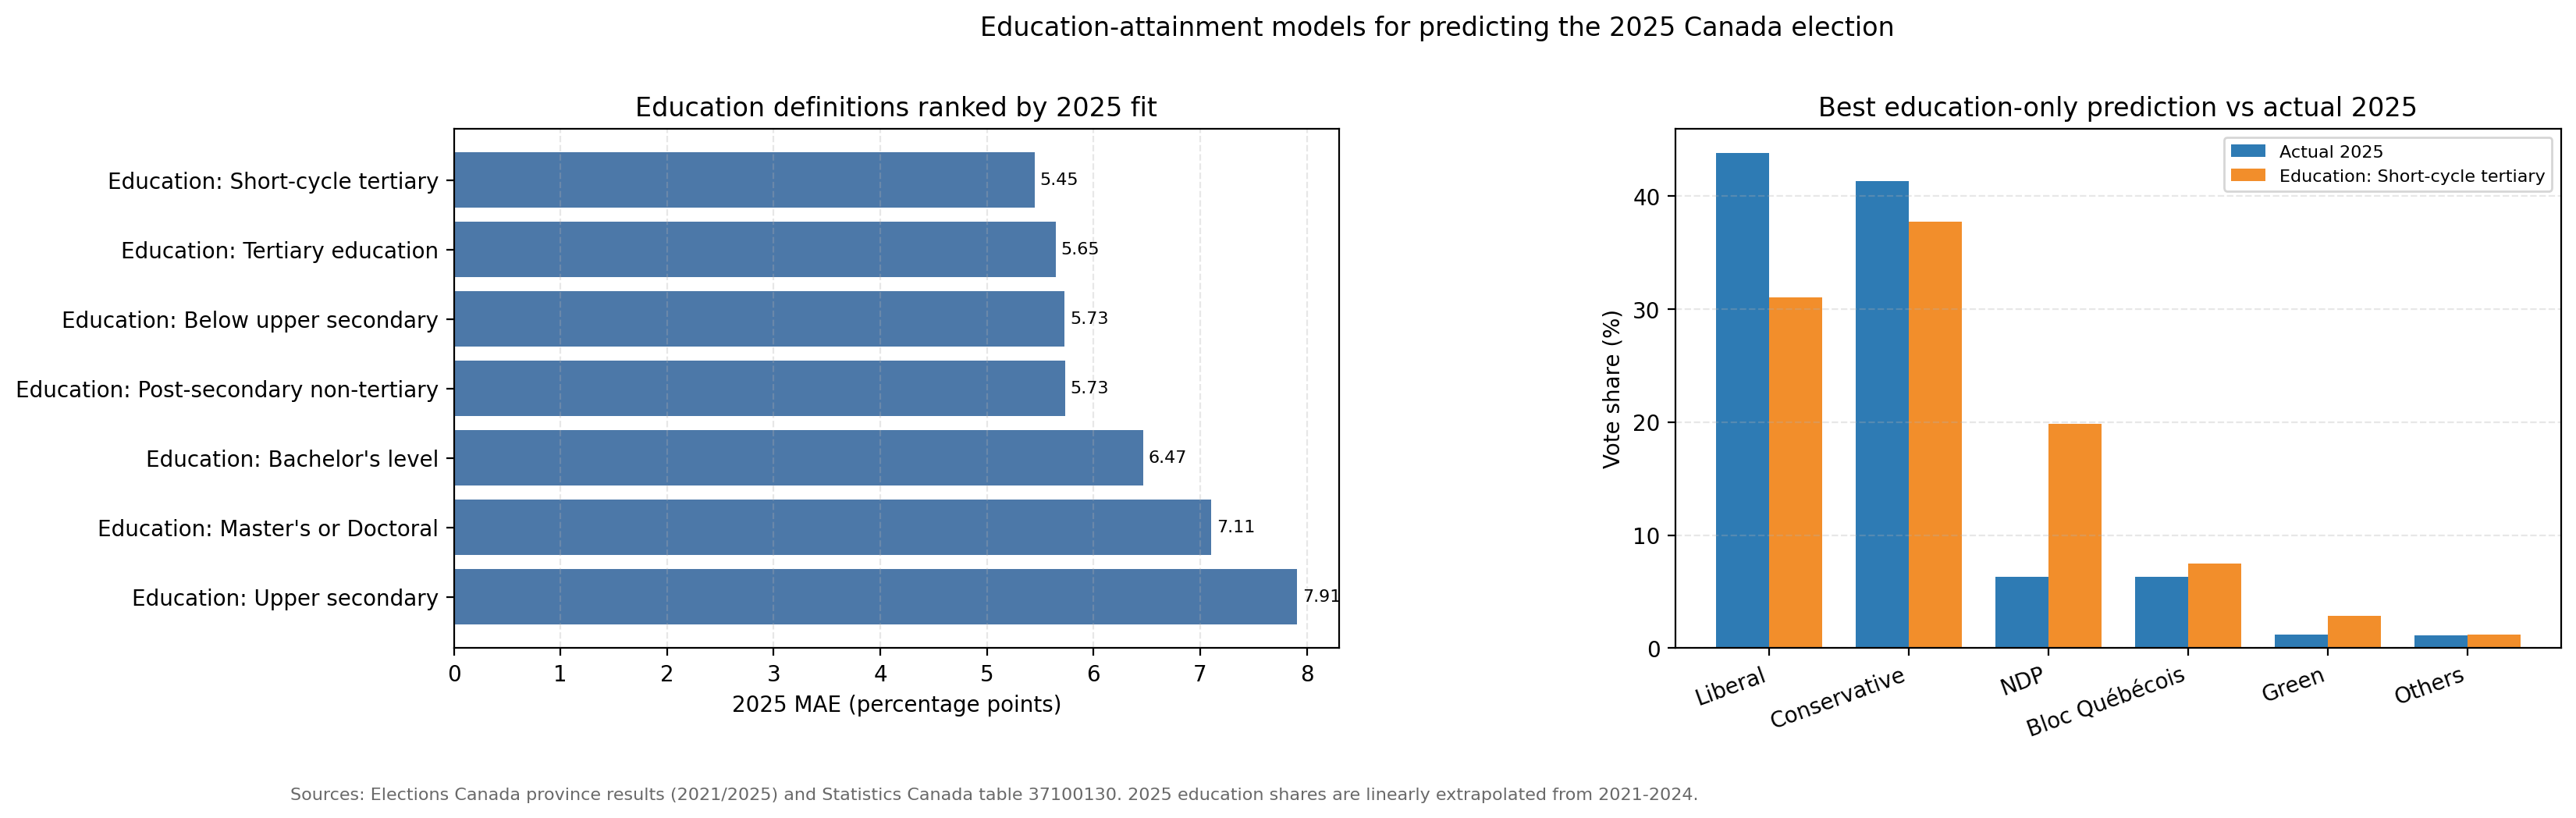

Source URLs:
- Elections Canada 2021 province results: https://www.elections.ca/content.aspx?section=res&dir=rep/off/44gedata&document=byprovtbl&lang=e
- Elections Canada 2025 province results: https://www.elections.ca/content.aspx?section=res&dir=rep/off/45gedata&document=byprovtbl&lang=e
- StatCan education attainment: https://www150.statcan.gc.ca/n1/tbl/csv/37100130-eng.zip
- StatCan population (for weighting): https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip

Education-attainment fit summary:
                                Factor                        EducationLevel  FitMAE_2025  FitRMSE_2025
       Education: Short-cycle tertiary                  Short-cycle tertiary        5.448         7.773
         Education: Tertiary education                    Tertiary education        5.645         7.673
      Education: Below upper secondary                 Below upper secondary        5.727         8.509
Education: Post-secondary non-tertiary Post-secondary non-tertiary educati

In [22]:
from pathlib import Path
import zipfile
import urllib.request
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import Image as IPyImage, display
except Exception:
    IPyImage = None
    display = None

PROJECT_MARKERS = (
    '.git',
    'canada_federal_vote_share_2000_2025.csv',
    'econ_2021_2025.py',
)
PROVINCES = ['Alberta', 'British Columbia', 'Ontario', 'Quebec']
PARTIES = ['Liberal', 'Conservative', 'NDP', 'Bloc Québécois', 'Green', 'Others']
TRAIN_YEAR = 2021
TARGET_YEAR = 2025

ELECTION_SOURCE_URLS = {
    2021: 'https://www.elections.ca/content.aspx?section=res&dir=rep/off/44gedata&document=byprovtbl&lang=e',
    2025: 'https://www.elections.ca/content.aspx?section=res&dir=rep/off/45gedata&document=byprovtbl&lang=e',
}
STATCAN_SOURCE_URLS = {
    'population': 'https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip',
    'education': 'https://www150.statcan.gc.ca/n1/tbl/csv/37100130-eng.zip',
}
EDUCATION_LEVELS = [
    ('Below upper secondary', 'Below upper secondary'),
    ('Upper secondary', 'Upper secondary'),
    ('Post-secondary non-tertiary', 'Post-secondary non-tertiary education'),
    ('Short-cycle tertiary', 'Short-cycle tertiary'),
    ("Bachelor's level", "Bachelor's level"),
    ("Master's or Doctoral", "Master's or Doctoral level"),
    ('Tertiary education', 'Tertiary education'),
]


def find_project_root():
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if any((candidate / marker).exists() for marker in PROJECT_MARKERS):
            return candidate
    return start


def col_like(cols, *tokens):
    tokens = [t.lower() for t in tokens]
    for col in cols:
        low = str(col).lower()
        if all(tok in low for tok in tokens):
            return col
    return None


def pick_value_label(values, contains_any):
    vals = pd.Series(values).dropna().astype(str).unique().tolist()
    for key in contains_any:
        k = key.lower()
        for val in vals:
            if k in val.lower():
                return val
    return None


def scalar_multiplier(x):
    if x is None:
        return 1.0
    text = str(x).lower().replace(',', '')
    if '1000000' in text or '1 000 000' in text or 'million' in text:
        return 1_000_000.0
    if '1000' in text or '1 000' in text or 'thousand' in text:
        return 1_000.0
    return 1.0


def to_year(series):
    y = pd.to_numeric(series, errors='coerce')
    if y.notna().any():
        return y
    d = pd.to_datetime(series, errors='coerce')
    return d.dt.year


def download_if_missing(url, path):
    if path.exists():
        return path
    path.parent.mkdir(parents=True, exist_ok=True)
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=120) as resp:
        path.write_bytes(resp.read())
    return path


def load_zip_csv(path, url=None):
    if not path.exists():
        if url is None:
            raise FileNotFoundError(path)
        download_if_missing(url, path)
    with zipfile.ZipFile(path, 'r') as zf:
        names = [n for n in zf.namelist() if n.lower().endswith('.csv')]
        data_names = [n for n in names if 'meta' not in n.lower()]
        target = data_names[0] if data_names else names[0]
        with zf.open(target) as fh:
            return pd.read_csv(fh, dtype=str, low_memory=False)


def project_linear(df, group_cols, year_col, value_col, target_year):
    rows = []
    for keys, grp in df.groupby(group_cols, dropna=False):
        g = grp[[year_col, value_col]].dropna().copy()
        g[year_col] = pd.to_numeric(g[year_col], errors='coerce')
        g[value_col] = pd.to_numeric(g[value_col], errors='coerce')
        g = g.dropna().sort_values(year_col)
        if g.empty:
            pred = np.nan
        elif len(g) == 1:
            pred = float(g[value_col].iloc[-1])
        else:
            slope, intercept = np.polyfit(g[year_col], g[value_col], 1)
            pred = float(slope * target_year + intercept)
        row = {year_col: target_year, value_col: pred}
        if not isinstance(keys, tuple):
            keys = (keys,)
        for col, key in zip(group_cols, keys):
            row[col] = key
        rows.append(row)
    return pd.DataFrame(rows)


def ensure_provincial_vote_share_cache(root, out_dir):
    cache_path = out_dir / 'elections_canada_ab_bc_on_qc_vote_share_2021_2025.csv'
    if cache_path.exists():
        return pd.read_csv(cache_path)

    manual = [
        (2021, 'Alberta', 15.48, 55.42, 18.22, 0.00, 2.28),
        (2021, 'British Columbia', 26.63, 33.74, 29.50, 0.00, 8.19),
        (2021, 'Ontario', 39.50, 35.06, 17.20, 0.00, 2.29),
        (2021, 'Quebec', 33.65, 18.59, 7.90, 32.16, 2.06),
        (2025, 'Alberta', 27.26, 64.12, 0.00, 0.00, 2.55),
        (2025, 'British Columbia', 40.79, 32.54, 12.76, 0.00, 12.38),
        (2025, 'Ontario', 47.75, 44.90, 6.27, 0.00, 0.87),
        (2025, 'Quebec', 44.23, 23.70, 0.66, 27.67, 0.88),
    ]
    rows = []
    for year, province, liberal, conservative, ndp, bloc, green in manual:
        vals = {
            'Liberal': liberal,
            'Conservative': conservative,
            'NDP': ndp,
            'Bloc Québécois': bloc,
            'Green': green,
        }
        vals['Others'] = round(100.0 - sum(vals.values()), 2)
        for party, share in vals.items():
            rows.append({
                'Year': year,
                'Province': province,
                'Party': party,
                'VoteShare': share,
                'SourceURL': ELECTION_SOURCE_URLS[year],
                'SourceNote': 'Main-party percentages transcribed from official Elections Canada province result pages; Others is residual to 100%.',
            })
    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


def load_population_series(cache_dir):
    pop_raw = load_zip_csv(cache_dir / '17100005-eng.zip', STATCAN_SOURCE_URLS['population'])
    ref = 'REF_DATE' if 'REF_DATE' in pop_raw.columns else col_like(pop_raw.columns, 'ref', 'date')
    geo = 'GEO' if 'GEO' in pop_raw.columns else col_like(pop_raw.columns, 'geo')
    val = 'VALUE' if 'VALUE' in pop_raw.columns else col_like(pop_raw.columns, 'value')
    sf = 'SCALAR_FACTOR' if 'SCALAR_FACTOR' in pop_raw.columns else col_like(pop_raw.columns, 'scalar', 'factor')
    sex_col = col_like(pop_raw.columns, 'sex') or col_like(pop_raw.columns, 'gender')
    age_col = col_like(pop_raw.columns, 'age group') or col_like(pop_raw.columns, 'age')

    total_sex = pick_value_label(pop_raw[sex_col], ['both sexes', 'total - gender', 'total - sex', 'total'])
    all_ages = pick_value_label(pop_raw[age_col], ['all ages', 'total'])
    geos = PROVINCES + ['Canada']

    d = pop_raw[pop_raw[geo].isin(geos) & (pop_raw[sex_col] == total_sex)].copy()
    d['Year'] = to_year(d[ref])
    d['VALUE_NUM'] = pd.to_numeric(d[val], errors='coerce')
    d['mult'] = d[sf].apply(scalar_multiplier)
    d['value_scaled'] = d['VALUE_NUM'] * d['mult']

    pop = (
        d[d[age_col] == all_ages]
        .groupby([geo, 'Year'], as_index=False)['value_scaled']
        .mean()
        .rename(columns={geo: 'Province', 'value_scaled': 'Population'})
    )
    pop['Population'] = pd.to_numeric(pop['Population'], errors='coerce')
    return pop.dropna(subset=['Population'])


def load_education_level_series(cache_dir, education_level):
    edu_raw = load_zip_csv(cache_dir / '37100130-eng.zip', STATCAN_SOURCE_URLS['education'])
    d = edu_raw[
        edu_raw['GEO'].isin(PROVINCES)
        & (edu_raw['Gender'] == 'Total - Gender')
        & (edu_raw['Age group'] == 'Total, 25 to 64 years')
        & (edu_raw['Education attainment level'] == education_level)
    ].copy()
    d['Year'] = pd.to_numeric(d['REF_DATE'], errors='coerce')
    d['FactorValue'] = pd.to_numeric(d['VALUE'], errors='coerce')
    d = d[['GEO', 'Year', 'FactorValue']].rename(columns={'GEO': 'Province'})
    return d.dropna(subset=['Year', 'FactorValue'])


def build_residual_region_baseline(votes, national_2021, pop_2021, canada_population):
    actual_four = (
        votes[votes['Year'] == TRAIN_YEAR]
        .merge(pop_2021[['Province', 'Population']], on='Province', how='left')
        .assign(weight=lambda d: d['Population'] / d['Population'].sum())
        .groupby('Party', as_index=False)
        .apply(lambda g: pd.Series({'Share': np.average(g['VoteShare'], weights=g['weight'])}), include_groups=False)
        .reset_index()
    )
    actual_four = actual_four[['Party', 'Share']]
    coverage = pop_2021['Population'].sum() / canada_population.loc[canada_population['Year'] == TRAIN_YEAR, 'Population'].iloc[0]
    base = national_2021.merge(actual_four, on='Party', how='left').fillna({'Share': 0.0})
    base['ResidualShare'] = np.where(
        coverage < 1,
        (base['VoteShare'] - coverage * base['Share']) / (1 - coverage),
        base['VoteShare'],
    )
    return base[['Party', 'ResidualShare']], coverage


def predict_from_factor(name, factor_df, votes, pop_all, national_actual, canada_population):
    factor_df = factor_df.copy()
    pop_four = pop_all[pop_all['Province'].isin(PROVINCES)].copy()
    train_factor = factor_df[factor_df['Year'] == TRAIN_YEAR][['Province', 'FactorValue']].copy()
    if train_factor['Province'].nunique() < len(PROVINCES):
        return None

    factor_mean = train_factor['FactorValue'].mean()
    factor_std = train_factor['FactorValue'].std(ddof=0)
    scale = factor_std if factor_std and not pd.isna(factor_std) else 1.0

    coeffs = []
    train = votes[votes['Year'] == TRAIN_YEAR].merge(train_factor, on='Province', how='left')
    train['x_std'] = (train['FactorValue'] - factor_mean) / scale
    for party in PARTIES:
        s = train[train['Party'] == party].copy()
        if s['x_std'].nunique() <= 1:
            slope = 0.0
            intercept = float(s['VoteShare'].mean())
        else:
            slope, intercept = np.polyfit(s['x_std'], s['VoteShare'], 1)
        coeffs.append({'Party': party, 'Slope': float(slope), 'Intercept': float(intercept)})
    coeffs = pd.DataFrame(coeffs)

    residual_baseline, _ = build_residual_region_baseline(
        votes,
        national_actual[national_actual['Year'] == TRAIN_YEAR][['Party', 'VoteShare']],
        pop_four[pop_four['Year'] == TRAIN_YEAR][['Province', 'Population']],
        canada_population,
    )

    national_predictions = []
    for year in [TRAIN_YEAR, TARGET_YEAR]:
        year_factor = factor_df[factor_df['Year'] == year][['Province', 'FactorValue']].copy()
        if len(year_factor) != len(PROVINCES):
            continue
        year_factor['x_std'] = (year_factor['FactorValue'] - factor_mean) / scale
        pred = year_factor.assign(key=1).merge(coeffs.assign(key=1), on='key').drop(columns='key')
        pred['PredictedShare'] = pred['Intercept'] + pred['Slope'] * pred['x_std']
        pred['PredictedShare'] = pred['PredictedShare'].clip(lower=0.0)
        totals = pred.groupby('Province')['PredictedShare'].transform('sum').replace(0, np.nan)
        pred['PredictedShare'] = np.where(totals.notna(), pred['PredictedShare'] / totals * 100.0, 100.0 / len(PARTIES))

        pop_y = pop_all[(pop_all['Province'].isin(PROVINCES)) & (pop_all['Year'] == year)][['Province', 'Population']].copy()
        canada_y = canada_population.loc[canada_population['Year'] == year, 'Population']
        if pop_y.empty or canada_y.empty:
            continue
        coverage = pop_y['Population'].sum() / canada_y.iloc[0]
        pred = pred.merge(pop_y, on='Province', how='left')
        pred['weight'] = pred['Population'] / pred['Population'].sum()
        national_main = pred.groupby('Party', as_index=False).apply(
            lambda g: pd.Series({'PredictedMainShare': np.average(g['PredictedShare'], weights=g['weight'])}),
            include_groups=False,
        ).reset_index()
        national_main = national_main[['Party', 'PredictedMainShare']]

        merged = national_main.merge(residual_baseline, on='Party', how='left').fillna({'ResidualShare': 0.0})
        merged['PredictedVoteShare'] = coverage * merged['PredictedMainShare'] + (1 - coverage) * merged['ResidualShare']
        merged['PredictedVoteShare'] = merged['PredictedVoteShare'].clip(lower=0.0)
        total = merged['PredictedVoteShare'].sum()
        if total > 0:
            merged['PredictedVoteShare'] = merged['PredictedVoteShare'] / total * 100.0
        merged['Year'] = year
        merged['Factor'] = name
        national_predictions.append(merged[['Year', 'Party', 'PredictedVoteShare', 'Factor']])

    if not national_predictions:
        return None

    national_predictions = pd.concat(national_predictions, ignore_index=True)
    pred_2025 = national_predictions[national_predictions['Year'] == TARGET_YEAR][['Party', 'PredictedVoteShare']]
    actual_2025 = national_actual[national_actual['Year'] == TARGET_YEAR][['Party', 'VoteShare']]
    comp_2025 = pred_2025.merge(actual_2025, on='Party', how='left')
    comp_2025['AbsError'] = (comp_2025['PredictedVoteShare'] - comp_2025['VoteShare']).abs()
    comp_2025['SqError'] = (comp_2025['PredictedVoteShare'] - comp_2025['VoteShare']) ** 2
    return {
        'factor': name,
        'national_predictions': national_predictions,
        'fit_mae': float(comp_2025['AbsError'].mean()),
        'fit_rmse': float(np.sqrt(comp_2025['SqError'].mean())),
    }


ROOT = find_project_root()
OUT_DIR = ROOT / 'outputs_demographics'
CACHE_DIR = ROOT / 'data' / 'statcan_cache'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

votes = ensure_provincial_vote_share_cache(ROOT, OUT_DIR)
votes['VoteShare'] = pd.to_numeric(votes['VoteShare'], errors='coerce')
votes = votes[votes['Party'].isin(PARTIES)].copy()

national_actual = pd.read_csv(ROOT / 'outputs' / 'national_vote_share_clean.csv')
national_actual = national_actual[national_actual['Year'].isin([TRAIN_YEAR, TARGET_YEAR])].copy()
national_actual['VoteShare'] = pd.to_numeric(national_actual['VoteShare'], errors='coerce')
national_actual = national_actual[national_actual['Party'].isin(PARTIES)].copy()

population_all = load_population_series(CACHE_DIR)
canada_population = population_all[population_all['Province'] == 'Canada'].copy()
if TARGET_YEAR not in set(population_all['Year']):
    pop_proj = project_linear(
        population_all[population_all['Province'].isin(PROVINCES) & population_all['Year'].between(2021, 2024)],
        ['Province'],
        'Year',
        'Population',
        TARGET_YEAR,
    )
    can_proj = project_linear(
        canada_population[canada_population['Year'].between(2021, 2024)],
        ['Province'],
        'Year',
        'Population',
        TARGET_YEAR,
    )
    population_all = pd.concat([population_all, pop_proj, can_proj], ignore_index=True)
    canada_population = population_all[population_all['Province'] == 'Canada'].copy()

results = []
for display_label, raw_level in EDUCATION_LEVELS:
    factor_df = load_education_level_series(CACHE_DIR, raw_level)
    if TARGET_YEAR not in set(factor_df['Year']):
        factor_2025 = project_linear(
            factor_df[factor_df['Year'].between(2021, 2024)],
            ['Province'],
            'Year',
            'FactorValue',
            TARGET_YEAR,
        )
        factor_df = pd.concat([factor_df, factor_2025], ignore_index=True)
    result = predict_from_factor(
        f'Education: {display_label}',
        factor_df,
        votes,
        population_all,
        national_actual,
        canada_population,
    )
    if result:
        result['education_level'] = raw_level
        results.append(result)

summary = pd.DataFrame([
    {
        'Factor': r['factor'],
        'EducationLevel': r['education_level'],
        'FitMAE_2025': r['fit_mae'],
        'FitRMSE_2025': r['fit_rmse'],
    }
    for r in results
]).sort_values(['FitMAE_2025', 'FitRMSE_2025']).reset_index(drop=True)
summary.to_csv(OUT_DIR / 'education_attainment_fit_summary_2025.csv', index=False)

all_preds = pd.concat([r['national_predictions'] for r in results], ignore_index=True)
pred_2025 = all_preds[all_preds['Year'] == TARGET_YEAR].merge(
    national_actual[national_actual['Year'] == TARGET_YEAR][['Party', 'VoteShare']],
    on='Party',
    how='left',
).rename(columns={'VoteShare': 'ActualVoteShare'})
pred_2025.to_csv(OUT_DIR / 'education_attainment_predictions_2025.csv', index=False)

best_factor = summary.iloc[0]['Factor']
best_pred = pred_2025[pred_2025['Factor'] == best_factor].copy().set_index('Party').reindex(PARTIES).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
plot_summary = summary.sort_values('FitMAE_2025', ascending=True)
axes[0].barh(plot_summary['Factor'], plot_summary['FitMAE_2025'], color='#4C78A8')
axes[0].set_xlabel('2025 MAE (percentage points)')
axes[0].set_title('Education definitions ranked by 2025 fit')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)
axes[0].invert_yaxis()
for idx, row in plot_summary.reset_index(drop=True).iterrows():
    axes[0].text(row['FitMAE_2025'] + 0.05, idx, f"{row['FitMAE_2025']:.2f}", va='center', fontsize=8)

x = np.arange(len(PARTIES))
width = 0.38
axes[1].bar(x - width / 2, best_pred['ActualVoteShare'], width=width, label='Actual 2025', color='#2E7BB4')
axes[1].bar(x + width / 2, best_pred['PredictedVoteShare'], width=width, label=best_factor, color='#F28E2B')
axes[1].set_xticks(x)
axes[1].set_xticklabels(PARTIES, rotation=20, ha='right')
axes[1].set_ylabel('Vote share (%)')
axes[1].set_title('Best education-only prediction vs actual 2025')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle('Education-attainment models for predicting the 2025 Canada election')
fig.text(
    0.01,
    0.01,
    'Sources: Elections Canada province results (2021/2025) and Statistics Canada table 37100130. 2025 education shares are linearly extrapolated from 2021-2024.',
    ha='left',
    va='bottom',
    fontsize=8,
    color='dimgray',
)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.20, top=0.84, wspace=0.38)
chart_path = OUT_DIR / 'education_attainment_prediction_2025.png'
plt.savefig(chart_path, dpi=200, bbox_inches='tight')
plt.close(fig)

if 'ipykernel' in sys.modules and IPyImage is not None and display is not None:
    display(IPyImage(filename=str(chart_path)))

print('Source URLs:')
print(f"- Elections Canada 2021 province results: {ELECTION_SOURCE_URLS[2021]}")
print(f"- Elections Canada 2025 province results: {ELECTION_SOURCE_URLS[2025]}")
print(f"- StatCan education attainment: {STATCAN_SOURCE_URLS['education']}")
print(f"- StatCan population (for weighting): {STATCAN_SOURCE_URLS['population']}")
print('')
print('Education-attainment fit summary:')
print(summary.round(3).to_string(index=False))
print('')
print(f'Best education definition by 2025 MAE: {best_factor}')
print('')
print('2025 education-based predictions vs actual:')
print(
    pred_2025
    .pivot_table(index='Party', columns='Factor', values='PredictedVoteShare')
    .merge(national_actual[national_actual['Year'] == TARGET_YEAR][['Party', 'VoteShare']].set_index('Party'), left_index=True, right_index=True, how='left')
    .rename(columns={'VoteShare': 'Actual 2025'})
    .round(2)
    .to_string()
)
print('')
print(f'Saved chart: {chart_path}')
print(f"Saved summary CSV: {OUT_DIR / 'education_attainment_fit_summary_2025.csv'}")
print(f"Saved prediction CSV: {OUT_DIR / 'education_attainment_predictions_2025.csv'}")



## Voter Generation Preference Model (Canada)

**Objective**
This section predicts `2025` party preference by voter generation for Canada, using recent federal-election history instead of a single poll snapshot.

**Why this is the right age model**
The goal here is to estimate `P(Party | Age group)` for `2025`, but to do it from recent election history:
- national election outcomes from the last four federal elections (`2011`, `2015`, `2019`, `2021`)
- historical turnout by age group
- historical population by age group
- observed age-by-party preference anchors from final pre-election Research Co cross-tabs (`2019`, `2021`)

**Method**
- Build electorate age weights for each election from `population by age × turnout by age`.
- Use official national vote shares from `2011`, `2015`, `2019`, and `2021`.
- Estimate a stable age-effect matrix from the observed `2019` and `2021` Research Co age cross-tabs.
- Extrapolate `2025` national party shares from the `2011-2021` national results.
- Extrapolate `2025` turnout by age from the `2011-2021` official turnout history.
- Use iterative proportional fitting (IPF) to infer a `2025` age-by-party matrix that is consistent with both:
  - the predicted `2025` national vote mix
  - the projected `2025` electorate age weights

**Source URLs**
- Research Co age cross-tabs (2019): `https://researchco.ca/wp-content/uploads/2019/10/Tables_PoliticsCAN_20Oct2019.pdf`
- Research Co age cross-tabs (2021): `https://researchco.ca/wp-content/uploads/2021/09/Tables_Politics_CAN_14Sep2021.pdf`
- Elections Canada turnout by age (2011/2015 table): `https://www.elections.ca/content.aspx?dir=rec/eval/pes2015/vtsa&document=table1&lang=e&section=res`
- Elections Canada turnout by age (2019): `https://www.elections.ca/content.aspx?dir=rec/eval/pes2019/vtsa&document=index&lang=e&section=res`
- Elections Canada turnout by age (2021): `https://www.elections.ca/content.aspx?dir=rec/eval/pes2021/evt&document=p5&lang=e&section=res`
- Statistics Canada population by age: `https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip`
- National vote shares used for the four-election trend: `outputs/national_vote_share_clean.csv`

**Notes**
- `2019` and `2021` are treated as observed age-profile anchors.
- `2011` and `2015` age profiles are model-implied from national results plus electorate age weights.
- `2025` is predicted, not observed.

**Expected Outputs**
- `outputs_demographics/voter_generation_party_preference_model_2011_2025.csv`
- `outputs_demographics/voter_generation_party_preference_display_2019_2025.csv`
- `outputs_demographics/voter_generation_age_weight_history_2011_2025.csv`
- `outputs_demographics/voter_generation_party_top_choice_model_2025.csv`
- `outputs_demographics/fig_voter_generation_party_preference_model_2025.png`
- `outputs_demographics/fig_voter_generation_prediction_vs_actual_2025.png`



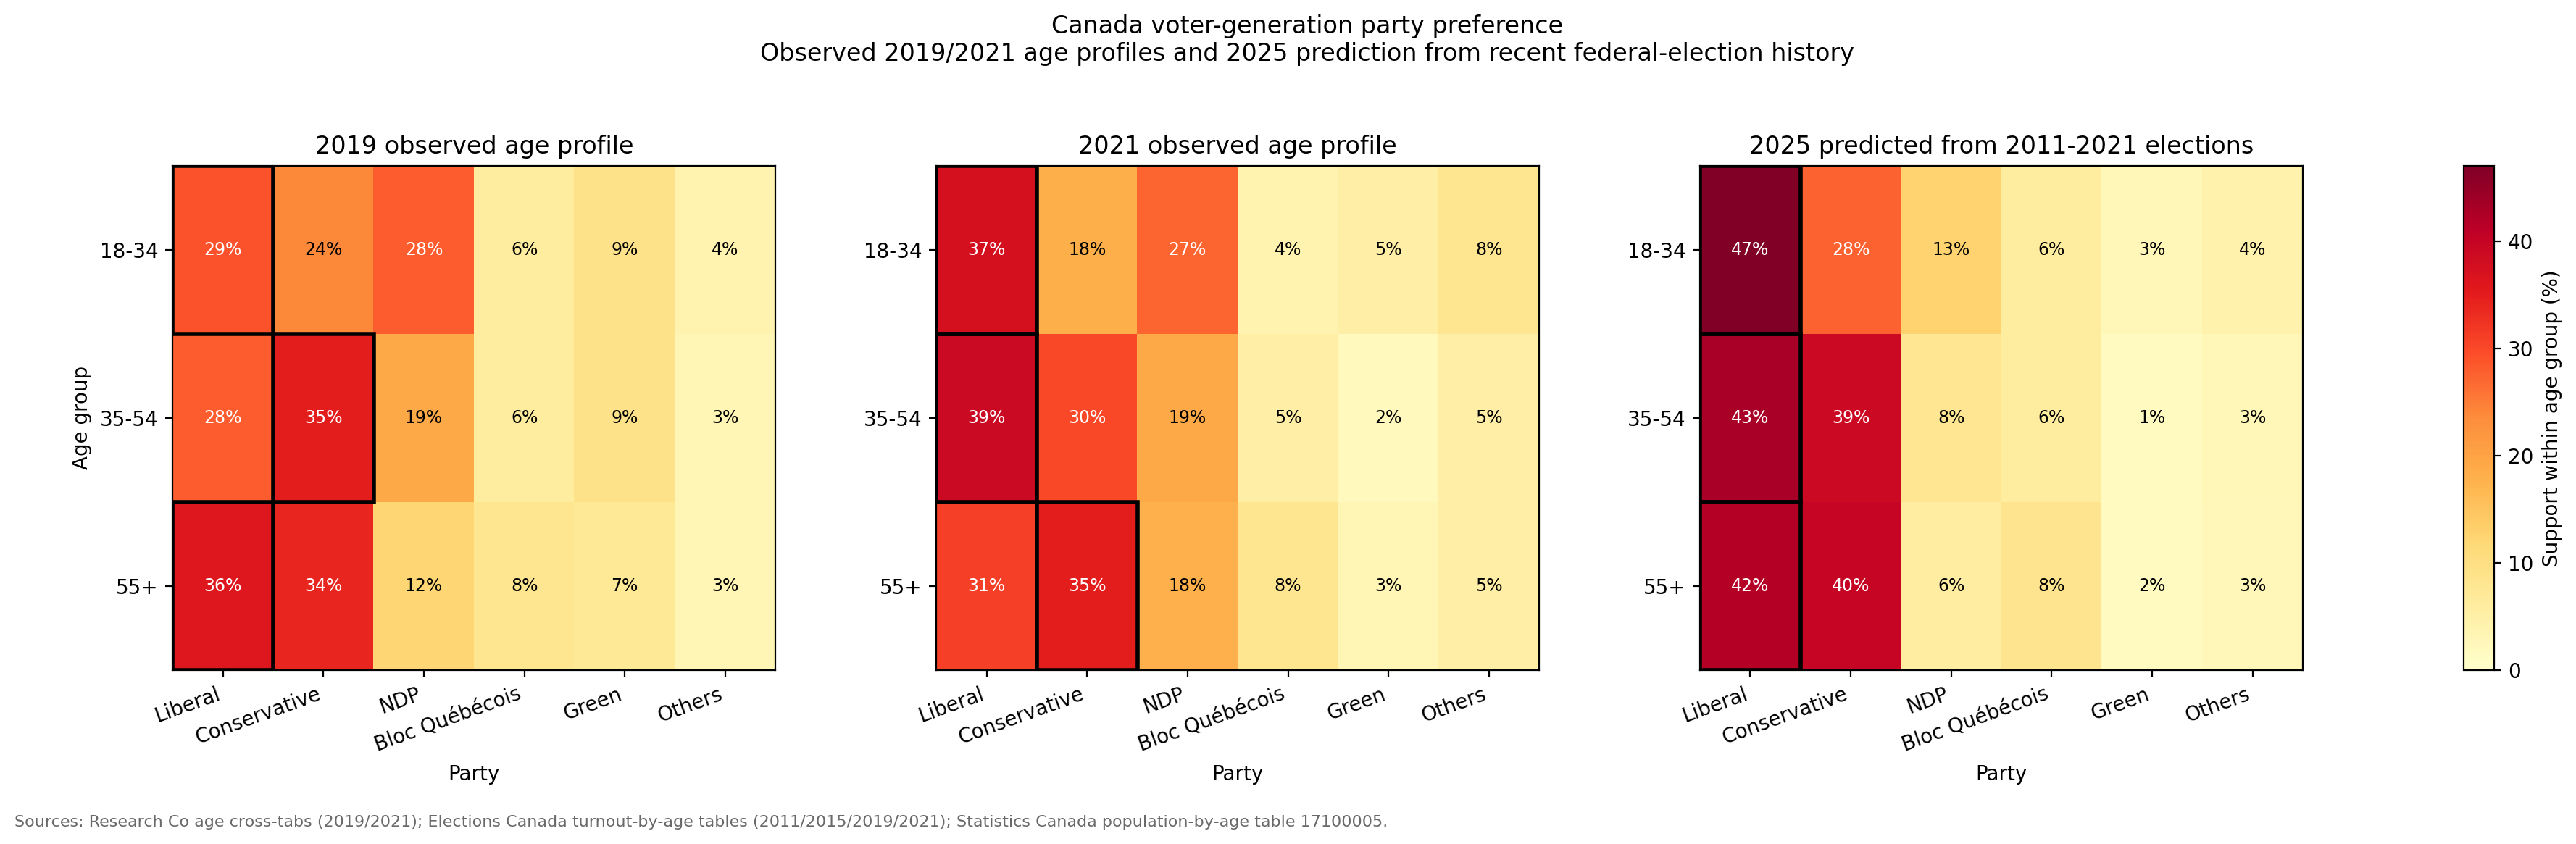

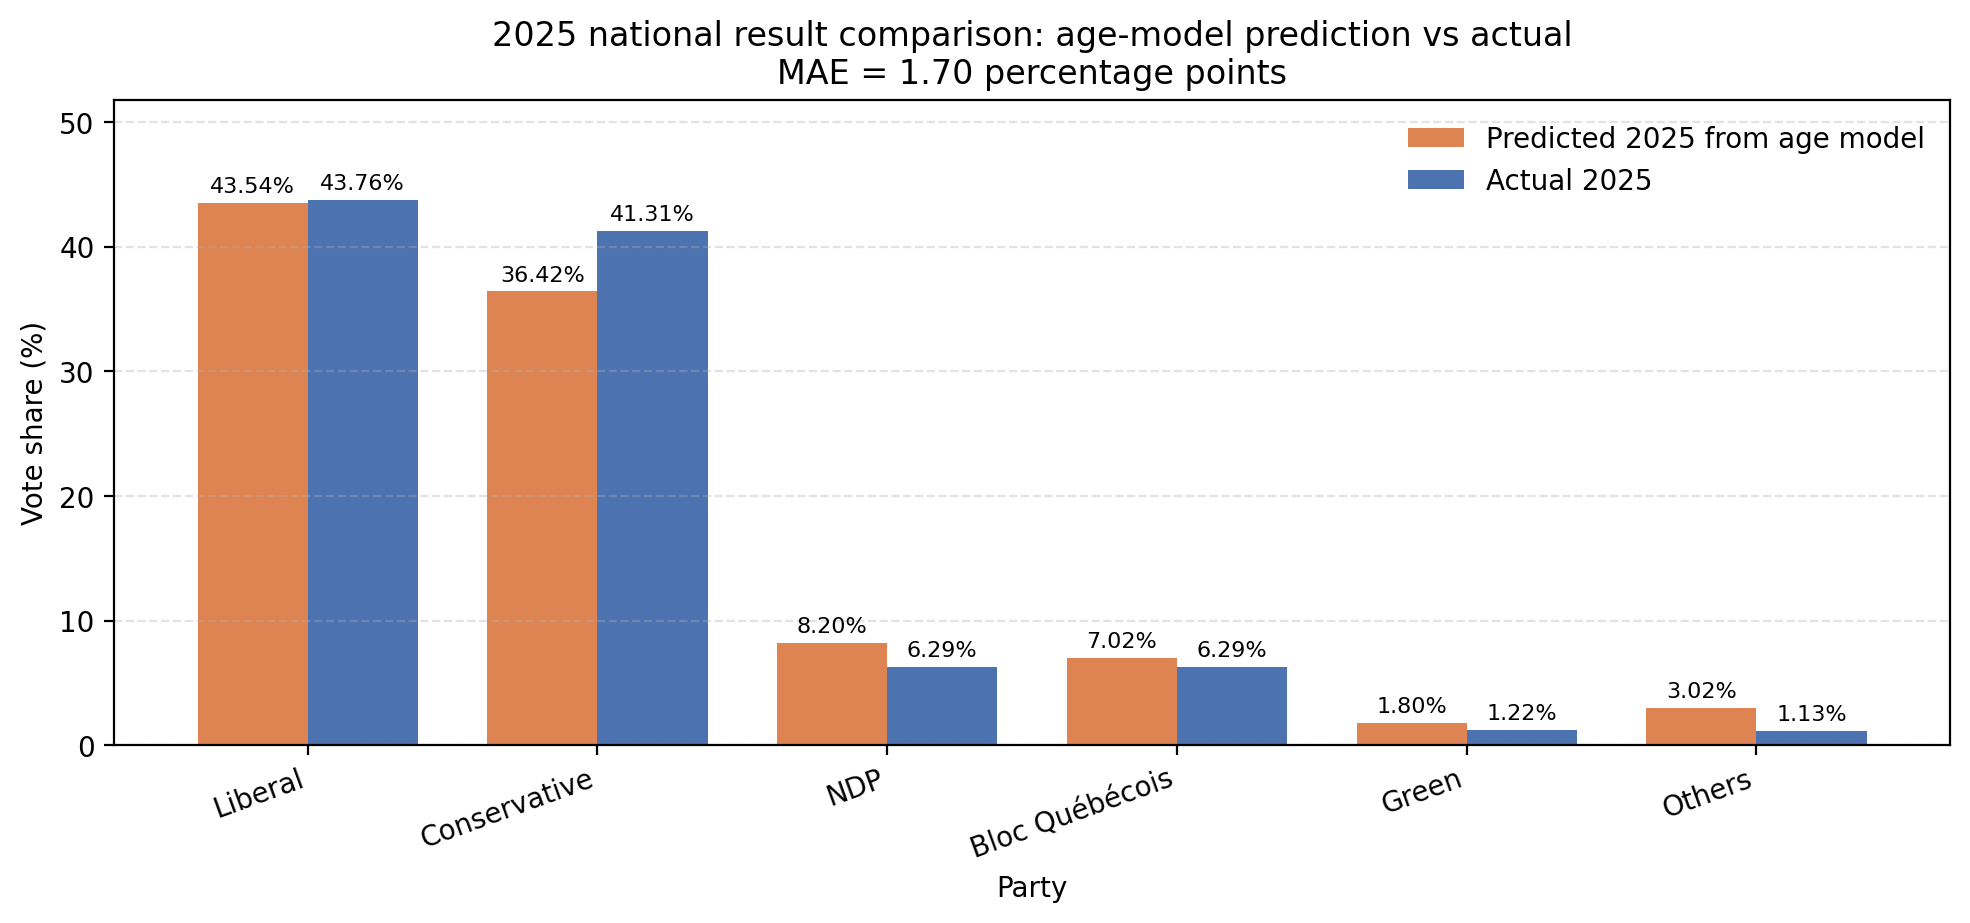

Source URLs:
- Research Co age cross-tabs (2019): https://researchco.ca/wp-content/uploads/2019/10/Tables_PoliticsCAN_20Oct2019.pdf
- Research Co age cross-tabs (2021): https://researchco.ca/wp-content/uploads/2021/09/Tables_Politics_CAN_14Sep2021.pdf
- Elections Canada turnout by age (2011/2015): https://www.elections.ca/content.aspx?dir=rec/eval/pes2015/vtsa&document=table1&lang=e&section=res
- Elections Canada turnout by age (2019): https://www.elections.ca/content.aspx?dir=rec/eval/pes2019/vtsa&document=index&lang=e&section=res
- Elections Canada turnout by age (2021): https://www.elections.ca/content.aspx?dir=rec/eval/pes2021/evt&document=p5&lang=e&section=res
- Statistics Canada population by age: https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip
- National vote-share input: outputs/national_vote_share_clean.csv

Electorate age weights used by election year:
AgeBand   18-34   35-54     55+
Year                           
2011     0.2124  0.3780  0.4096
2015     0.2478  0.3

In [21]:
from pathlib import Path
import io
import re
import sys
import time
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

try:
    from IPython.display import Image as IPyImage, display
except Exception:
    IPyImage = None
    display = None

PROJECT_MARKERS = (
    '.git',
    'canada_federal_vote_share_2000_2025.csv',
    'econ_2021_2025.py',
)
RESEARCH_2019_URL = 'https://researchco.ca/wp-content/uploads/2019/10/Tables_PoliticsCAN_20Oct2019.pdf'
RESEARCH_2021_URL = 'https://researchco.ca/wp-content/uploads/2021/09/Tables_Politics_CAN_14Sep2021.pdf'
TURNOUT_2015_URL = 'https://www.elections.ca/content.aspx?dir=rec/eval/pes2015/vtsa&document=table1&lang=e&section=res'
TURNOUT_2019_URL = 'https://www.elections.ca/content.aspx?dir=rec/eval/pes2019/vtsa&document=index&lang=e&section=res'
TURNOUT_2021_URL = 'https://www.elections.ca/content.aspx?dir=rec/eval/pes2021/evt&document=p5&lang=e&section=res'
STATCAN_POP_URL = 'https://www150.statcan.gc.ca/n1/tbl/csv/17100005-eng.zip'
HIST_YEARS = [2011, 2015, 2019, 2021]
TARGET_YEAR = 2025
AGE_BANDS = ['18-34', '35-54', '55+']
PARTIES = ['Liberal', 'Conservative', 'NDP', 'Bloc Québécois', 'Green', 'Others']
SEVEN_AGE_GROUPS = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
SEVEN_TO_BROAD = {
    '18-24': '18-34',
    '25-34': '18-34',
    '35-44': '35-54',
    '45-54': '35-54',
    '55-64': '55+',
    '65-74': '55+',
    '75+': '55+',
}
POP_LABELS = {
    '18-24': ['18 to 24 years'],
    '25-34': ['25 to 29 years', '30 to 34 years'],
    '35-44': ['35 to 39 years', '40 to 44 years'],
    '45-54': ['45 to 49 years', '50 to 54 years'],
    '55-64': ['55 to 59 years', '60 to 64 years'],
    '65-74': ['65 to 69 years', '70 to 74 years'],
    '75+': ['75 to 79 years', '80 to 84 years', '85 to 89 years', '90 years and older'],
}


def find_project_root():
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if any((candidate / marker).exists() for marker in PROJECT_MARKERS):
            return candidate
    return start


def download_if_missing(url, path, retries=3, timeout=120):
    if path.exists():
        return path
    path.parent.mkdir(parents=True, exist_ok=True)
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            with urllib.request.urlopen(req, timeout=timeout) as resp:
                path.write_bytes(resp.read())
            return path
        except Exception as exc:
            last_error = exc
            if path.exists():
                path.unlink()
            if attempt < retries:
                time.sleep(min(2 ** (attempt - 1), 5))
    raise RuntimeError(f'Failed to download {url}: {last_error}') from last_error


def normalize_age_label(label):
    text = str(label).strip()
    text = text.replace('\xa0', ' ')
    text = text.replace('–', '-')
    text = text.replace('&ndash;', '-')
    text = re.sub(r'Footnote\s*\d+', '', text, flags=re.I)
    text = text.replace(' to ', '-')
    text = text.replace(' years and over', '+')
    text = text.replace(' years', '').replace(' year', '')
    text = text.replace(' and older', '+')
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def flatten_columns(df):
    if not isinstance(df.columns, pd.MultiIndex):
        return [str(c).strip() for c in df.columns]
    flat = []
    for col in df.columns:
        parts = [str(x).strip() for x in col if str(x).strip() and str(x).strip() != 'nan']
        flat.append(' | '.join(parts))
    return flat


def load_turnout_history(cache_dir):
    rows = []

    table_2015 = pd.read_html(TURNOUT_2015_URL)[0]
    table_2015.columns = flatten_columns(table_2015)
    c_age = next(c for c in table_2015.columns if c.startswith('Age Group'))
    c_2011 = next(c for c in table_2015.columns if c.startswith('2011') and 'Estimate' in c and 'Lower' not in c and 'Upper' not in c)
    c_2015 = next(c for c in table_2015.columns if c.startswith('2015') and 'Estimate' in c and 'Lower' not in c and 'Upper' not in c)
    t15 = table_2015.copy()
    t15['AgeGroup'] = t15[c_age].astype(str).map(normalize_age_label)
    t15 = t15[t15['AgeGroup'].isin(SEVEN_AGE_GROUPS)]
    for year, col in [(2011, c_2011), (2015, c_2015)]:
        tmp = t15[['AgeGroup', col]].copy().rename(columns={col: 'TurnoutPct'})
        tmp['TurnoutPct'] = pd.to_numeric(tmp['TurnoutPct'], errors='coerce')
        tmp['Year'] = year
        rows.append(tmp)

    turnout_2019_path = cache_dir / 'elections_canada_turnout_age_2019.html'
    download_if_missing(TURNOUT_2019_URL, turnout_2019_path)
    table_2019 = pd.read_html(io.StringIO(turnout_2019_path.read_bytes().decode('latin1')))[0]
    table_2019.columns = flatten_columns(table_2019)
    c_geo = next(c for c in table_2019.columns if 'Prov./Terr.' in c)
    c_sex = next(c for c in table_2019.columns if 'Sex' in c)
    c_age = next(c for c in table_2019.columns if 'Age group' in c)
    c_2019 = next(c for c in table_2019.columns if c.startswith('2019 general election') and 'estimate' in c.lower() and 'lower' not in c.lower() and 'upper' not in c.lower())
    t19 = table_2019[(table_2019[c_geo] == 'Canada') & (table_2019[c_sex] == 'Both sexes')].copy()
    t19['AgeGroup'] = t19[c_age].astype(str).map(normalize_age_label)
    t19 = t19[t19['AgeGroup'].isin(SEVEN_AGE_GROUPS)]
    t19 = t19[['AgeGroup', c_2019]].copy().rename(columns={c_2019: 'TurnoutPct'})
    t19['TurnoutPct'] = pd.to_numeric(t19['TurnoutPct'], errors='coerce')
    t19['Year'] = 2019
    rows.append(t19)

    turnout_2021_path = cache_dir / 'elections_canada_turnout_age_2021.html'
    download_if_missing(TURNOUT_2021_URL, turnout_2021_path)
    table_2021 = pd.read_html(io.StringIO(turnout_2021_path.read_bytes().decode('latin1')))[0]
    table_2021['AgeGroup'] = table_2021['Age Group'].astype(str).map(normalize_age_label)
    t21 = table_2021[table_2021['AgeGroup'].isin(SEVEN_AGE_GROUPS)][['AgeGroup', 'Turnout']].copy().rename(columns={'Turnout': 'TurnoutPct'})
    t21['TurnoutPct'] = pd.to_numeric(t21['TurnoutPct'].astype(str).str.replace('%', '', regex=False), errors='coerce')
    t21['Year'] = 2021
    rows.append(t21)

    turnout = pd.concat(rows, ignore_index=True)
    return turnout[['Year', 'AgeGroup', 'TurnoutPct']].sort_values(['Year', 'AgeGroup']).reset_index(drop=True)


def load_population_age_groups(cache_path):
    with zipfile.ZipFile(cache_path, 'r') as zf:
        name = [n for n in zf.namelist() if n.lower().endswith('.csv') and 'meta' not in n.lower()][0]
        with zf.open(name) as fh:
            pop = pd.read_csv(fh, dtype=str, low_memory=False)
    pop = pop[(pop['GEO'] == 'Canada') & (pop['Gender'].astype(str).str.contains('Both|Total', case=False, na=False))].copy()
    pop['Year'] = pd.to_numeric(pop['REF_DATE'].astype(str).str.extract(r'(\d{4})', expand=False), errors='coerce')
    pop['VALUE_NUM'] = pd.to_numeric(pop['VALUE'].astype(str).str.replace(',', '', regex=False), errors='coerce')
    pop = pop[pop['Year'].isin(HIST_YEARS + [TARGET_YEAR])]
    rows = []
    for age_group, labels in POP_LABELS.items():
        tmp = pop[pop['Age group'].isin(labels)].groupby('Year', as_index=False)['VALUE_NUM'].sum()
        tmp['AgeGroup'] = age_group
        rows.append(tmp)
    out = pd.concat(rows, ignore_index=True)
    return out[['Year', 'AgeGroup', 'VALUE_NUM']].rename(columns={'VALUE_NUM': 'Population'})


def broad_age_weights(pop_age, turnout):
    hist = turnout.copy()
    for age_group in SEVEN_AGE_GROUPS:
        g = hist[hist['AgeGroup'] == age_group].sort_values('Year')
        slope, intercept = np.polyfit(g['Year'], g['TurnoutPct'], 1)
        pred = float(np.clip(slope * TARGET_YEAR + intercept, 0.0, 100.0))
        hist = pd.concat([hist, pd.DataFrame({'Year': [TARGET_YEAR], 'AgeGroup': [age_group], 'TurnoutPct': [pred]})], ignore_index=True)
    merged = pop_age.merge(hist, on=['Year', 'AgeGroup'], how='inner')
    merged['EstimatedVoters'] = merged['Population'] * merged['TurnoutPct'] / 100.0
    merged['AgeBand'] = merged['AgeGroup'].map(SEVEN_TO_BROAD)
    weights = merged.groupby(['Year', 'AgeBand'], as_index=False)['EstimatedVoters'].sum()
    weights['Weight'] = weights.groupby('Year')['EstimatedVoters'].transform(lambda s: s / s.sum())
    return weights, hist.sort_values(['Year', 'AgeGroup']).reset_index(drop=True)


def load_poll_pref(pdf_cache):
    download_if_missing(RESEARCH_2019_URL, pdf_cache / 'Tables_PoliticsCAN_20Oct2019.pdf')
    download_if_missing(RESEARCH_2021_URL, pdf_cache / 'Tables_Politics_CAN_14Sep2021.pdf')
    ROOT = find_project_root()
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))
    from researchco_age_support import parse_multiple_age_tables

    pref = parse_multiple_age_tables({
        2019: pdf_cache / 'Tables_PoliticsCAN_20Oct2019.pdf',
        2021: pdf_cache / 'Tables_Politics_CAN_14Sep2021.pdf',
    }).copy()
    pref['AgeBand'] = pd.Categorical(pref['AgeBand'], categories=AGE_BANDS, ordered=True)
    pref['Party'] = pd.Categorical(pref['Party'], categories=PARTIES, ordered=True)
    pref = pref.sort_values(['Year', 'AgeBand', 'Party']).reset_index(drop=True)
    pref['SupportPct'] = pref.groupby(['Year', 'AgeBand'])['SupportPct'].transform(lambda s: s / s.sum() * 100.0)
    return pref


def load_national_shares(path):
    df = pd.read_csv(path)
    df = df[df['Year'].isin(HIST_YEARS + [TARGET_YEAR])].copy()
    df['Party'] = df['Party'].replace({
        "People's": 'Others',
        'People’s': 'Others',
        "People's Party": 'Others',
        'People’s Party': 'Others',
    })
    df = df[df['Party'].isin(PARTIES)].copy()
    df = df.groupby(['Year', 'Party'], as_index=False)['VoteShare'].sum()
    df['VoteShare'] = pd.to_numeric(df['VoteShare'], errors='coerce')
    df['VoteShare'] = df.groupby('Year')['VoteShare'].transform(lambda s: s / s.sum() * 100.0)
    return df.sort_values(['Year', 'Party']).reset_index(drop=True)


def pivot_matrix(df, year, value_col='SupportPct'):
    return (
        df[df['Year'] == year]
        .pivot(index='AgeBand', columns='Party', values=value_col)
        .reindex(index=AGE_BANDS, columns=PARTIES)
    )


def estimate_age_effects(pref, weights):
    beta_list = []
    for year in [2019, 2021]:
        mat = pivot_matrix(pref, year).fillna(0.0) / 100.0
        w = weights[weights['Year'] == year].set_index('AgeBand').reindex(AGE_BANDS)['Weight'].to_numpy()
        national = w @ mat.to_numpy()
        beta = np.log(np.clip(mat.to_numpy(), 1e-6, 1.0)) - np.log(np.clip(national, 1e-6, 1.0))
        beta_list.append(beta)
    beta = np.mean(beta_list, axis=0)
    beta = np.clip(beta, -2.5, 2.5)
    return pd.DataFrame(beta, index=AGE_BANDS, columns=PARTIES)


def fit_ipf_support(target_party_share, age_weights, beta_df, max_iter=3000, tol=1e-10):
    target = np.asarray(target_party_share, dtype=float)
    target = target / target.sum()
    w = np.asarray(age_weights, dtype=float)
    w = w / w.sum()
    s = np.exp(beta_df.reindex(index=AGE_BANDS, columns=PARTIES).to_numpy()) * target[None, :]
    s = np.clip(s, 1e-8, None)
    for _ in range(max_iter):
        s = s / s.sum(axis=1, keepdims=True)
        current = (w[:, None] * s).sum(axis=0)
        s *= (target / np.clip(current, 1e-12, None))[None, :]
        row_err = np.abs(s.sum(axis=1) - 1.0).max()
        col_err = np.abs((w[:, None] * s).sum(axis=0) - target).max()
        if max(row_err, col_err) < tol:
            break
    s = s / s.sum(axis=1, keepdims=True)
    return pd.DataFrame(s, index=AGE_BANDS, columns=PARTIES)


def project_national_2025(national):
    rows = []
    for party in PARTIES:
        s = national[national['Party'] == party].sort_values('Year')
        years = s['Year'].to_numpy(dtype=float)
        vals = np.clip(s['VoteShare'].to_numpy(dtype=float) / 100.0, 1e-6, 1.0)
        slope, intercept = np.polyfit(years, np.log(vals), 1)
        rows.append((party, float(np.exp(slope * TARGET_YEAR + intercept))))
    out = pd.DataFrame(rows, columns=['Party', 'PredShare'])
    out['PredShare'] = out['PredShare'] / out['PredShare'].sum() * 100.0
    return out


def draw_heatmap(ax, matrix, title, vmax):
    im = ax.imshow(matrix.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=20, ha='right')
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel('Party')
    for i, age_band in enumerate(matrix.index):
        row = matrix.loc[age_band]
        row_max = row.max()
        for j, party in enumerate(matrix.columns):
            val = row[party]
            color = 'white' if val >= vmax * 0.55 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', color=color, fontsize=8.5)
            if np.isclose(val, row_max):
                ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=2))
    return im


ROOT = find_project_root()
OUT_DIR = ROOT / 'outputs_demographics'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PDF_CACHE = ROOT / 'data' / 'external_age_sources'
PDF_CACHE.mkdir(parents=True, exist_ok=True)
CACHE_DIR = ROOT / 'data' / 'statcan_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

download_if_missing(STATCAN_POP_URL, CACHE_DIR / '17100005-eng.zip')
pref_obs = load_poll_pref(PDF_CACHE)
national = load_national_shares(ROOT / 'outputs' / 'national_vote_share_clean.csv')
pop_age = load_population_age_groups(CACHE_DIR / '17100005-eng.zip')
turnout = load_turnout_history(PDF_CACHE)
weights, turnout_with_projection = broad_age_weights(pop_age, turnout)

beta = estimate_age_effects(pref_obs, weights)
nat_pred_2025 = project_national_2025(national)
weights_2025 = weights[weights['Year'] == TARGET_YEAR].set_index('AgeBand').reindex(AGE_BANDS)['Weight']
model_2025 = fit_ipf_support(
    nat_pred_2025.set_index('Party').reindex(PARTIES)['PredShare'].to_numpy() / 100.0,
    weights_2025.to_numpy(),
    beta,
) * 100.0

model_rows = []
for year in HIST_YEARS + [TARGET_YEAR]:
    if year == TARGET_YEAR:
        mat = model_2025.copy()
        data_type = 'predicted_2025'
    else:
        nat = national[national['Year'] == year].set_index('Party').reindex(PARTIES)['VoteShare'].to_numpy() / 100.0
        w = weights[weights['Year'] == year].set_index('AgeBand').reindex(AGE_BANDS)['Weight'].to_numpy()
        mat = fit_ipf_support(nat, w, beta) * 100.0
        data_type = 'model_implied'
    for age_band in AGE_BANDS:
        for party in PARTIES:
            model_rows.append({
                'Year': year,
                'AgeBand': age_band,
                'Party': party,
                'SupportPct': float(mat.loc[age_band, party]),
                'DataType': data_type,
            })
model_df = pd.DataFrame(model_rows)
model_df.to_csv(OUT_DIR / 'voter_generation_party_preference_model_2011_2025.csv', index=False)

display_df = pd.concat([
    pref_obs.assign(DataType='observed_poll')[['Year', 'AgeBand', 'Party', 'SupportPct', 'DataType']],
    pd.DataFrame(model_rows).query('Year == @TARGET_YEAR')[['Year', 'AgeBand', 'Party', 'SupportPct', 'DataType']],
], ignore_index=True)
display_df.to_csv(OUT_DIR / 'voter_generation_party_preference_display_2019_2025.csv', index=False)

age_weight_df = weights.copy()
age_weight_df.to_csv(OUT_DIR / 'voter_generation_age_weight_history_2011_2025.csv', index=False)

summary_rows = []
for age_band in AGE_BANDS:
    top2 = (
        model_2025.loc[age_band]
        .sort_values(ascending=False)
        .head(2)
    )
    summary_rows.append({
        'Year': TARGET_YEAR,
        'AgeBand': age_band,
        'TopParty': top2.index[0],
        'TopPartyPct': float(top2.iloc[0]),
        'SecondParty': top2.index[1],
        'SecondPartyPct': float(top2.iloc[1]),
    })
summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT_DIR / 'voter_generation_party_top_choice_model_2025.csv', index=False)

youth_senior_gap = pd.DataFrame({
    'Party': PARTIES,
    '18-34': model_2025.loc['18-34', PARTIES].to_numpy(),
    '55+': model_2025.loc['55+', PARTIES].to_numpy(),
})
youth_senior_gap['YouthMinusSenior'] = youth_senior_gap['18-34'] - youth_senior_gap['55+']

agg_2025 = pd.Series(0.0, index=PARTIES)
for age_band in AGE_BANDS:
    agg_2025 += weights_2025.loc[age_band] * model_2025.loc[age_band]
actual_2025 = national[national['Year'] == TARGET_YEAR].set_index('Party').reindex(PARTIES)['VoteShare']
comp_2025 = pd.DataFrame({'PredictedNational2025': agg_2025, 'Actual2025': actual_2025})
comp_2025['AbsError'] = (comp_2025['PredictedNational2025'] - comp_2025['Actual2025']).abs()
mae_2025 = float(comp_2025['AbsError'].mean())

fig = plt.figure(figsize=(18.2, 5.8))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)
cax = fig.add_subplot(gs[0, 3])
m2019 = pivot_matrix(pref_obs, 2019)
m2021 = pivot_matrix(pref_obs, 2021)
vmax = max(float(m2019.max().max()), float(m2021.max().max()), float(model_2025.max().max()))
im = draw_heatmap(ax1, m2019, '2019 observed age profile', vmax)
draw_heatmap(ax2, m2021, '2021 observed age profile', vmax)
draw_heatmap(ax3, model_2025, '2025 predicted from 2011-2021 elections', vmax)
ax1.set_ylabel('Age group')
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Support within age group (%)')
fig.suptitle('Canada voter-generation party preference\nObserved 2019/2021 age profiles and 2025 prediction from recent federal-election history', y=0.98)
fig.text(
    0.01,
    0.01,
    'Sources: Research Co age cross-tabs (2019/2021); Elections Canada turnout-by-age tables (2011/2015/2019/2021); Statistics Canada population-by-age table 17100005.',
    ha='left',
    va='bottom',
    fontsize=8,
    color='dimgray',
)
fig.subplots_adjust(left=0.07, right=0.95, bottom=0.20, top=0.8)
chart_path = OUT_DIR / 'fig_voter_generation_party_preference_model_2025.png'
plt.savefig(chart_path, dpi=200, bbox_inches='tight')
plt.close(fig)

comparison_fig, comparison_ax = plt.subplots(figsize=(10.2, 5.2))
plot_df = comp_2025.reset_index().rename(columns={'index': 'Party'})
x = np.arange(len(PARTIES))
bar_width = 0.38
comparison_ax.bar(x - bar_width / 2, plot_df['PredictedNational2025'], width=bar_width, label='Predicted 2025 from age model', color='#dd8452')
comparison_ax.bar(x + bar_width / 2, plot_df['Actual2025'], width=bar_width, label='Actual 2025', color='#4c72b0')
comparison_ax.set_xticks(x)
comparison_ax.set_xticklabels(PARTIES, rotation=20, ha='right')
comparison_ax.set_ylabel('Vote share (%)')
comparison_ax.set_xlabel('Party')
comparison_ax.set_title(f'2025 national result comparison: age-model prediction vs actual\nMAE = {mae_2025:.2f} percentage points')
comparison_ax.grid(axis='y', linestyle='--', alpha=0.35)
comparison_ax.legend(frameon=False)
comparison_ax.set_ylim(0, max(float(plot_df[['PredictedNational2025', 'Actual2025']].to_numpy().max()) + 8.0, 12.0))
for offset, col in [(-bar_width / 2, 'PredictedNational2025'), (bar_width / 2, 'Actual2025')]:
    for xi, val in zip(x, plot_df[col]):
        comparison_ax.text(xi + offset, float(val) + 0.5, f'{val:.2f}%', ha='center', va='bottom', fontsize=8)
comparison_fig.subplots_adjust(bottom=0.22, top=0.84, left=0.08, right=0.98)
comparison_chart_path = OUT_DIR / 'fig_voter_generation_prediction_vs_actual_2025.png'
comparison_fig.savefig(comparison_chart_path, dpi=200, bbox_inches='tight')
plt.close(comparison_fig)

if 'ipykernel' in sys.modules and IPyImage is not None and display is not None:
    display(IPyImage(filename=str(chart_path)))
    display(IPyImage(filename=str(comparison_chart_path)))

print('Source URLs:')
print(f'- Research Co age cross-tabs (2019): {RESEARCH_2019_URL}')
print(f'- Research Co age cross-tabs (2021): {RESEARCH_2021_URL}')
print(f'- Elections Canada turnout by age (2011/2015): {TURNOUT_2015_URL}')
print(f'- Elections Canada turnout by age (2019): {TURNOUT_2019_URL}')
print(f'- Elections Canada turnout by age (2021): {TURNOUT_2021_URL}')
print(f'- Statistics Canada population by age: {STATCAN_POP_URL}')
print('- National vote-share input: outputs/national_vote_share_clean.csv')
print('')
print('Electorate age weights used by election year:')
print(weights.pivot(index='Year', columns='AgeBand', values='Weight').round(4).to_string())
print('')
print('Projected 2025 national vote shares from the last four federal elections:')
print(nat_pred_2025.round(2).to_string(index=False))
print('')
print('Predicted 2025 party preference by age group:')
print(model_2025.round(2).to_string())
print('')
print('Top two parties within each predicted 2025 age band:')
print(summary.round(2).to_string(index=False))
print('')
print('Youth minus senior support gap for predicted 2025 (18-34 minus 55+):')
print(youth_senior_gap.round(2).to_string(index=False))
print('')
print('2025 national aggregation check from the age model:')
print(comp_2025.round(2).to_string())
print(f'2025 national MAE from this age model: {mae_2025:.2f}')
print('')
print(f'Saved chart: {chart_path}')
print(f'Saved comparison chart: {comparison_chart_path}')
print(f"Saved model CSV: {OUT_DIR / 'voter_generation_party_preference_model_2011_2025.csv'}")
print(f"Saved display CSV: {OUT_DIR / 'voter_generation_party_preference_display_2019_2025.csv'}")
print(f"Saved age-weight CSV: {OUT_DIR / 'voter_generation_age_weight_history_2011_2025.csv'}")
print(f"Saved top-choice CSV: {OUT_DIR / 'voter_generation_party_top_choice_model_2025.csv'}")

